# The Iris Dataset

A supervised machine-learning classifier problem.

## 1. Loading Modules

### Basic

In [1]:
import numpy as np
import inspect
import os

from math import pi
from operator import itemgetter

from scipy.stats import multivariate_normal

import multiprocessing as mp

# from scipy import stats
# from scipy.interpolate import interp1d
# from scipy.optimize import curve_fit, brentq
# from scipy.integrate import quad, simps

In [2]:
# number of cores in laptop, minus 2 (so we free one *physical* core)
safe_cpus = mp.cpu_count() - 2

### Data Handling and Cleaning

In [3]:
import pandas as pd

from sklearn import set_config

# import datetime as dt
# import charset_normalizer
# import fuzzywuzzy as fwz

Ensuring all Pipelines output `pandas.DataFrame`, globally!

In [4]:
set_config(transform_output="pandas") # globally!

### Data Visualization and Analysis

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

from dataprep.eda import create_report

ModuleNotFoundError: No module named 'dataprep'

In [ ]:
# very pretty plots!
plt.style.use('fivethirtyeight')

# Override aggressive elements
plt.rcParams['font.size'] = 10
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

# ignore this
# sns.set(style="whitegrid")#, context="talk", palette="muted")

In [6]:
# %matplotlib inline

In [ ]:
plt.set_loglevel('WARNING')

## 2. Loading data 

We will prepare the dataset

In [7]:
# sklearn already has the iris dataset
from sklearn.datasets import load_iris

In [8]:
# defining path to data file
file_path = "../data/iris_dataset.csv"

# checking if dataset exists
data_exists = os.path.exists(file_path)
print(data_exists)

True


In [11]:
# defining the dataset: raw_data

if data_exists:
    raw_data = pd.read_csv(file_path, index_col=0)

else:
    # loading the data as a pandas DataFrame
    sk_data = load_iris(as_frame=True)

    # the data is split into the actual physical data of the flowers (features), the species in code (target), and the species names
    print(sk_data['data'])
    print(sk_data['target'])
    print(sk_data['target_names'])

    # we define a new DataFrame that has all the information we need:
    raw_data = sk_data['data'].copy()
    raw_data['species'] = sk_data['target'].apply(lambda species_code: sk_data['target_names'][species_code])

    # saving the dataset to the folder
    raw_data.to_csv(file_path)

In [12]:
raw_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


Describing it in more detail:

In [13]:
raw_data.describe(include='all')

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


## 3. Data Cleaning

### Missing entries

We begin by looking for any missing entries:

In [14]:
raw_data.isna().sum(axis=0) # counting missing values along the rows (i.e., fixed column, sum it all)

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

**No missing values!**

### Duplicates

Now, we look for duplicates:

In [15]:
raw_data[raw_data.duplicated()]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
142,5.8,2.7,5.1,1.9,virginica


**Found one!** Let us **drop** it, and redefine and reindex the data:

In [16]:
raw_data = raw_data.drop_duplicates(ignore_index=True)

In [17]:
raw_data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [18]:
raw_data[raw_data.duplicated()] # no more duplicates!

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species


### Renaming columns

The data is clean! However, it's a bit hard to manipulate the data with these names. Let us clean them up!

In [19]:
# copying the original data so we can manipulate it
data = raw_data.copy()

In [20]:
def new_name(col_name):
    
    words = col_name.split(' ') # split along spaces
    if len(words) > 1:
        new_col_name = words[0] + '_' + words[1] # new name
    else:
        new_col_name = col_name

    return new_col_name

In [21]:
new_names = {col:new_name(col) for col in data.columns}
print(new_names)

{'sepal length (cm)': 'sepal_length', 'sepal width (cm)': 'sepal_width', 'petal length (cm)': 'petal_length', 'petal width (cm)': 'petal_width', 'species': 'species'}


In [22]:
data = data.rename(columns = new_names)

## 4. Exploratory Data Analysis

In [23]:
from sklearn.feature_selection import mutual_info_classif

### Original Features

Let us create a report on the dataset

In [24]:
report1 = create_report(data, title='Iris Dataset')
# report1.show_browser()

  0%|                                                                                                         …

/home/mbuenabad/anaconda3/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


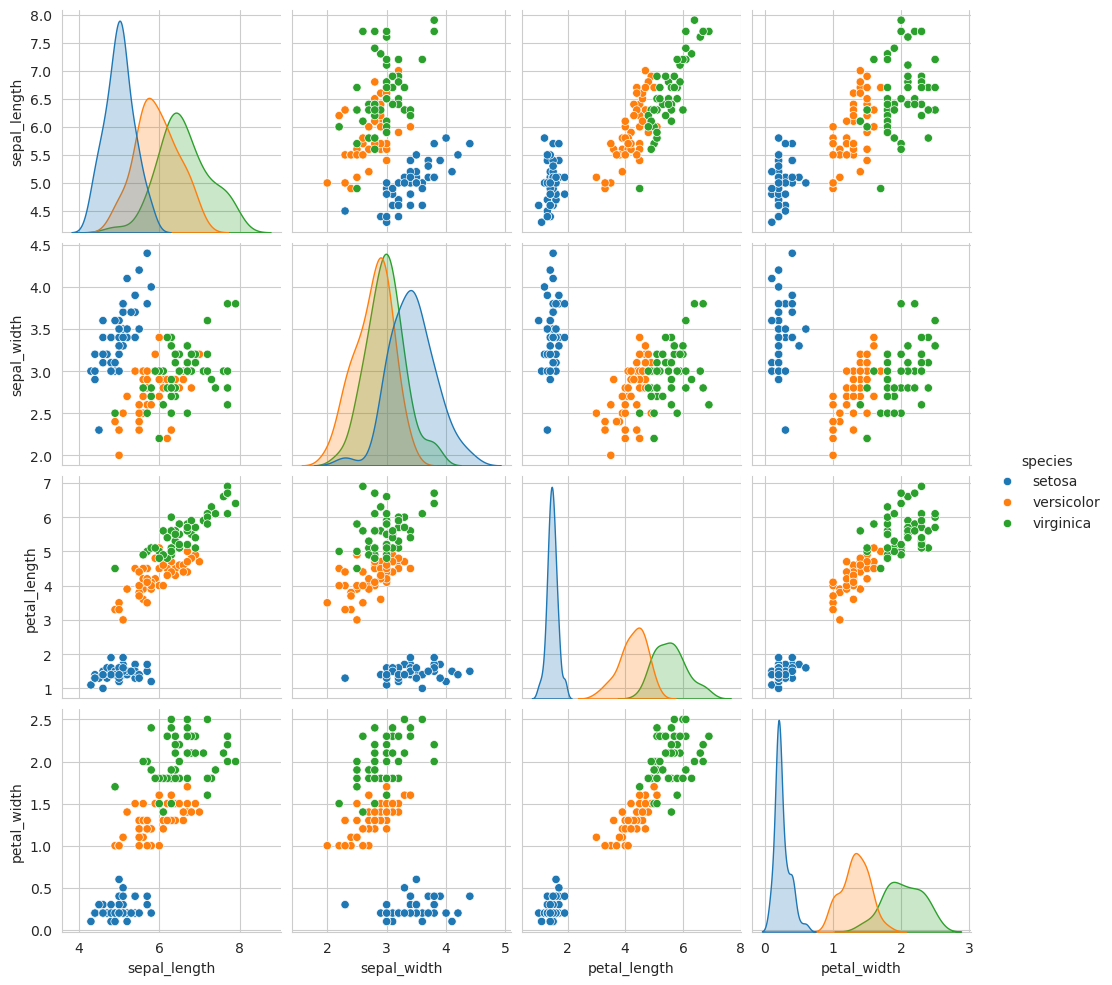

In [25]:
sns.pairplot(data, hue='species')

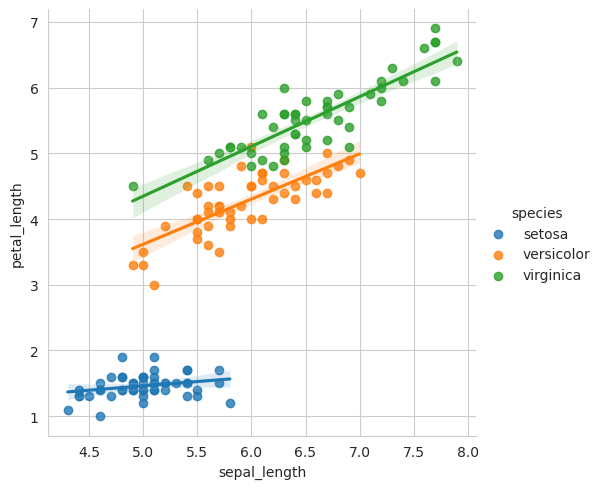

In [26]:
sns.lmplot(data, x='sepal_length', y='petal_length', hue='species')

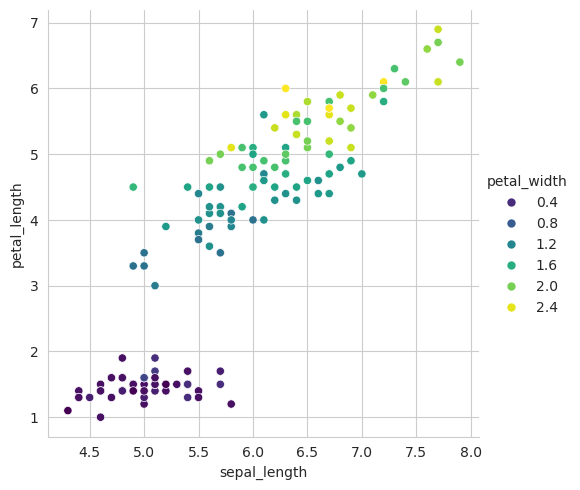

In [27]:
sns.relplot(data, x='sepal_length', y='petal_length', hue='petal_width', kind='scatter', palette='viridis')

### New Features

It may be useful to consider additional features, such as the area of the petals and sepals, and their elongation. It may also prove useful to compare the ratio of the petal and sepal areas. We will make a new copy of the data for that.

In [28]:
# function for new features
def new_iris_features(dataset):
    """
    Computes the area and elongation of each part of the irist flower in the iris dataset.
    """

    new_features = {}

    for part in ['sepal', 'petal']:
        new_features[part+'_area'] = dataset[part+'_length']*dataset[part+'_width'] # compute area
        new_features[part+'_elongation'] = dataset[part+'_length']/dataset[part+'_width'] # compute elongation

    new_features['petal_to_sepal_ratio'] = new_features['petal_area']/new_features['sepal_area']

    new_features = pd.DataFrame(new_features, index=dataset.index)

    return new_features

In [29]:
engineered_data = data.copy() # making copy

# applying the function
engineered_data = pd.concat([engineered_data, new_iris_features(engineered_data)], axis=1)

In [30]:
engineered_data.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species',
       'sepal_area', 'sepal_elongation', 'petal_area', 'petal_elongation',
       'petal_to_sepal_ratio'],
      dtype='object')

In [31]:
report2 = create_report(engineered_data, title='Iris Dataset (new features)')
# report2.show_browser()

  0%|                                                                                                         …

/home/mbuenabad/anaconda3/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


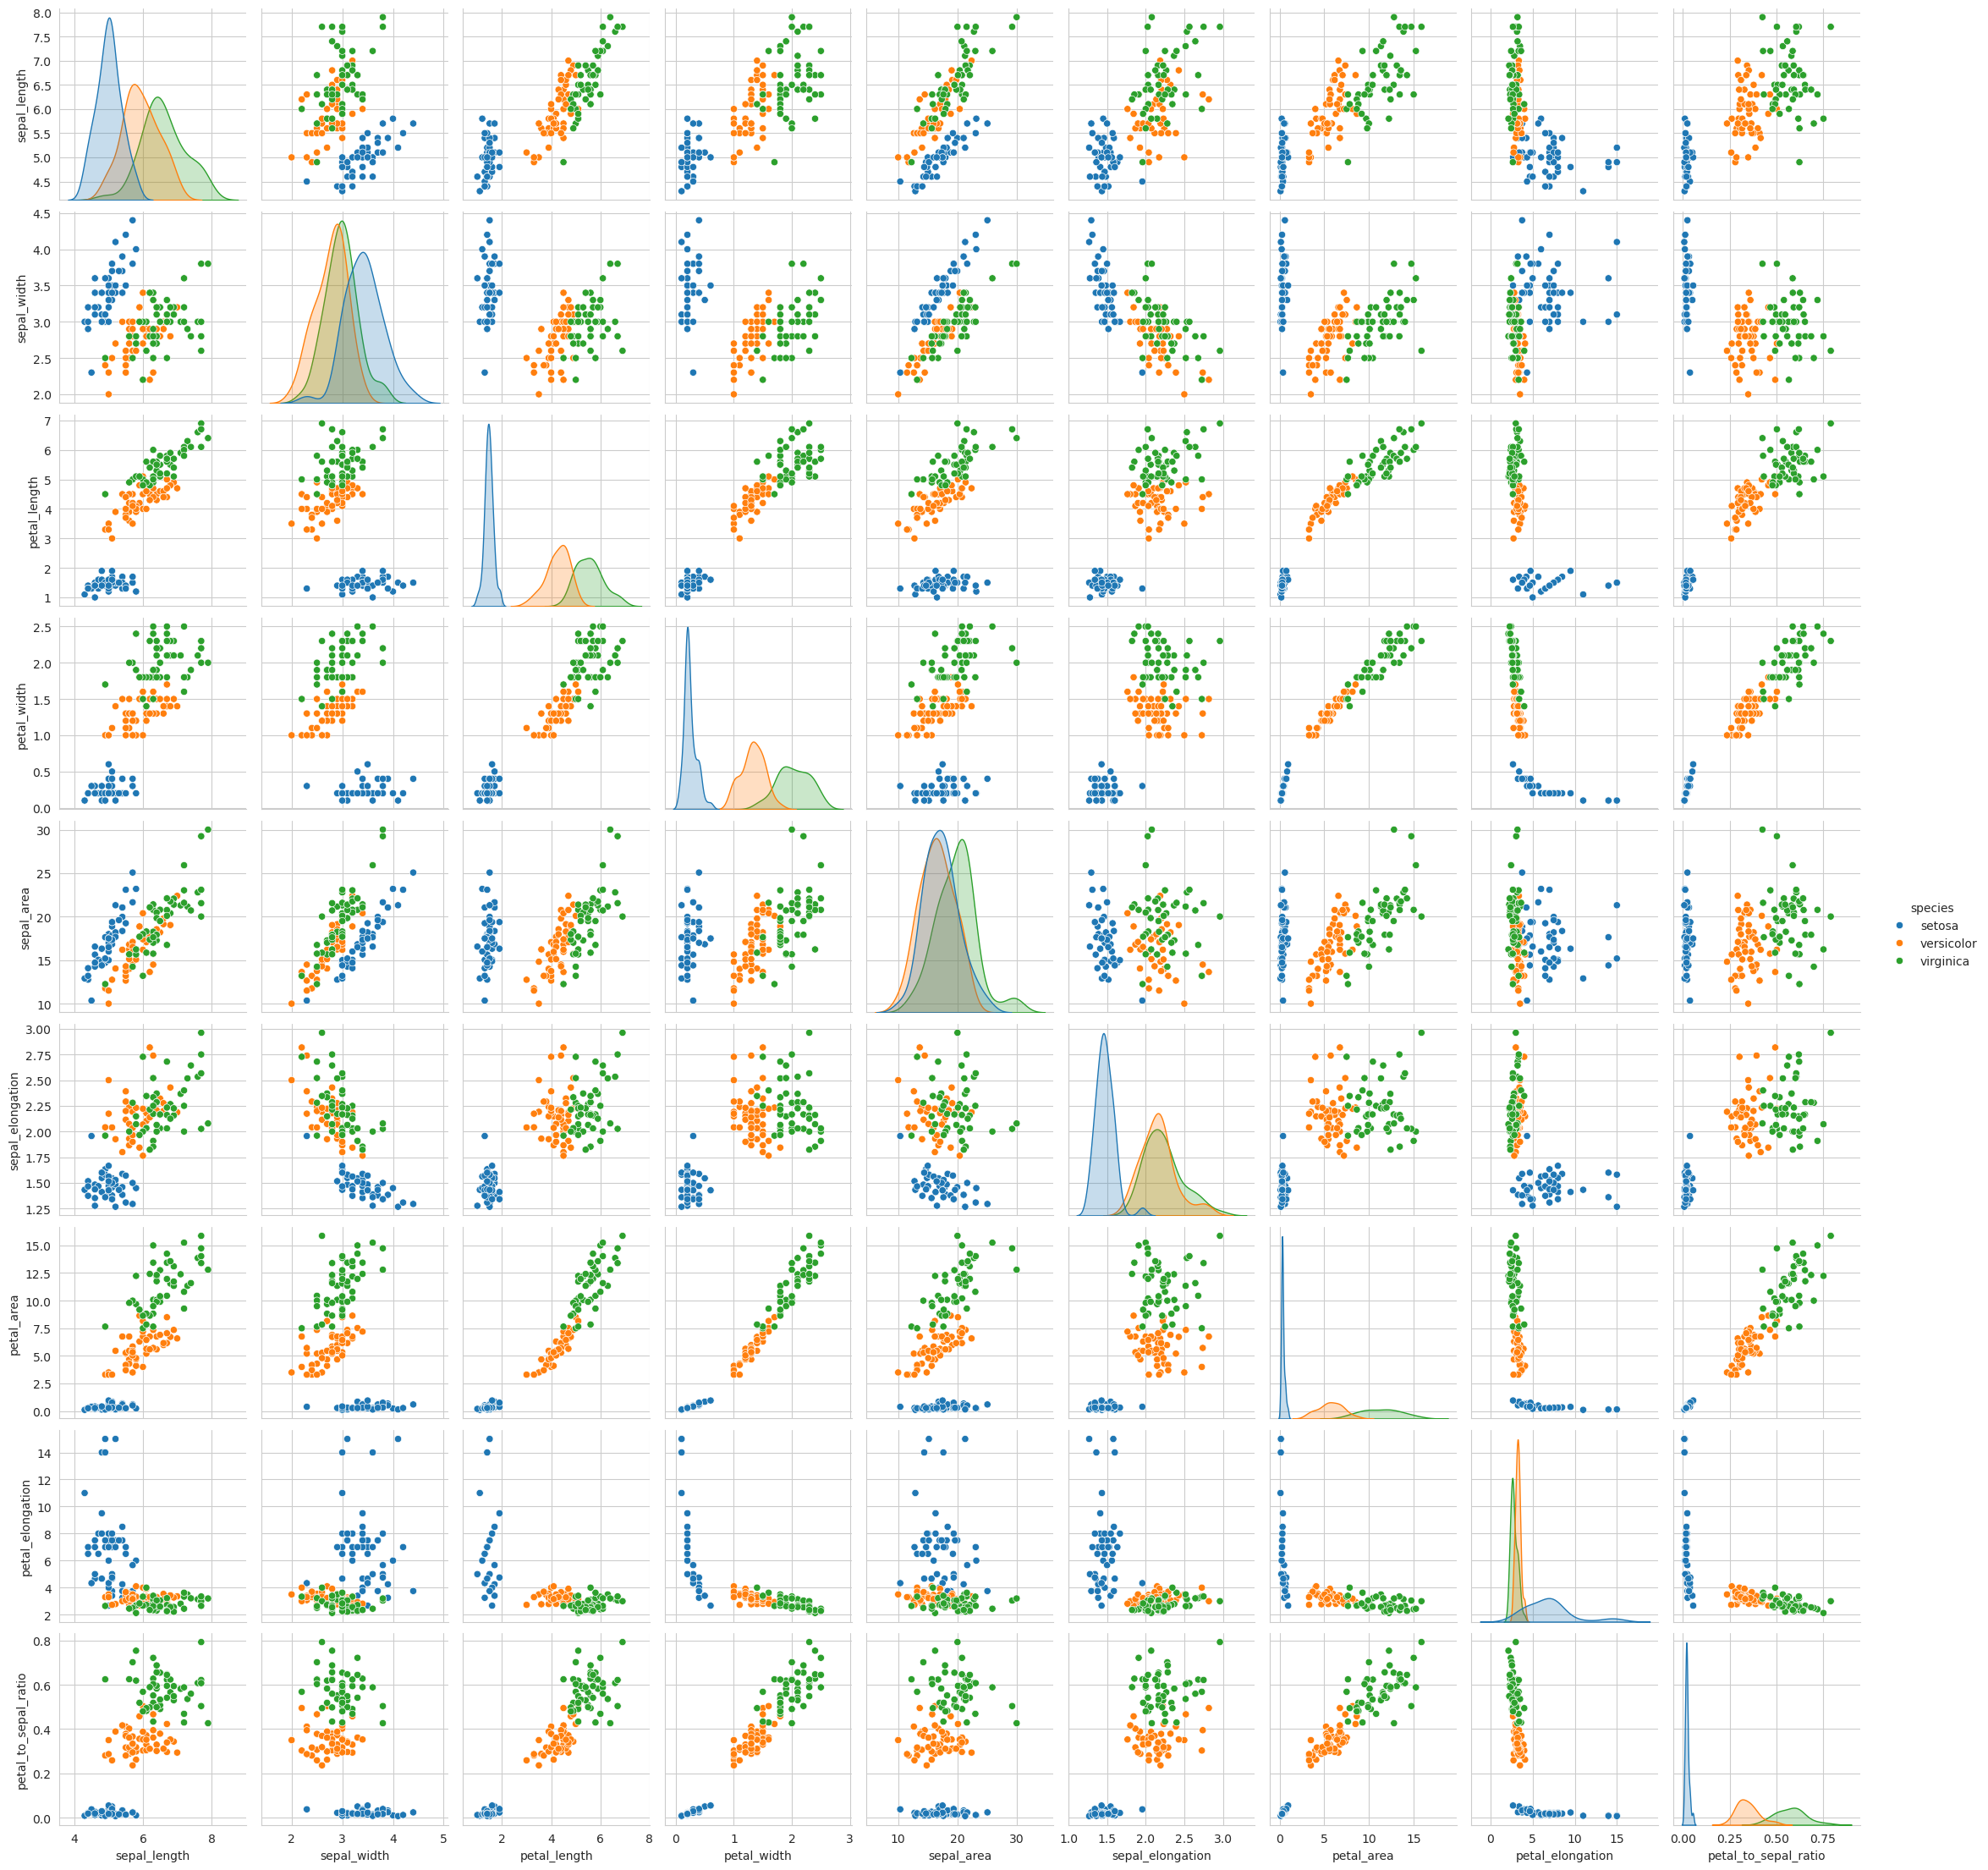

In [32]:
sns.pairplot(engineered_data, hue='species')

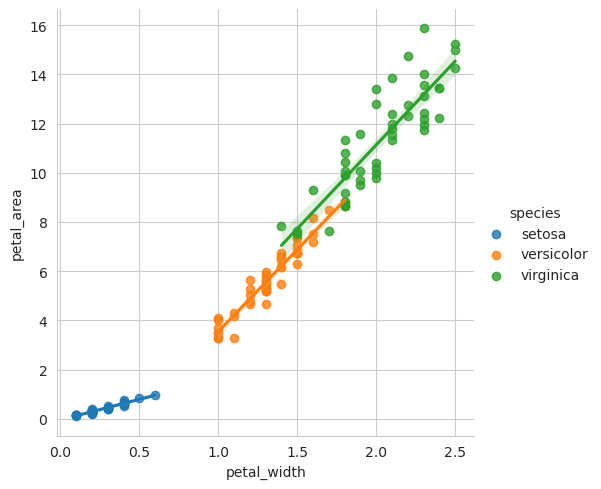

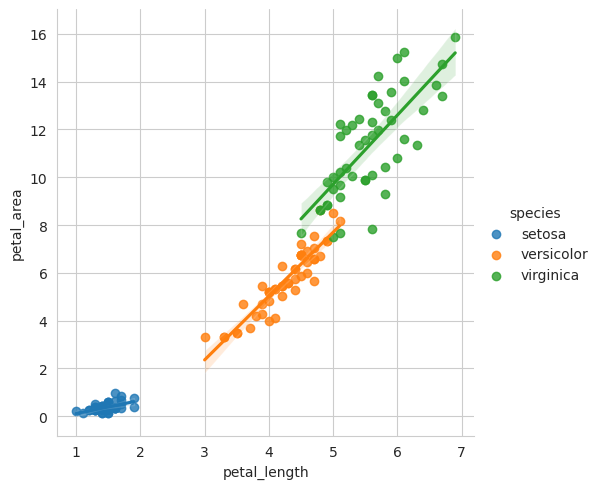

In [33]:
sns.lmplot(engineered_data, x='petal_width', y='petal_area', hue='species')
sns.lmplot(engineered_data, x='petal_length', y='petal_area', hue='species')

Are the new features we devised useful? Let us consider, for example, their mutual information.

In [34]:
data_features = data[[col for col in data.columns if col != 'species']]
data_target = data['species']

dict(zip(data_features.columns, mutual_info_classif(data_features, data_target, random_state=0)))

{'sepal_length': 0.4593697100360723,
 'sepal_width': 0.26909912247380374,
 'petal_length': 0.9892032948532952,
 'petal_width': 0.9743211262106874}

In [35]:
engineered_features = engineered_data[[col for col in engineered_data.columns if col != 'species']]
engineered_target = engineered_data['species']

dict(zip(engineered_features.columns, mutual_info_classif(engineered_features, engineered_target, random_state=0)))

{'sepal_length': 0.49414972385669187,
 'sepal_width': 0.25067905439477056,
 'petal_length': 0.9921574784227125,
 'petal_width': 0.9831393430279984,
 'sepal_area': 0.010999897467599329,
 'sepal_elongation': 0.613628943136159,
 'petal_area': 1.0385779242996782,
 'petal_elongation': 0.6378800055925258,
 'petal_to_sepal_ratio': 1.003213155826935}

Let us plot some useful violin plots:

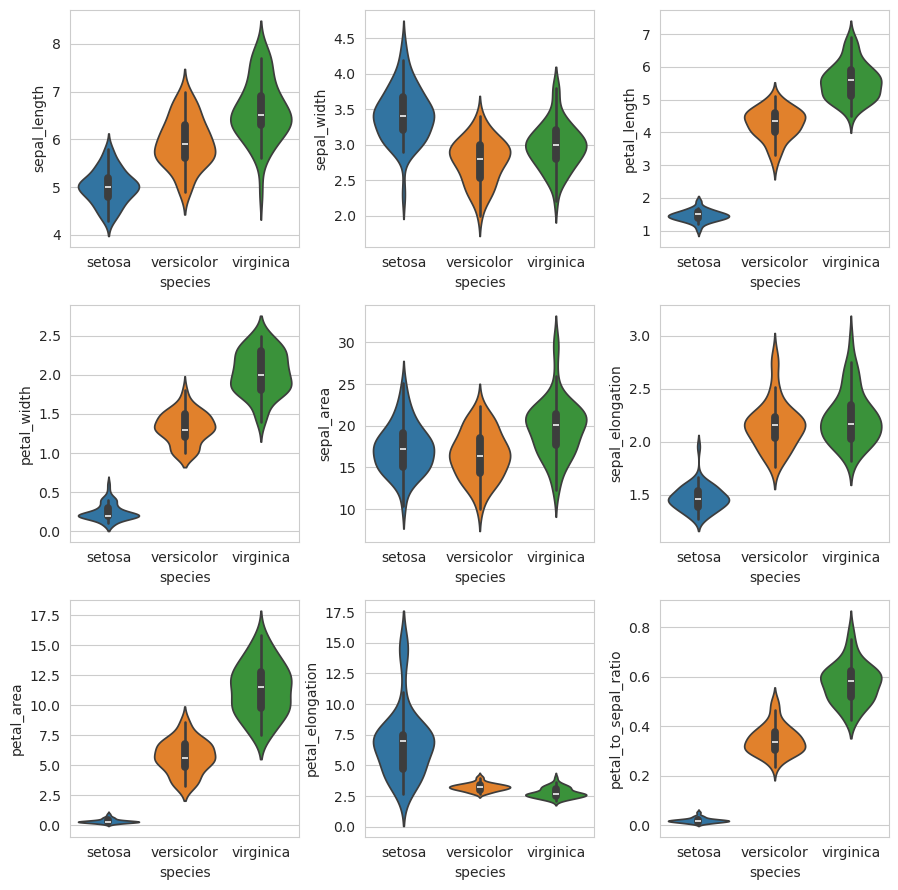

In [36]:
n_features = len(engineered_features.columns)

fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(3*3, 3*3))

for i in range(3):
    for j in range(3):
        y_col = engineered_features.columns[i*3+j]
        sns.violinplot(engineered_data, x='species', y=y_col, hue='species', ax=ax[i, j])

plt.tight_layout()

And some `lmplot`'s:

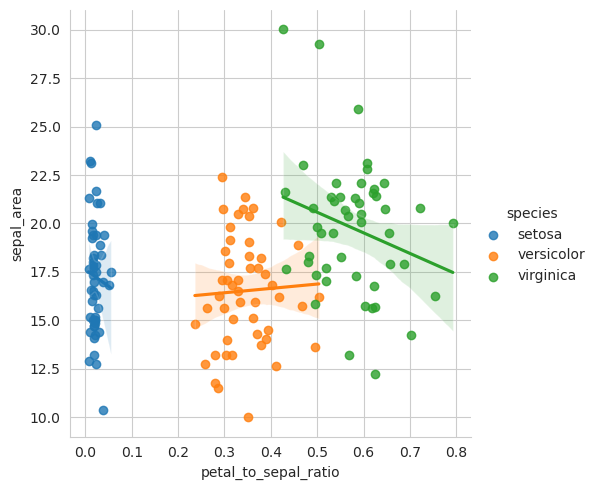

In [37]:
sns.lmplot(engineered_data, x='petal_to_sepal_ratio', y='sepal_area', hue='species')

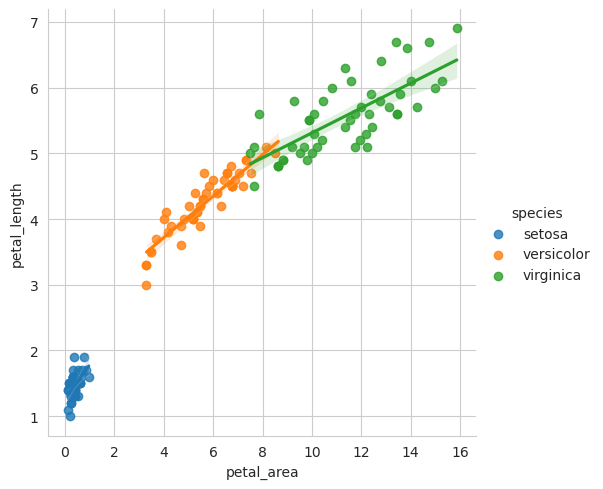

In [38]:
sns.lmplot(engineered_data, x='petal_area', y='petal_length', hue='species')

## 5. Preprocessing

### Importing modules

In [39]:
from sklearn.pipeline import Pipeline

from sklearn.base import BaseEstimator, TransformerMixin
# from sklearn.utils.validation import validate_data

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, PowerTransformer, StandardScaler

from sklearn.model_selection import train_test_split

# from sklearn.preprocessing import MinMaxScaler
# from scipy.stats import boxcox
# from sklearn.model_selection import cross_val_score

from sklearn.feature_selection import mutual_info_classif, SelectKBest, RFE, RFECV

### Feature Engineering

The new features we discovered were actually very informative (they had a high MI score). As a reminder, here are the MI scores for the original features:

In [40]:
data_features = data[[col for col in data.columns if col != 'species']]
data_target = data['species']

dict(zip(data_features.columns, mutual_info_classif(data_features, data_target, random_state=0)))

{'sepal_length': 0.4593697100360723,
 'sepal_width': 0.26909912247380374,
 'petal_length': 0.9892032948532952,
 'petal_width': 0.9743211262106874}

And for the new features:

In [41]:
engineered_features = engineered_data[[col for col in engineered_data.columns if col != 'species']]
engineered_target = engineered_data['species']

dict(zip(engineered_features.columns, mutual_info_classif(engineered_features, engineered_target, random_state=0)))

{'sepal_length': 0.49414972385669187,
 'sepal_width': 0.25067905439477056,
 'petal_length': 0.9921574784227125,
 'petal_width': 0.9831393430279984,
 'sepal_area': 0.010999897467599329,
 'sepal_elongation': 0.613628943136159,
 'petal_area': 1.0385779242996782,
 'petal_elongation': 0.6378800055925258,
 'petal_to_sepal_ratio': 1.003213155826935}

 Therefore, let us create an instance of a Feature Engineering class to include it in our future pipeline:

In [42]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    A scikit-learn compatible transformer that applies a feature engineering function
    to a pandas DataFrame X and returns an expanded DataFrame including new features.
    """
    def __init__(self, func):
        """
        Parameters
        ----------
        func : callable
            A function that takes a pandas DataFrame X and returns a pandas DataFrame
            of new features (with the same index as X) or an empty DataFrame.
        """
        self.func = func

    def fit(self, X, y=None):

        # No fitting necessary
        
        return self

    def transform(self, X):
        
        # 1. Check we got a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise ValueError("FeatureAdder.transform input must be a pandas DataFrame")

        # 2. Compute new features
        X_new = self.func(X.copy())

        if not isinstance(X_new, pd.DataFrame):
            raise ValueError("func must return a pandas DataFrame")

        # 3. Ensure no name collisions:
        overlap = set(X.columns).intersection(X_new.columns)
        if overlap:
            # raise ValueError(f"Naming collision between original and new features: {overlap}")
            return X

        # 4. Concatenate side by side
        X_out = pd.concat([X, X_new], axis=1)

        return X_out

### Splitting: Features v. Target

Selecting the features (all columns) and the target:

In [43]:
# features vs. target
X = data.select_dtypes(exclude=['object']) # features
y = data['species'] # target

Unique target values:

In [44]:
classes = np.unique(y) # finding the unique values of the species, sorted
print("sorted out species/classes:", classes)

sorted out species/classes: ['setosa' 'versicolor' 'virginica']


### Encoding Target data

We begin by label-encoding the targets:

In [45]:
le = LabelEncoder() # defining label encoder

y_encoded = le.fit_transform(y) # fitting and transforming validation data
y_encoded = pd.Series(y_encoded, name='encoded_'+y.name) # turning it into pandas Series 

Sanity check:

In [46]:
print("Disagreements between original data and its encoding: ", (le.inverse_transform(y_encoded) != y).any())

Disagreements between original data and its encoding:  False


### Splitting: Training vs. Validation

The data is to be split once, and then used in all models.

In [47]:
# training vs. validation
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.25, random_state=1)

In [48]:
print("X_train.head():\n"+"."*20+"\n", X_train.head())
print("-"*50)
print("y_train.head():\n"+"."*20+"\n", y_train.head())
print("-"*50)
print("y_train.value_counts():\n"+"."*20+"\n", y_train.value_counts())

X_train.head():
....................
      sepal_length  sepal_width  petal_length  petal_width
17            5.1          3.5           1.4          0.3
113           5.7          2.5           5.0          2.0
143           6.7          3.3           5.7          2.5
69            5.6          2.5           3.9          1.1
75            6.6          3.0           4.4          1.4
--------------------------------------------------
y_train.head():
....................
 17     0
113    2
143    2
69     1
75     1
Name: encoded_species, dtype: int64
--------------------------------------------------
y_train.value_counts():
....................
 2    38
0    37
1    36
Name: encoded_species, dtype: int64


### Scaling

For this model, it's best if we scale the features: normalize them, and then scale them:

In [49]:
# my_scaler = MinMaxScaler() # defining the scaler: MinMx
boxcox_scaler = PowerTransformer(method='box-cox', standardize=True) # defining the scaler: Box-Cox; note that I use this instead of scipy.stats.boxcox because the latter would require me to rescale the X data before splitting...
z_scaler = StandardScaler()

Let us then include our scalers into several Column Transformers that will be part of a single pipeline. We better make sure we include all columns!

In [50]:
def scaling_preprocessor():

    # box-cox transformer. Note that the other columns are just passed through, and that we are NOT changing the names of the columns with the 'verbose' feature (which prepends the name of the transformer to the column)
    boxcox_trans = ColumnTransformer(transformers=[('box-cox', boxcox_scaler, slice(0, None))], remainder="passthrough", verbose_feature_names_out=False)

    # z_scaler transformer. Note that the other columns are just passed through, and that we are NOT changing the names of the columns with the 'verbose' feature (which prepends the name of the transformer to the column)
    zscaler_trans = ColumnTransformer(transformers=[('z_scaler', z_scaler, slice(0, None))], remainder="passthrough", verbose_feature_names_out=False)

    # NOTE: ColumnTransformers act IN PARALLEL, NOT SEQUENTIALLY. In other words, had we put each scaler into a single ColumnTransformer (transformers=[(...box-cox...), (...z_scaler...)]), then we would be applying each transformer on the original data *independently instead of sequentially* of the other, and then putting all the columns together!

    # To apply them in sequence instead, we need to use a Pipeline:
    preproc = Pipeline(steps=[('box-cox', boxcox_trans),
                              ('z_scaler', zscaler_trans)])#.set_output(transform="pandas") # no need for this .set_output(...) method, because I have already demanded pandas globally

    # N.B.: with the method .set_output(transform="pandas") we ensure that the output is still a pd.DataFrame, so we can call the ColumnTransformers with the column names!
    
    return preproc

### Selector

Adding so many engineered features, while useful, leads to a much higher dimensionality space, which may be detrimental to a model's performace. In order to avoid this, we must select the most promising features.

We do this with our own selector

In [51]:
class RedundancyFilteredSelector(BaseEstimator, TransformerMixin):
    """Select features by mutual information with y, 
       dropping features correlated above `corr_threshold`."""
    
    def __init__(self, n_features=None, corr_threshold=0.9, random_state=None):
        """
        Parameters
        ----------
        n_features : int or None
            Maximum number of features to select. If None, selects until no candidates remain.
        corr_threshold : float
            Absolute Pearson correlation threshold above which a feature is considered redundant.
        random_state : int or None
            For mutual_info_classif sampling reproducibility.
        """
        self.n_features = n_features
        self.corr_threshold = corr_threshold
        self.random_state = random_state
        
    def fit(self, X, y):
        """
        Fit the selector: compute MI scores and select a nonredundant subset.
        
        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
        y : array-like, shape (n_samples,)
        """
        X = pd.DataFrame(X, index=X.index)  # ensures column indexing
        self.feature_names_ = X.columns.tolist()
        
        # 1. Compute mutual information for each feature
        mi = mutual_info_classif(X, y, random_state=self.random_state)
        mi_series = pd.Series(mi, index=self.feature_names_)
        
        # 2. Sort features by descending MI
        candidates = mi_series.sort_values(ascending=False).index.tolist()
        
        # 3. Compute full correlation matrix once
        corr_matrix = X.corr().abs()
        
        selected = []
        for feat in candidates:
            # Stop if reached n_features
            if (self.n_features is not None) and (len(selected) >= self.n_features):
                break
            
            # Skip if too correlated with any already selected
            if any(corr_matrix.loc[feat, sel] >= self.corr_threshold 
                   for sel in selected):
                continue
            
            selected.append(feat)
        
        self.selected_features_ = selected
        return self
    
    def transform(self, X):
        """
        Reduce X to the selected features.
        
        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
        """
        X = pd.DataFrame(X, index=X.index)
        return X[self.selected_features_]#.values
    
    def get_support(self):
        """Mask of selected features (boolean array)."""
        mask = [f in self.selected_features_ for f in self.feature_names_]
        return np.array(mask)
    
    def get_feature_names_out(self, input_features=None):
        """Names of the selected features."""
        return np.array(self.selected_features_)


In [52]:
selector = RedundancyFilteredSelector(random_state=0)

### Final Preprocessing Pipelines

In [53]:
from sklearn.base import clone

Putting together the preprocessing steps into a single pipeline:

In [54]:
final_preproc = {'raw':Pipeline(steps=[('scaler', scaling_preprocessor())]),
                 'eng':Pipeline(steps=[('feature_engineer', FeatureEngineer(func=new_iris_features)),
                                       ('scaler', scaling_preprocessor()),
                                       ('selector', selector)])}

In [55]:
temp_pipe = clone(final_preproc['eng'])

new_eng_data = temp_pipe.fit_transform(X_train, y_train)
print(new_eng_data.head())

del new_eng_data, temp_pipe

     petal_area  sepal_elongation  sepal_length  sepal_width  sepal_area
17    -1.235242         -1.287930     -0.873102     1.118810    0.106187
113    0.885151          0.839458     -0.097574    -1.366086   -1.080385
143    1.328536          0.220252      1.047482     0.650621    1.314035
69     0.044228          0.741564     -0.221657    -1.366086   -1.170120
75     0.370002          0.643190      0.940046    -0.076494    0.681171


## 6. Pipelines

### Importing Modules

In [56]:
# cross-validation
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, RepeatedStratifiedKFold

# scoring and evaluation
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

# checking if model is fitted
from sklearn.utils.validation import check_is_fitted
from sklearn.exceptions import NotFittedError

# ML explainability
import shap
from sklearn.inspection import permutation_importance, partial_dependence
from scipy.stats import gaussian_kde
from sklearn.tree import plot_tree
from xgboost import plot_tree as xgb_plot_tree

# MODELS
# tree-based
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# need scaling, or at least it doesn't hurt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

/home/mbuenabad/anaconda3/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


### Useful Definitions

We begin by defining a verbosity function:

In [57]:
# verbosity function
def verbosity(verbose, message):
    """
    A function that helps us print a message only when asked.
    """
    if verbose:
        print(message)
    else:
        pass

Now, some important dictionaries that we will fill during model evaluation:

In [58]:
# defining some important dictionaries, whose keys are the models we will study

pipe = {} # dictionary of model pipelines

# for cross-validation (CV):
param_grid = {} # dictionary of model hyperparameter grids

search = {} # dictionary of model CV searches

best_cv = {} # dictionary of model with best CV performance

Finally, the score dataframe which we will fill up:

In [59]:
# Create a score dataframe
scorecard = pd.DataFrame(index = ['Precision Train', 'Precision Validation',
                                  'Recall Train', 'Recall Validation',
                                  'Accuracy Train', 'Accuracy Validation',
                                  'F1 Train', 'F1 Validation'])

### Evaluation

We will do cross-validation, and also perform some basic hyperparameter optimization. For that, we need to define a function that defines the pipeline, evaluates the model with cross-validation, computes the metrics, spits out some plots (_e.g._, the confussion matrix), and allocates results to a dictionary. Must take a model/pipeline for argument, the hyperparameter grid, and the CV arguments and such. Also flags for if we want plots, SHAP, permutation importance, etc.

In [60]:
def model_evaluation(model_name, Xytv, avg='macro', perform_cv_randomized=(False,False), scoring='f1_macro', verbose=False, plots=False, random_state=0, n_jobs=safe_cpus, **kwargs):
    """
    A function that evaluates a given model. Pass the model name and data, it will read out its pipeline (and param grid, if CV; all of them must have been previously defined), and perform the model_name evaluation according to the scoring requested. May also show plots and describe each step it takes, if the flags are set to True.
    """

    # splitting the datasets
    Xt, Xv, yt, yv = Xytv

    # splitting the CV and randomized flags
    perform_cv, randomized = perform_cv_randomized

    # the validation key
    val_key = '_cv' if perform_cv else '_no_cv'

    #-------------------------------------------
    # no cross-validation
    if not perform_cv:
        verbosity(verbose, (":"*70) + f"\nWe will evaluate model={model_name} with standard validation.\n" + ":"*70)

        # checking if model is fitted:
        try:
            check_is_fitted(pipe[model_name+'_no_cv'].steps[-1][-1])
            verbosity(verbose, "\n -> Model is already fitted!")

        # if not, fit:
        except NotFittedError:
            verbosity(verbose, "\n -> Fitting the model")
            pipe[model_name+'_no_cv'].fit(Xt, yt)
            verbosity(verbose, "......Done!")

        # predictions
        verbosity(verbose, " -> Making predictions")
        
        yt_pred = pipe[model_name+'_no_cv'].predict(Xt)
        yv_pred = pipe[model_name+'_no_cv'].predict(Xv)
        
        verbosity(verbose, "......Done!")

    #-------------------------------------------
    # cross-validation
    else:
        verbosity(verbose, f"We will evaluate {model_name} with cross-validation.")

        # RSKF
        verbosity(verbose, "\n -> Creating instance of `RepeatedStratifiedKFold`")

        sig = inspect.signature(RepeatedStratifiedKFold)
        default_rskf_kwargs = [k for k, v in sig.parameters.items() if v.default is not inspect._empty] # keyword arguments of RepeatedStratifiedKFold
        rskf_kwargs = {k:v for k, v in kwargs.items() if k in default_rskf_kwargs} # picking arguments in kwargs that are meant for RepeatedStratifiedKFold
        rskf = RepeatedStratifiedKFold(random_state=random_state, **rskf_kwargs)
        
        verbosity(verbose, "......Done!")

        # creating the CV search
        verbosity(verbose, " -> Creating the CV search")
        
        # randomized search
        if randomized:
            sig = inspect.signature(RandomizedSearchCV)
            default_cvsearch_kwargs = [k for k, v in sig.parameters.items() if v.default is not inspect._empty] # keyword arguments of RandomizedSearchCV
            cvsearch_kwargs = {k:v for k, v in kwargs.items() if k in default_cv_search_kwargs} # picking arguments in kwargs that are meant for RandomizedSearchCV

            searcher = RandomizedSearchCV(pipe[model_name],
                                          param_grid=param_grid[model_name],
                                          cv=rskf,
                                          scoring=scoring,
                                          n_jobs=n_jobs,
                                          random_state=random_state,
                                          # error_score="raise",
                                          **cvsearch_kwargs)

        # grid search
        else:
            searcher = GridSearchCV(pipe[model_name],
                                    param_grid=param_grid[model_name],
                                    cv=rskf,
                                    scoring=scoring,
                                    # error_score="raise",
                                    n_jobs=n_jobs)

        verbosity(verbose, "......Done!")

        # checking if model is fitted:
        # first, check that the model_name is in the 'search' dictionary, and that it has attribute "best_estimator_" (which indicates it is fitted)
        if (model_name in search.keys()) and hasattr(search[model_name], "best_estimator_"):
            verbosity(verbose, "\n -> Model is already fitted!")
        else:
            # then it is either not in the 'search' dictionary, or it is but it is not fit:
            search[model_name] = searcher
            verbosity(verbose, "\n -> Fitting the model")
            search[model_name].fit(Xt, yt)
            verbosity(verbose, "......Done!")

        # picking the best from CV
        best_cv[model_name] = {}
        best_cv[model_name]['pipe'] = search[model_name].best_estimator_
        best_cv[model_name]['model'] = best_cv[model_name]['pipe'].named_steps['model']
        best_cv[model_name]['score'] = search[model_name].best_score_
        best_cv[model_name]['params'] = search[model_name].best_params_

        if verbose:
            print(" -> CV Results:")
            print(f"\t\tbest {scoring}: {best_cv[model_name]['score']}")
            print(f"\t\tbest params: {best_cv[model_name]['params']}")
            # print("\n")
            # print("."*100)
            # for score, std, params in zip(search[model_name].cv_results_['mean_test_score'], search[model_name].cv_results_['std_test_score'], search[model_name].cv_results_['params']):
            #     print(f"mean CV {scoring} score: {score:.4f} +- {std:.4e} --> {params}")
            verbosity(verbose, "......Done!")

        # predictions
        verbosity(verbose, " -> Making predictions")
        
        yt_pred = best_cv[model_name]['pipe'].predict(Xt)
        yv_pred = best_cv[model_name]['pipe'].predict(Xv)
        
        verbosity(verbose, "......Done!")


    #-------------------------------------------
    # classification report
    verbosity(verbose, " -> Creating Classification Reports")
    
    cr_train = classification_report(y_true=yt, y_pred=yt_pred, output_dict=True)
    cr_val = classification_report(y_true=yv, y_pred=yv_pred, output_dict=True)
    
    verbosity(verbose, "......Done!")

    # printing classification reports
    if verbose:
        print("\n")
        cr_train2 = pd.DataFrame(cr_train).T
        print("Classification Report: Training\n"+"."*50)
        print(cr_train2.to_markdown())
        print("\n")
        cr_val2 = pd.DataFrame(cr_val).T
        print("Classification Report: Validation\n"+"."*50)
        print(cr_val2.to_markdown())

    #-------------------------------------------
    # computing scores:
    verbosity(verbose, "\n -> Computing Scores")
        
    precision_train = cr_train[avg+' avg']['precision']
    precision_val = cr_val[avg+' avg']['precision']

    recall_train = cr_train[avg+' avg']['recall']
    recall_val = cr_val[avg+' avg']['recall']

    acc_train = accuracy_score(y_true=yt, y_pred=yt_pred)
    acc_val = accuracy_score(y_true=yv, y_pred=yv_pred)

    F1_train = cr_train[avg+' avg']['f1-score']
    F1_val = cr_val[avg+' avg']['f1-score']

    model_score = [precision_train, precision_val, recall_train, recall_val, acc_train, acc_val, F1_train, F1_val]
        
    verbosity(verbose, "......Done!")

    #-------------------------------------------
    # compare more f1's
    if verbose:
        print("\n"+"*"*50 + "\nDetailed Validation F1 scores:")
        print("."*50)
        for species, f1 in zip(classes, f1_score(yv, yv_pred, average=None)):
            print(species+" f1 score:\t", f1) # compute F1 for each class
        print("."*50)
        for method in ['micro', 'macro', 'weighted']:
            print(method+":", f1_score(y_true=yv, y_pred=yv_pred, average=method)) # compute F1 for each different kind of average

    #-------------------------------------------
    if plots:
        # calculate confusion matrix
        cm_train = confusion_matrix(yt, yt_pred)
        cm_val = confusion_matrix(yv, yv_pred)

        fig, ax = plt.subplots(1, 2, figsize=(11,4))

        print("*"*50 + "\nConfusion Matrices:")
        sns.heatmap(cm_train, annot=True, xticklabels=classes, yticklabels=classes, cmap="Reds", fmt='.4g', ax=ax[0])
        ax[0].set_xlabel("Predicted Label")
        ax[0].set_ylabel("True Label")
        ax[0].set_title("Training Confusion Matrix")

        sns.heatmap(cm_val, annot=True, xticklabels=classes, yticklabels=classes, cmap="Greens", fmt='.4g', ax=ax[1])
        ax[1].set_xlabel("Predicted Label")
        ax[1].set_ylabel("True Label")
        ax[1].set_title("Validation Confusion Matrix")

        plt.tight_layout()
        plt.show()

    #-------------------------------------------
    # updating scorecard
    scorecard[model_name+val_key] = model_score

    #-------------------------------------------
    # returning the model's score

    return model_score 

### Explanation

We begin by defining a function that helps us visualize a model, by plotting some useful figures:

In [61]:
def model_visualization(fitted_pipeline, Xytv,
                        feature_names, target_names,
                        selected_features=None, tree_idx=0):
    """
    Visualize various diagnostics for classification models.

    Parameters:
    - model_name: name of the model in question
    - fitted_pipeline: complete pipeline, trained
    - Xytv: training and validation feature and target data arrays (X_train, X_val, y_train, y_val)
    - feature_names: list or Index of feature names
    - target_names: list or Index of target class names
    - selected_features: optional tuple of two feature names for 2D plots
    - tree_idx: index denoting the tree to plot, in tree-based, forest models
    """

    # splitting the pipeline into preprocessing steps and the actual model
    preproc = fitted_pipeline[:-1] # all preprocessing steps
    model = fitted_pipeline[-1] # model

    # splitting the datasets
    Xt, Xv, yt, yv = Xytv

    # processing the features with the fitted pipeline
    Xt = preproc.transform(Xt)
    Xv = preproc.transform(Xv)
    
    # Ensure feature_names and target_names are list
    if isinstance(feature_names, (pd.Index, np.ndarray)):
        feature_names = list(feature_names)
    if isinstance(target_names, (pd.Index, np.ndarray)):
        target_names = list(target_names)

    # finding the numerical names of the first two selected columns/features
    first_feat_idx = Xt.columns.get_loc(selected_features[0])
    second_feat_idx = Xt.columns.get_loc(selected_features[1])

    # Determine which plots apply
    plots = []
    if isinstance(model, DecisionTreeClassifier):
        plots += ['tree', 'pdp']
    elif isinstance(model, RandomForestClassifier):
        plots += ['rf_tree', 'pdp']
    elif isinstance(model, XGBClassifier):
        plots += ['xgb_tree', 'pdp']
    elif isinstance(model, LogisticRegression):
        plots += ['coef_heatmap', 'pdp']
    elif isinstance(model, SVC):
        plots += ['svm_sv', 'pdp']
    elif isinstance(model, KNeighborsClassifier):
        plots += ['knn_dist', 'pdp']
    elif isinstance(model, GaussianNB):
        plots += ['nb_kde', 'pdp']
    elif isinstance(model, MLPClassifier):
        plots += ['mlp_arch', 'pdp']

    # Setup plot grid
    nplots = len(plots)
    ncols = 2
    nrows = int(np.ceil(nplots / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
    axes = axes.flatten()

    # setup palette
    palette = sns.color_palette('hls', n_colors=len(classes))

    # Plot loop
    for ax, ptype in zip(axes, plots):
        if ptype == 'tree':
            # decision tree plot for DT
            plot_tree(model, filled=True, feature_names=feature_names,
                      class_names=target_names, ax=ax)
            ax.set_title('Decision Tree')

        elif ptype == 'rf_tree':
            # decision tree plot for one of the RF trees
            plot_tree(model.estimators_[tree_idx], filled=True,
                      feature_names=feature_names, class_names=target_names,
                      ax=ax)
            ax.set_title('RandomForest First Tree')

        elif ptype == 'xgb_tree':
            # decision tree plot for one of the XGB trees
            xgb_plot_tree(model, num_trees=tree_idx, ax=ax)
            ax.set_title('XGBoost First Tree')

        elif ptype == 'coef_heatmap':
            # Heatmap of the log-regression coefficients
            coef_mat = model.coef_
            sns.heatmap(coef_mat, xticklabels=feature_names, yticklabels=target_names, annot=True, ax=ax)
            ax.set_title('LogReg Coef Heatmap')

        elif ptype == 'svm_sv':

            # concatenating the training data, for easier color identification based on target
            Xyt = pd.concat([Xt, yt], axis=1)

            # scatterplot of training data
            sns.scatterplot(data=Xyt, x=selected_features[0], y=selected_features[1], hue=yt.name, palette=palette, hue_order=list(le.transform(classes)), ax=ax)

            # support vectors (SVs) from SVM model
            sv = model.support_vectors_        

            # selecting the indices of those rows in the training data corresponding to the SVs
            mask = [(Xt==sv[i]).all(axis=1).reindex(Xt.index) for i in range(sv.shape[0])]
            idxs = [Xyt[mask[i]].index[0] for i in range(sv.shape[0])]

            # locating SVs (and their target values) in the training data
            sv_ys = Xyt.loc[idxs]
            # selecting the target names
            sv_ys = sv_ys[[yt.name]]
            # turning SVs arrays into pd.DataFrame
            sv = pd.DataFrame(sv, index=idxs)
            # plugging their target values
            svy = pd.concat([sv, sv_ys], axis=1)
            # defining the SVs' column names
            svy.columns=Xyt.columns
            
            # scatterplot of the SVs, with hues given by their real targets values (given by y_train); superimposed on previous scatterplot
            sns.scatterplot(data=svy, x=selected_features[0], y=selected_features[1], hue=yt.name, palette=palette, hue_order=list(le.transform(classes)), marker='s', s=50, ax=ax)
            ax.set_xlabel(selected_features[0])
            ax.set_ylabel(selected_features[1])
            ax.set_title('SVM Support Vectors')

        elif ptype == 'knn_dist':
            # neighbors of KNN model
            nbrs = NearestNeighbors(n_neighbors=model.n_neighbors).fit(Xt)
            # distances
            dists, _ = nbrs.kneighbors(Xt)
            kth = dists[:, -1]
            # histogram of distances
            sns.histplot(kth, bins=20, ax=ax)
            ax.set_title(f'KNN Distances (k={model.n_neighbors})')
            ax.set_xlabel('Distance to k-th neighbor')

        elif ptype == 'nb_kde':

            # 2D-grid size
            grid_size = 101

            # concatenating X_train and y_train
            Xyt = pd.concat([Xt, yt], axis=1)

            # scatterplot of the training data, with hues given by the training target values
            sns.scatterplot(data=Xyt, x=selected_features[0], y=selected_features[1], hue=yt.name, palette=palette, ax=ax, hue_order=list(le.transform(classes)))

            # Define grid over feature space
            x_min, x_max = Xt[selected_features[0]].min() - 1, Xt[selected_features[0]].max() + 1
            y_min, y_max = Xt[selected_features[1]].min() - 1, Xt[selected_features[1]].max() + 1
            xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_size),
                                 np.linspace(y_min, y_max, grid_size)
                                 )
            grid = np.column_stack([xx.ravel(), yy.ravel()])
    
            # Overlay Gaussian contours per class
            for idx, cls in enumerate(model.classes_):
                mu = np.array([model.theta_[idx, first_feat_idx], model.theta_[idx, second_feat_idx]])
                var = np.array([model.var_[idx, first_feat_idx], model.var_[idx, second_feat_idx]])
                rv = multivariate_normal(mean=mu, cov=var)
                zz = rv.pdf(grid).reshape(grid_size, grid_size)

                # gaussian contours, with the same hues as the scatterplot above
                ax.contour(xx, yy, zz, levels=5, linewidths=1.5,
                            colors=[palette[idx]])
            
            ax.legend(fontsize='small')
            ax.set_title('NB Feature KDE')

        elif ptype == 'mlp_arch':
            # MLP architecture (very simple)
            ax.axis('off')
            arch = [Xt.shape[1]] + list([model.hidden_layer_sizes]) + [len(target_names)]
            txt = '\n'.join(f'Layer {i}: {n} neurons' for i, n in enumerate(arch))
            ax.text(0.1, 0.5, txt, fontsize=12)
            ax.set_title('MLP Architecture')

        elif ptype == 'pdp': # partial dependence plots

            # selecting the feature whose PDP we want to study
            feature_name = selected_features[0] # pick only the most important feature

            # computing partial dependences
            pdp_results = partial_dependence(model, Xv, [feature_name],
                                             feature_names=[feature_name],
                                             kind='average', grid_resolution=100)
            
            # extracting the data from the above results
            grid_values   = pdp_results['grid_values'][0] # pick 1D array of feature values
            averages = pdp_results['average'] # shape = (n_classes, len(grid))

            # for each class, we compute the PDP curves
            for i, class_idx in enumerate(list(le.transform(classes))):

                class_name = le.inverse_transform(np.array([class_idx]))[0]

                # PDP curve
                ax.plot(grid_values, averages[i], label=str(class_idx)+ f" ({class_name})", color=palette[i])

            ax.legend(title='Target class')
            ax.set_title(f'PDP of "{feature_name}" for each class')
            ax.set_xlabel(feature_name)
            ax.set_ylabel('Partial dependence')

    # Remove unused axes
    for j in range(len(plots), len(axes)):
        axes[j].axis('off')

    fig.tight_layout()
    plt.show()

Now, defining a function to explain the model

In [62]:
def explain_model(model_name, fitted_pipeline, Xytv, selected_features=None, tree_idx=0, random_state=0):
    """
    A function that performs ML explainability on a given model.
    - model_name: name of the model in question
    - fitted_pipeline: complete pipeline, trained
    - Xytv: training and validation feature and target data arrays (X_train, X_val, y_train, y_val)
    - selected_features: optional tuple of two feature names for 2D plots
    - tree_idx: index denoting the tree to plot, in tree-based, forest models
    """

    # splitting the pipeline into preprocessing steps and the actual model
    preproc = fitted_pipeline[:-1] # preprocessing
    model = fitted_pipeline[-1] # model

    # splitting the datasets
    Xt, Xv, yt, yv = Xytv

    # processing the features with the fitted pipeline
    Xt_processed = preproc.transform(Xt)
    # Xt = Xt_processed
    Xv_processed = preproc.transform(Xv)

    # Permutation Importance
    print("*"*100 + "\nPerforming Permutation Importance:\n" + "."*50)

    # computing importances
    perm_import = permutation_importance(model, Xv_processed, yv, random_state=random_state)

    # zipping feature names and the means and stds of the importances
    feat_import = zip(Xv_processed.columns, perm_import['importances_mean'], perm_import['importances_std'])

    # sorting from highest to lowest means
    feat_import = sorted(feat_import, key=itemgetter(1), reverse=True)

    # printing
    print("The model's features are:\n")
    print([feat for feat, _, _ in feat_import])
    print("The most important features are:\n")
    for feat, mean, std in feat_import:
        print("\t"+feat+":", mean, "+-", std)
    print("\n" + ("*"*100) + "\n")

    # preparing for the explanatory plots
    # selecting the two most important features
    important_features = [column for column, importance, _ in feat_import][:2]

    # the featuresto plot: if selected_features == None pick the two most important ones
    feats_to_plot = important_features if selected_features == None else selected_features

    # plots from model_visualization function
    model_visualization(fitted_pipeline, Xytv,
                        Xv_processed.columns, classes,
                        selected_features=feats_to_plot, tree_idx=tree_idx)
    

    # SHAP
    tree_model = any([isinstance(model, DecisionTreeClassifier), isinstance(model, RandomForestClassifier), isinstance(model, XGBClassifier)])
    
    if tree_model:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(Xv_processed)
    elif 'logreg' in model_name:
        smaller_Xt = shap.sample(Xt_processed, 50)
        explainer = shap.LinearExplainer(model, smaller_Xt)
        shap_values = explainer.shap_values(Xv_processed)
    elif any([('svc' in model_name), ('knn' in model_name)]):
        smaller_Xt = shap.sample(Xt_processed, 50)
        explainer = shap.KernelExplainer(model.predict_proba, smaller_Xt, link='logit')
        shap_values = explainer.shap_values(Xv_processed)
    elif 'mlp' in model_name:
        smaller_Xt = shap.sample(Xt_processed, 50)
        # explainer = shap.DeepExplainer(model, smaller_Xt)
        explainer = shap.KernelExplainer(model.predict_proba, smaller_Xt, link='logit')
        shap_values = explainer.shap_values(Xv_processed)
    else:
        pass

    # for a GaussianNB() model, we cannot compute the SHAP values, and thus we cannot make the corresponding plots
    if 'gnb' not in model_name:

        for i in range(len(classes)):
            plt.figure()
            shap.summary_plot(shap_values[:,:,i], Xv_processed, show=False)
            plt.title('Class: '+f'{le.transform([classes[i]])[0]} ('+classes[i]+')')
            plt.tight_layout()
            plt.show()

    pass

## 7. Models

### Model 0: Baseline (`RandomForestClassifier`)

In [63]:
model = 'rfc'

model_name = model+'_base' # full model name

preproc_pipe = clone(final_preproc['raw'])

pipe[model_name+'_no_cv'] = Pipeline(steps=[('preprocessor', preproc_pipe),
                                            ('model', RandomForestClassifier(random_state=0))])

***************************************************************************
rfc_base 

***************************************************************************
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
We will evaluate model=rfc_base with standard validation.
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 -> Fitting the model
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        37 |
| 1            |           1 |        1 |          1 |        36 |
| 2            |           1 |        1 |          1 |        38 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |           1 |  

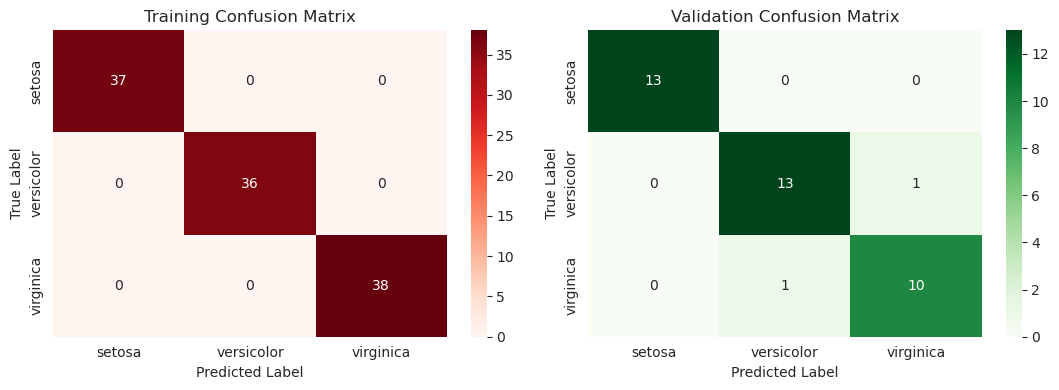

[1.0,
 0.9458874458874459,
 1.0,
 0.9458874458874459,
 1.0,
 0.9473684210526315,
 1.0,
 0.9458874458874459]

In [64]:
print("*"*75)
print(model_name, "\n")
print("*"*75)

model_evaluation(model_name, (X_train, X_val, y_train, y_val),
                 perform_cv_randomized=(False, False),
                 verbose=True, plots=True)

### Model 1: `DecisionTreeClassifier`

Defining the pipelines and hyperparameter grids:

In [65]:
model = 'dtc'

for pp in ['raw', 'eng']:

    model_name = model+'_'+pp # full model name

    preproc_pipe = final_preproc[pp] # preprocessing  pipeline

    pipe[model_name] = Pipeline(steps=[('preprocessor', preproc_pipe),
                                       ('model', DecisionTreeClassifier(random_state=0))])

    pipe[model_name+'_no_cv'] = Pipeline(steps=[('preprocessor', preproc_pipe),
                                                ('model', DecisionTreeClassifier(random_state=0))])

    # defining the hyperparameter grid
    if pp == 'raw':
        param_grid[model_name] = {'model__max_leaf_nodes': [None] + list(range(2, 11)),
                                  'model__max_depth': [None] + list(range(1,11))}
    else:
        param_grid[model_name] = {'model__max_leaf_nodes': [None] + list(range(2, 11)),
                                  'model__max_depth': [None] + list(range(1,11)),
                                  'preprocessor__selector__n_features': [None, len(X.columns)],
                                  'preprocessor__selector__corr_threshold': [0.5, 0.7, 0.9]}

Performing the evaluation and explanation of the model:

***************************************************************************
dtc_raw , 	CV: False 

***************************************************************************
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
We will evaluate model=dtc_raw with standard validation.
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 -> Fitting the model
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        37 |
| 1            |           1 |        1 |          1 |        36 |
| 2            |           1 |        1 |          1 |        38 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |     

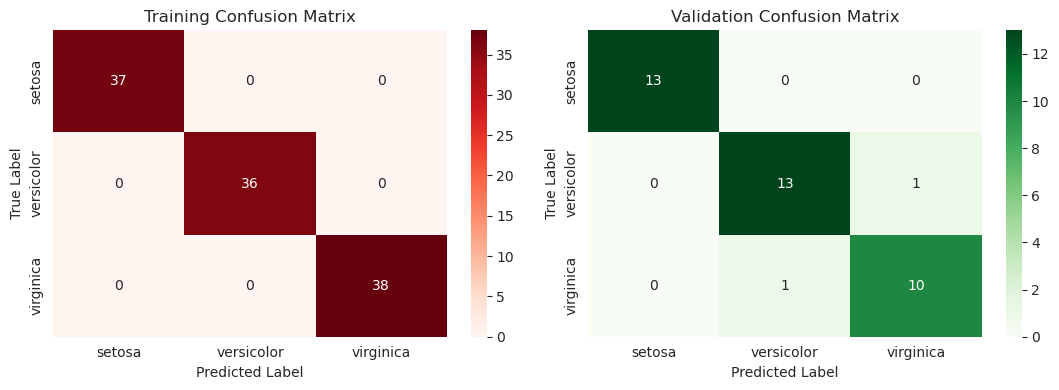






***************************************************************************
dtc_raw , 	CV: True 

***************************************************************************
We will evaluate dtc_raw with cross-validation.

 -> Creating instance of `RepeatedStratifiedKFold`
......Done!
 -> Creating the CV search
......Done!

 -> Fitting the model
......Done!
 -> CV Results:
		best f1_macro: 0.9541369995291565
		best params: {'model__max_depth': 4, 'model__max_leaf_nodes': None}
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        37 |
| 1            |           1 |        1 |          1 |        36 |
| 2            |           1 |        1 |          1 |        38 

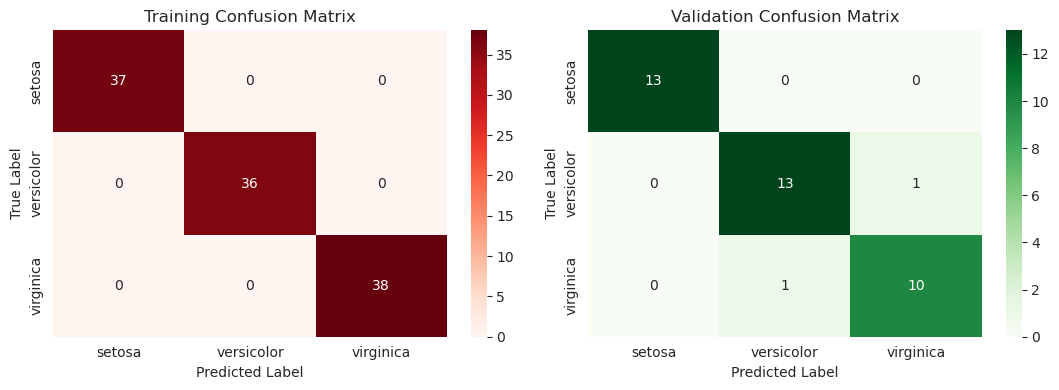



****************************************************************************************************
Performing Permutation Importance:
..................................................
The model's features are:

['petal_width', 'petal_length', 'sepal_width', 'sepal_length']
The most important features are:

	petal_width: 0.5736842105263158 +- 0.05102820902543504
	petal_length: 0.0578947368421052 +- 0.010526315789473672
	sepal_width: 0.0 +- 0.0
	sepal_length: -0.010526315789473717 +- 0.01289205127780624

****************************************************************************************************



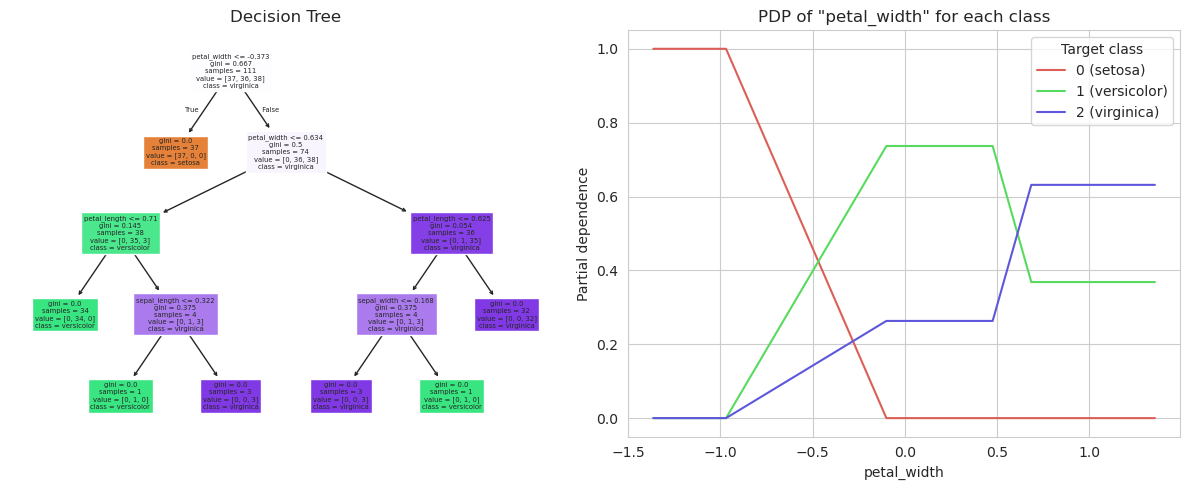

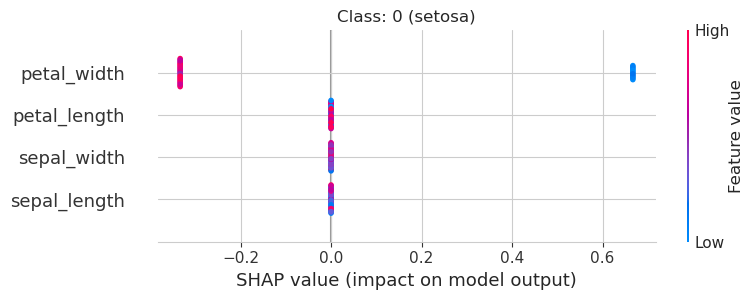

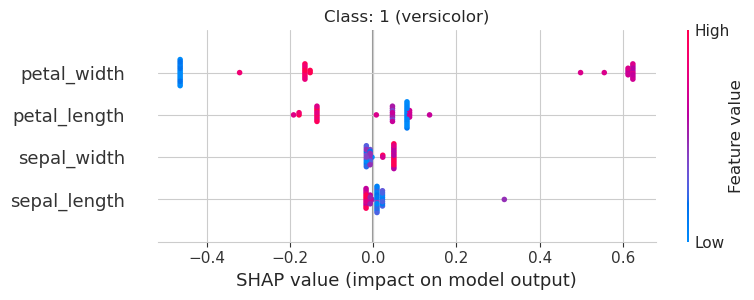

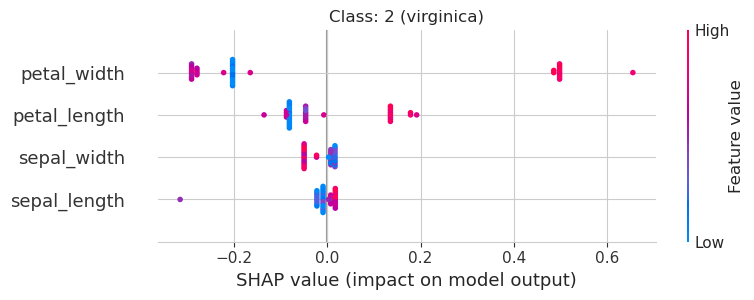




***************************************************************************
dtc_eng , 	CV: False 

***************************************************************************
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
We will evaluate model=dtc_eng with standard validation.
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 -> Fitting the model
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        37 |
| 1            |           1 |        1 |          1 |        36 |
| 2            |           1 |        1 |          1 |        38 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |  

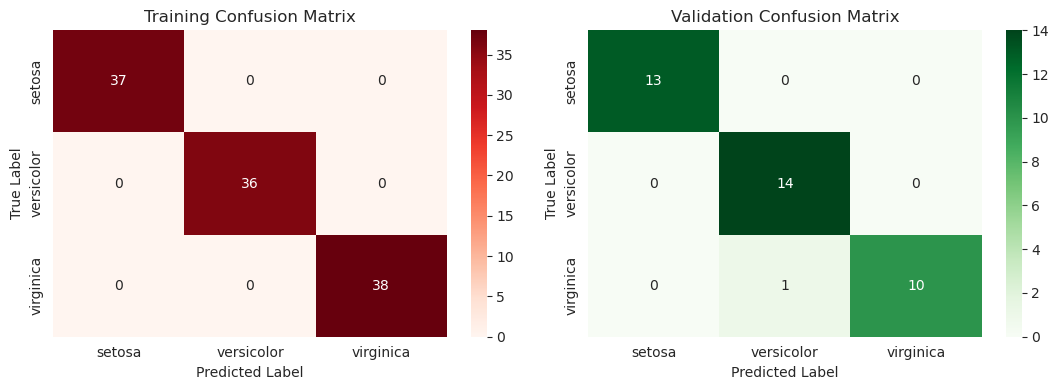






***************************************************************************
dtc_eng , 	CV: True 

***************************************************************************
We will evaluate dtc_eng with cross-validation.

 -> Creating instance of `RepeatedStratifiedKFold`
......Done!
 -> Creating the CV search
......Done!

 -> Fitting the model
......Done!
 -> CV Results:
		best f1_macro: 0.9574736447285467
		best params: {'model__max_depth': None, 'model__max_leaf_nodes': None, 'preprocessor__selector__corr_threshold': 0.7, 'preprocessor__selector__n_features': None}
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        37 |
| 1            |           1 |        

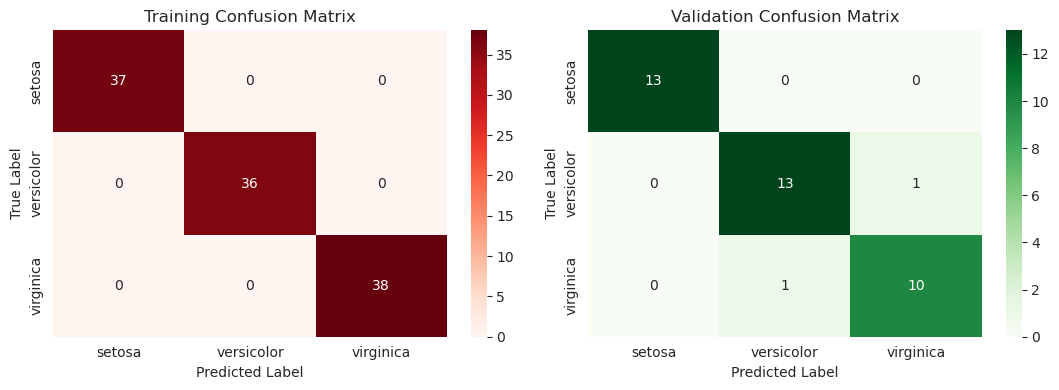



****************************************************************************************************
Performing Permutation Importance:
..................................................
The model's features are:

['petal_area', 'sepal_width', 'sepal_area']
The most important features are:

	petal_area: 0.6473684210526315 +- 0.06982367979695578
	sepal_width: 0.0 +- 0.0
	sepal_area: 0.0 +- 0.0

****************************************************************************************************



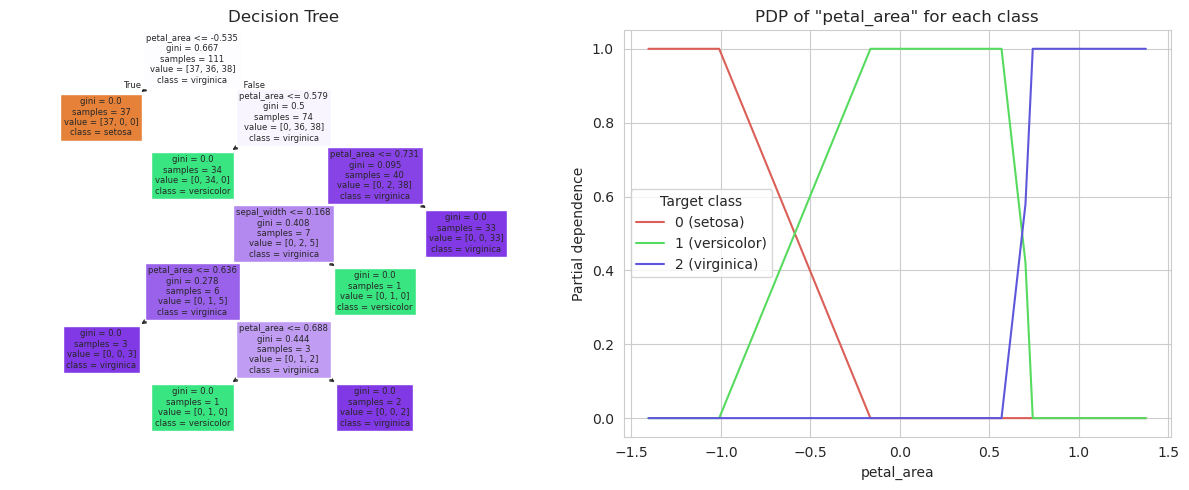

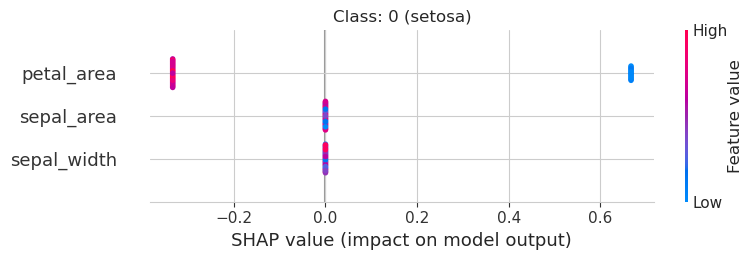

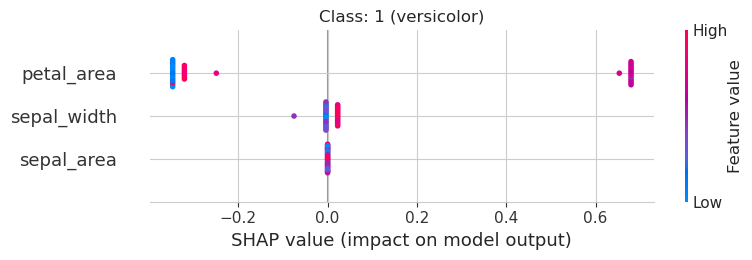

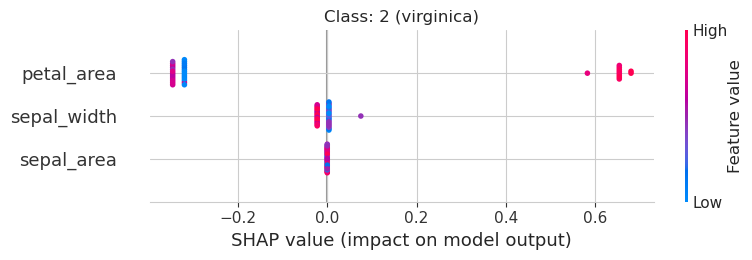

In [66]:
model = 'dtc'

for pp in ['raw', 'eng']:
    for cvQ in [False, True]:

        model_name = model+'_'+pp # full model name

        print("*"*75)
        print(model_name, ", \tCV:", cvQ, "\n")
        print("*"*75)
        
        model_evaluation(model_name, (X_train, X_val, y_train, y_val),
                         perform_cv_randomized=(cvQ, False),
                         n_splits=5, n_repeats=3,
                         verbose=True, plots=True)

        print("\n")

        if cvQ:
            explain_model(model_name, best_cv[model_name]['pipe'], (X_train, X_val, y_train, y_val), tree_idx=0, random_state=0)

        print("\n\n")

In [67]:
scorecard

,rfc_base_no_cv,dtc_raw_no_cv,dtc_raw_cv,dtc_eng_no_cv,dtc_eng_cv
Precision Train,1.000000,1.000000,1.000000,1.000000,1.000000
Precision Validation,0.945887,0.945887,0.945887,0.977778,0.945887
Recall Train,1.000000,1.000000,1.000000,1.000000,1.000000
Recall Validation,0.945887,0.945887,0.945887,0.969697,0.945887
Accuracy Train,1.000000,1.000000,1.000000,1.000000,1.000000
Accuracy Validation,0.947368,0.947368,0.947368,0.973684,0.947368
F1 Train,1.000000,1.000000,1.000000,1.000000,1.000000
F1 Validation,0.945887,0.945887,0.945887,0.972633,0.945887


### Model 2: `RandomForestClassifier`

In [68]:
model = 'rfc'

for pp in ['raw', 'eng']:

    model_name = model+'_'+pp # full model name

    preproc_pipe = final_preproc[pp] # preprocessing  pipeline

    pipe[model_name] = Pipeline(steps=[('preprocessor', preproc_pipe),
                                       ('model', RandomForestClassifier(random_state=0))])

    pipe[model_name+'_no_cv'] = Pipeline(steps=[('preprocessor', preproc_pipe),
                                                ('model', RandomForestClassifier(random_state=0))])

    # defining the hyperparameter grid
    if pp == 'raw':
        param_grid[model_name] = {'model__n_estimators': [100*i for i in range(1, 11)],
                                  'model__max_depth': [None] + [i for i in range(1, 6)]}
    else:
        param_grid[model_name] = {'model__n_estimators': [100*i for i in range(1, 11)],
                                  'model__max_depth': [None] + [i for i in range(1, 6)],
                                  'preprocessor__selector__n_features': [None, len(X.columns)],
                                  'preprocessor__selector__corr_threshold': [0.5, 0.7, 0.9]}

***************************************************************************
rfc_raw , 	CV: False 

***************************************************************************
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
We will evaluate model=rfc_raw with standard validation.
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 -> Fitting the model
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        37 |
| 1            |           1 |        1 |          1 |        36 |
| 2            |           1 |        1 |          1 |        38 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |     

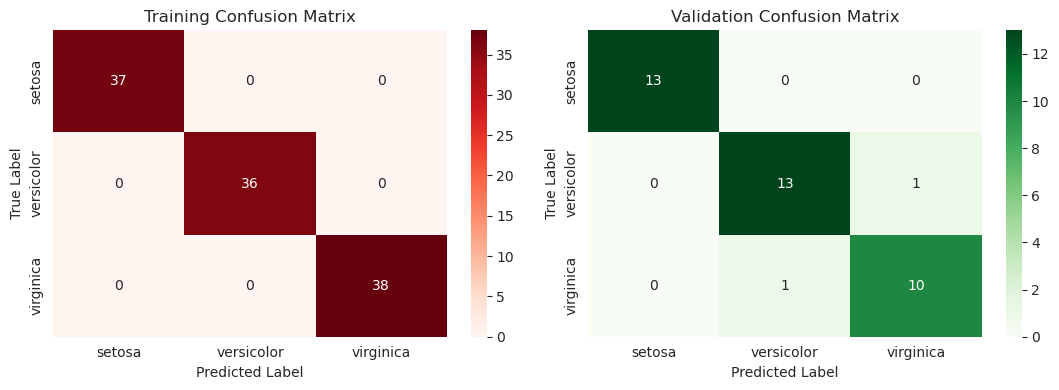






***************************************************************************
rfc_raw , 	CV: True 

***************************************************************************
We will evaluate rfc_raw with cross-validation.

 -> Creating instance of `RepeatedStratifiedKFold`
......Done!
 -> Creating the CV search
......Done!

 -> Fitting the model
......Done!
 -> CV Results:
		best f1_macro: 0.9540569960177805
		best params: {'model__max_depth': 3, 'model__n_estimators': 100}
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    0.971429 | 0.944444 |   0.957746 |  36        |
| 2            |    0.948718 | 0.973684 |   0.961039 |  38      

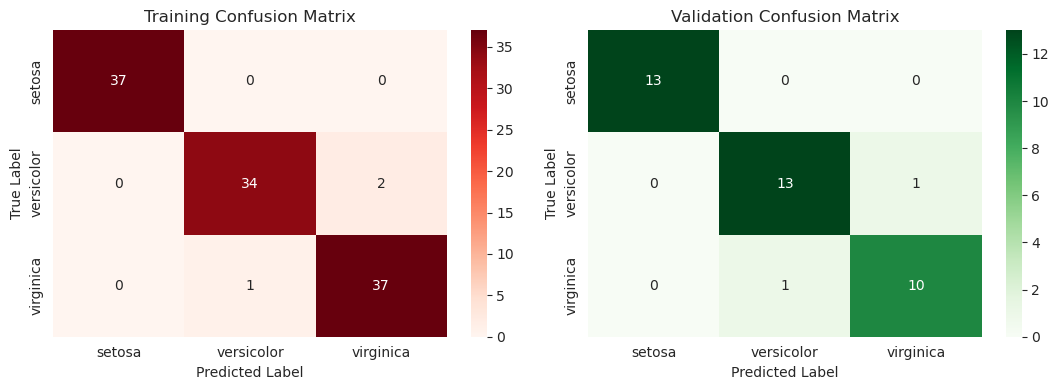



****************************************************************************************************
Performing Permutation Importance:
..................................................
The model's features are:

['petal_length', 'petal_width', 'sepal_width', 'sepal_length']
The most important features are:

	petal_length: 0.23157894736842097 +- 0.05102820902543506
	petal_width: 0.16315789473684206 +- 0.03491183989847788
	sepal_width: 0.0 +- 0.0
	sepal_length: -0.010526315789473717 +- 0.01289205127780624

****************************************************************************************************



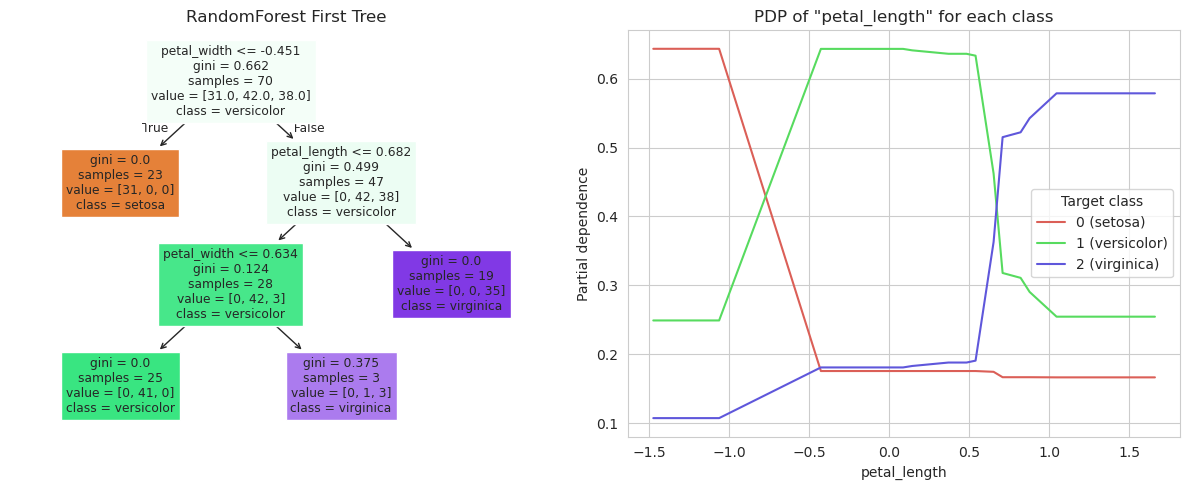

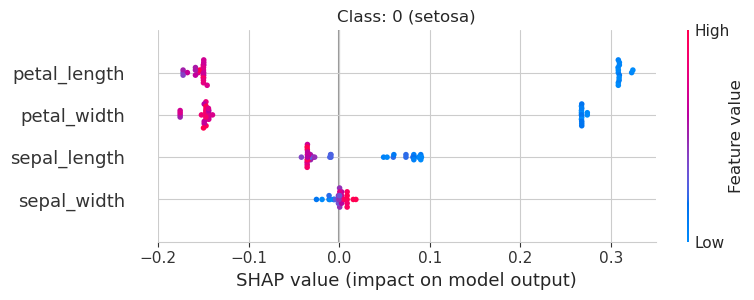

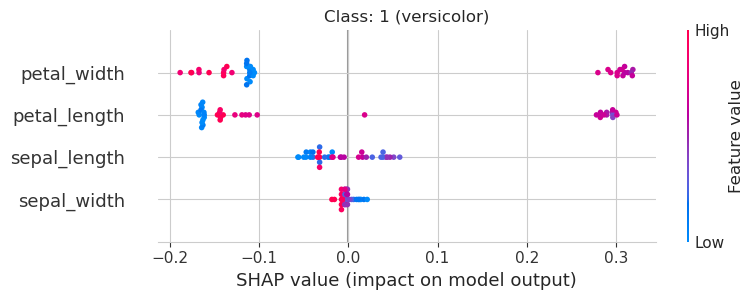

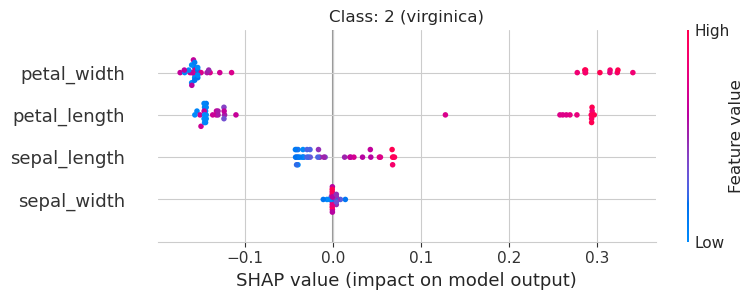




***************************************************************************
rfc_eng , 	CV: False 

***************************************************************************
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
We will evaluate model=rfc_eng with standard validation.
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 -> Fitting the model
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        37 |
| 1            |           1 |        1 |          1 |        36 |
| 2            |           1 |        1 |          1 |        38 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |  

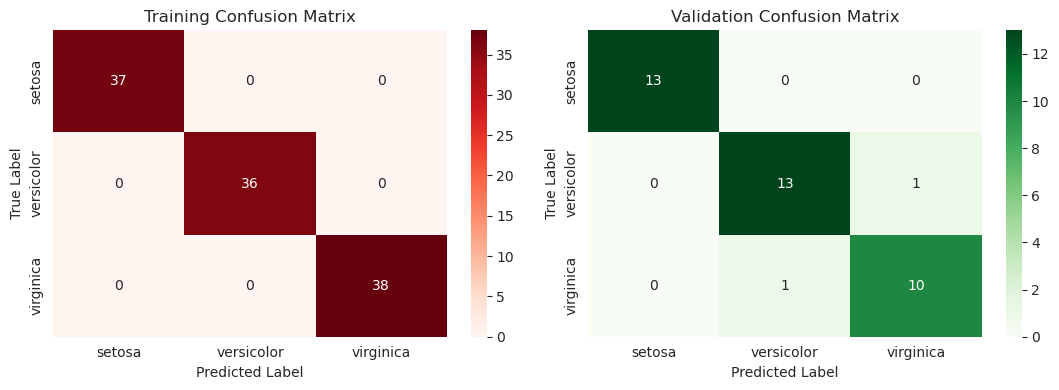






***************************************************************************
rfc_eng , 	CV: True 

***************************************************************************
We will evaluate rfc_eng with cross-validation.

 -> Creating instance of `RepeatedStratifiedKFold`
......Done!
 -> Creating the CV search
......Done!

 -> Fitting the model
......Done!
 -> CV Results:
		best f1_macro: 0.9603234057155627
		best params: {'model__max_depth': 1, 'model__n_estimators': 300, 'preprocessor__selector__corr_threshold': 0.9, 'preprocessor__selector__n_features': 4}
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    1        | 0.916667 |   

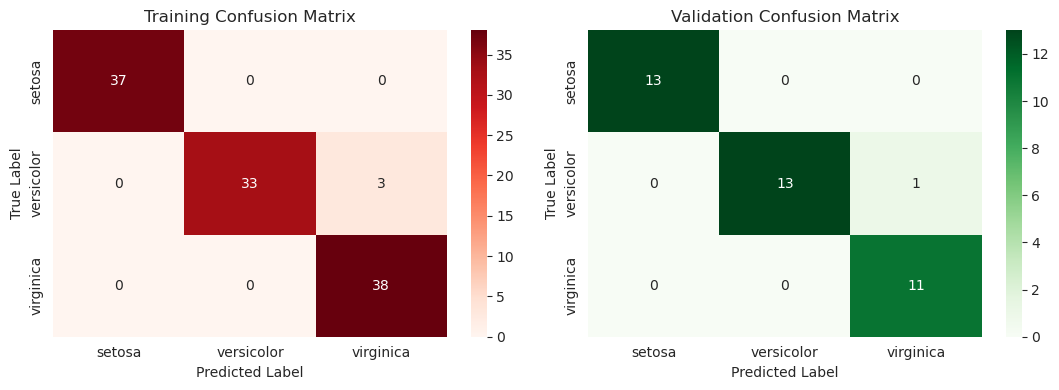



****************************************************************************************************
Performing Permutation Importance:
..................................................
The model's features are:

['petal_area', 'sepal_elongation', 'sepal_length', 'sepal_width']
The most important features are:

	petal_area: 0.4157894736842106 +- 0.030689220499185807
	sepal_elongation: 0.15263157894736845 +- 0.025784102555612413
	sepal_length: 0.015789473684210575 +- 0.01289205127780624
	sepal_width: 0.0 +- 0.0

****************************************************************************************************



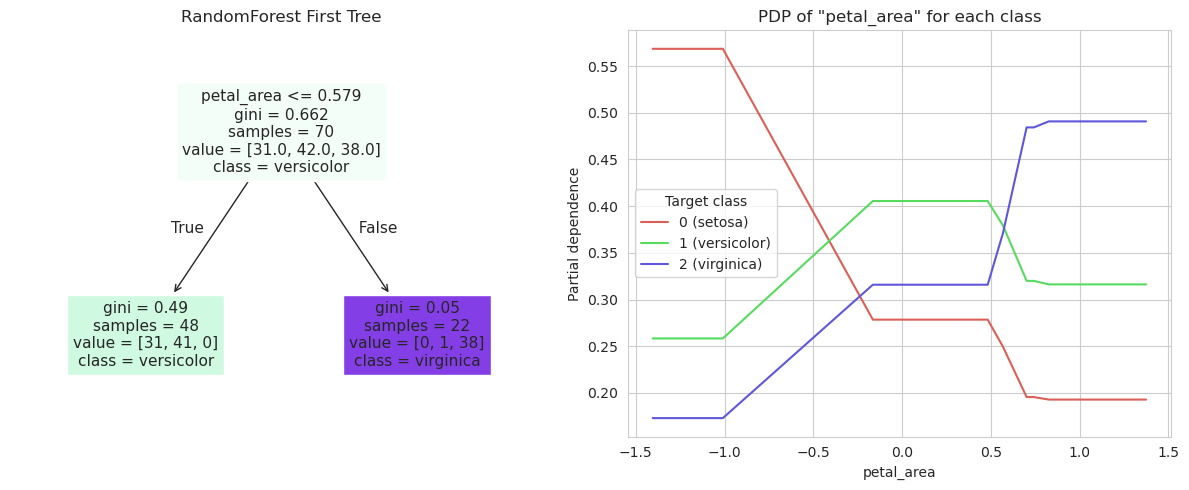

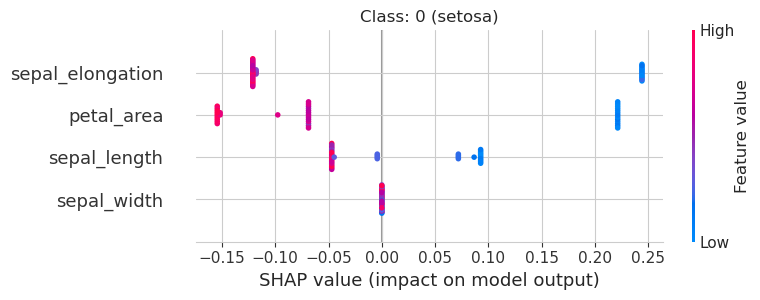

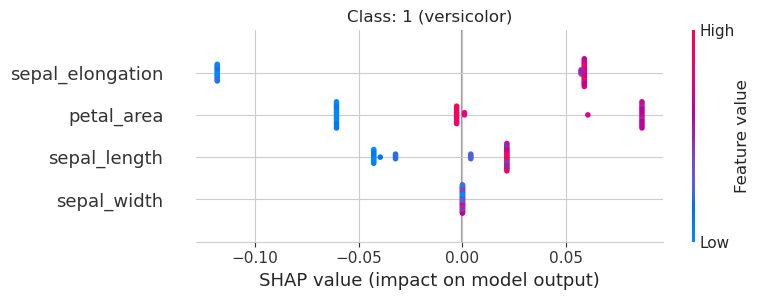

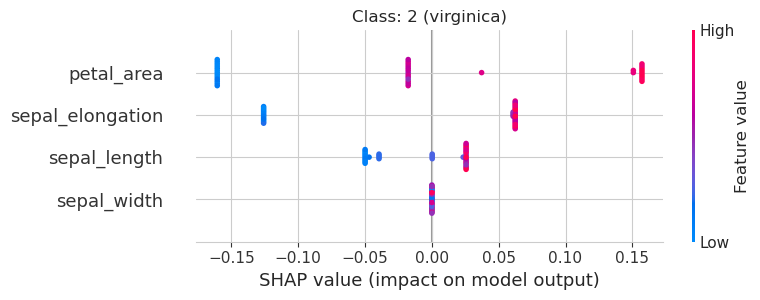

In [69]:
model = 'rfc'

for pp in ['raw', 'eng']:
    for cvQ in [False, True]:

        model_name = model+'_'+pp # full model name

        print("*"*75)
        print(model_name, ", \tCV:", cvQ, "\n")
        print("*"*75)
        
        model_evaluation(model_name, (X_train, X_val, y_train, y_val),
                         n_splits=5, n_repeats=3,
                         perform_cv_randomized=(cvQ, False),
                         verbose=True, plots=True)

        print("\n")

        if cvQ:
            explain_model(model_name, best_cv[model_name]['pipe'], (X_train, X_val, y_train, y_val), tree_idx=0, random_state=0)

        print("\n\n")

In [70]:
scorecard

,rfc_base_no_cv,dtc_raw_no_cv,dtc_raw_cv,dtc_eng_no_cv,dtc_eng_cv,rfc_raw_no_cv,rfc_raw_cv,rfc_eng_no_cv,rfc_eng_cv
Precision Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.973382,1.000000,0.975610
Precision Validation,0.945887,0.945887,0.945887,0.977778,0.945887,0.945887,0.945887,0.945887,0.972222
Recall Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972710,1.000000,0.972222
Recall Validation,0.945887,0.945887,0.945887,0.969697,0.945887,0.945887,0.945887,0.945887,0.976190
Accuracy Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972973,1.000000,0.972973
Accuracy Validation,0.947368,0.947368,0.947368,0.973684,0.947368,0.947368,0.947368,0.947368,0.973684
F1 Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972928,1.000000,0.972849
F1 Validation,0.945887,0.945887,0.945887,0.972633,0.945887,0.945887,0.945887,0.945887,0.973162


### Model 3: `XGBClassifier`

In [71]:
model = 'xgbc'

for pp in ['raw', 'eng']:

    model_name = model+'_'+pp # full model name

    preproc_pipe = final_preproc[pp] # preprocessing  pipeline

    pipe[model_name] = Pipeline(steps=[('preprocessor', preproc_pipe),
                                       ('model', XGBClassifier(random_state=0))])

    pipe[model_name+'_no_cv'] = Pipeline(steps=[('preprocessor', preproc_pipe),
                                                ('model', XGBClassifier(random_state=0))])

    # defining the hyperparameter grid
    if pp == 'raw':
        param_grid[model_name] = {'model__n_estimators': [100*i for i in range(1, 21)],
                                  'model__learning_rate': [0.01*i for i in range(1,5)]+[0.05*i for i in range(1,11)]}
    else:
        param_grid[model_name] = {'model__n_estimators': [100*i for i in range(1, 21)],
                                  'model__learning_rate': [0.01*i for i in range(1,5)]+[0.05*i for i in range(1,11)],
                                  'preprocessor__selector__n_features': [None, len(X.columns)],
                                  'preprocessor__selector__corr_threshold': [0.5, 0.7, 0.9]}

***************************************************************************
xgbc_raw , 	CV: False 

***************************************************************************
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
We will evaluate model=xgbc_raw with standard validation.
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 -> Fitting the model
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        37 |
| 1            |           1 |        1 |          1 |        36 |
| 2            |           1 |        1 |          1 |        38 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |   

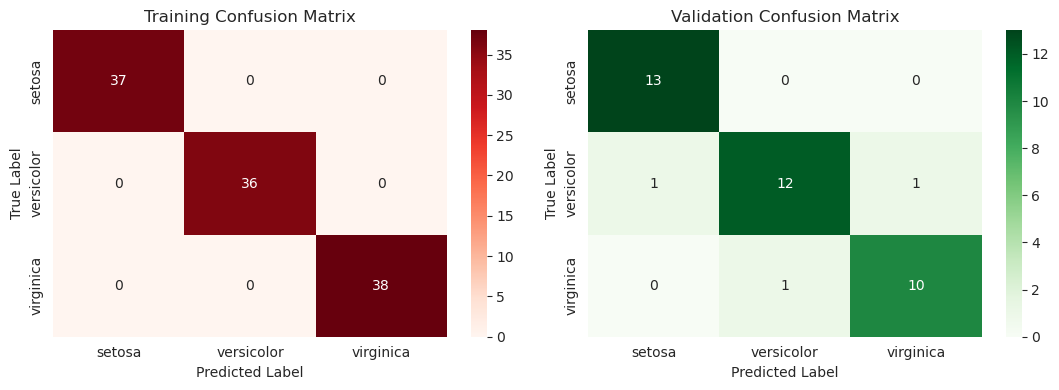






***************************************************************************
xgbc_raw , 	CV: True 

***************************************************************************
We will evaluate xgbc_raw with cross-validation.

 -> Creating instance of `RepeatedStratifiedKFold`
......Done!
 -> Creating the CV search
......Done!

 -> Fitting the model


/home/mbuenabad/anaconda3/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/mbuenabad/anaconda3/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoos

......Done!
 -> CV Results:
		best f1_macro: 0.9508469598665676
		best params: {'model__learning_rate': 0.01, 'model__n_estimators': 200}
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    1        | 0.944444 |   0.971429 |  36        |
| 2            |    0.95     | 1        |   0.974359 |  38        |
| accuracy     |    0.981982 | 0.981982 |   0.981982 |   0.981982 |
| macro avg    |    0.983333 | 0.981481 |   0.981929 | 111        |
| weighted avg |    0.982883 | 0.981982 |   0.981956 | 111        |


Classification Report: Validation
..................................................
|              |   precision |   recall |   f1-scor

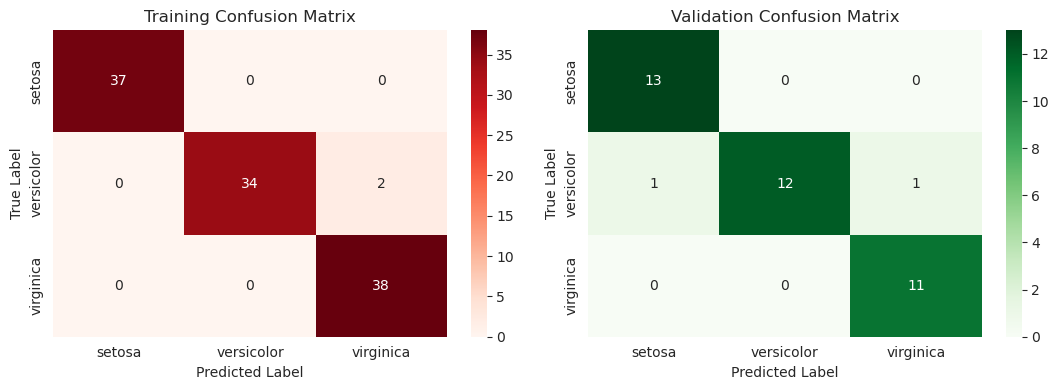



****************************************************************************************************
Performing Permutation Importance:
..................................................
The model's features are:

['petal_length', 'petal_width', 'sepal_length', 'sepal_width']
The most important features are:

	petal_length: 0.5526315789473684 +- 0.04403473823863554
	petal_width: 0.09999999999999994 +- 0.03867615383341861
	sepal_length: 0.0 +- 0.0
	sepal_width: 0.0 +- 0.0

****************************************************************************************************



/home/mbuenabad/anaconda3/lib/python3.11/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


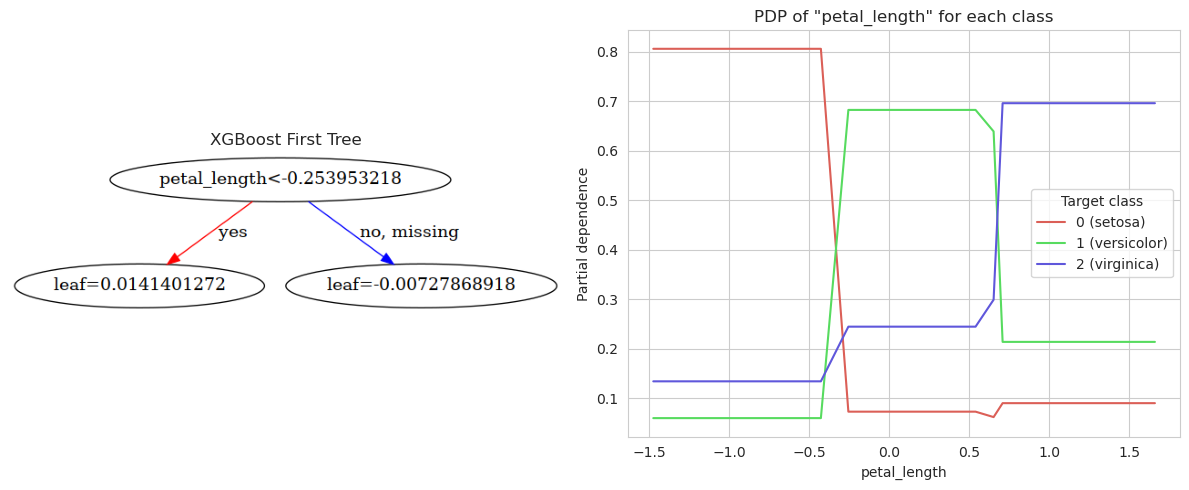

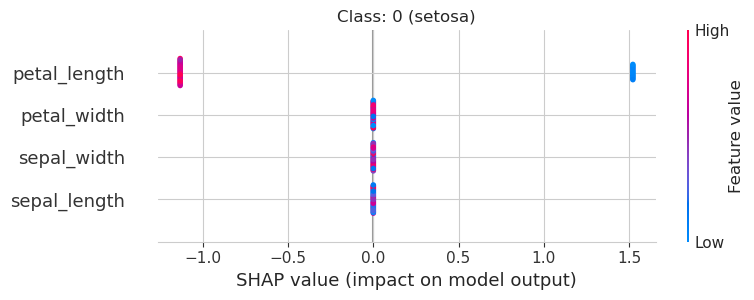

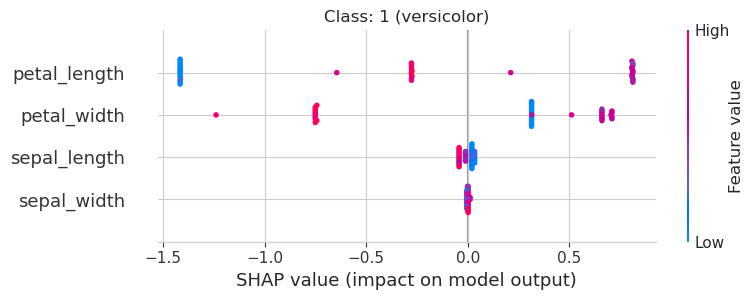

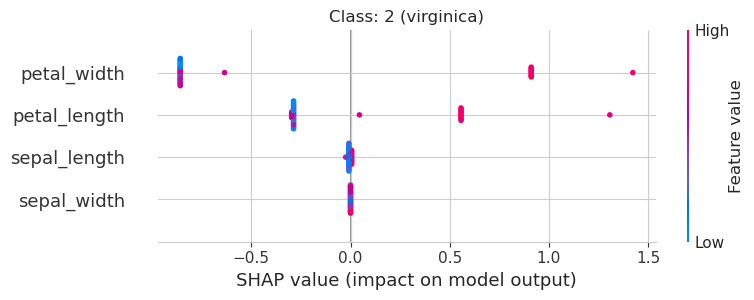




***************************************************************************
xgbc_eng , 	CV: False 

***************************************************************************
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
We will evaluate model=xgbc_eng with standard validation.
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 -> Fitting the model
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        37 |
| 1            |           1 |        1 |          1 |        36 |
| 2            |           1 |        1 |          1 |        38 |
| accuracy     |           1 |        1 |          1 |         1 |
| macro avg    |

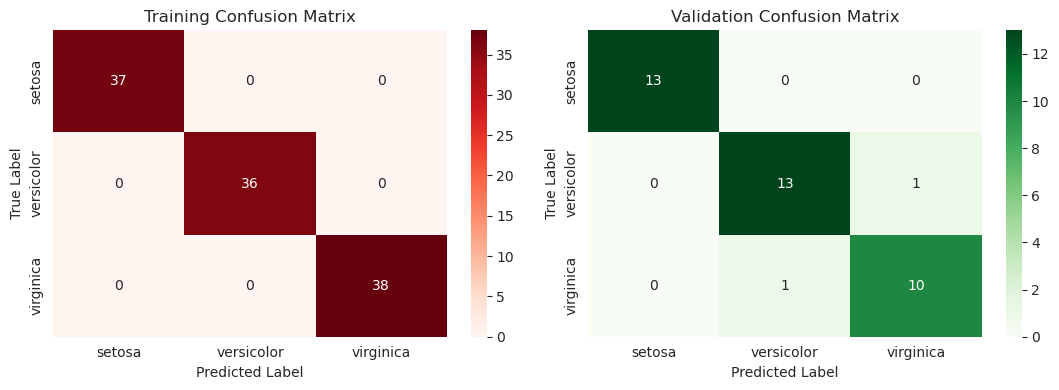






***************************************************************************
xgbc_eng , 	CV: True 

***************************************************************************
We will evaluate xgbc_eng with cross-validation.

 -> Creating instance of `RepeatedStratifiedKFold`
......Done!
 -> Creating the CV search
......Done!

 -> Fitting the model
......Done!
 -> CV Results:
		best f1_macro: 0.9535468090370053
		best params: {'model__learning_rate': 0.01, 'model__n_estimators': 1500, 'preprocessor__selector__corr_threshold': 0.5, 'preprocessor__selector__n_features': None}
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        37 |
| 1            |           1 |    

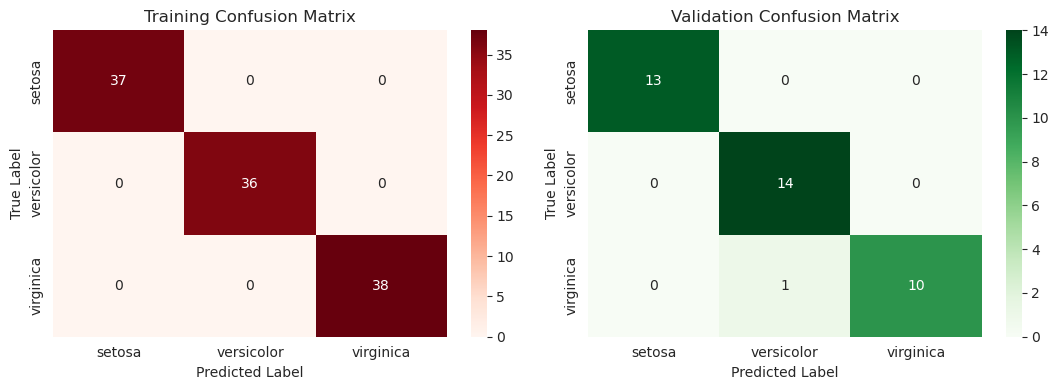



****************************************************************************************************
Performing Permutation Importance:
..................................................
The model's features are:

['petal_area', 'sepal_width']
The most important features are:

	petal_area: 0.6684210526315789 +- 0.06359497880839247
	sepal_width: 0.010526315789473717 +- 0.01289205127780624

****************************************************************************************************



/home/mbuenabad/anaconda3/lib/python3.11/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


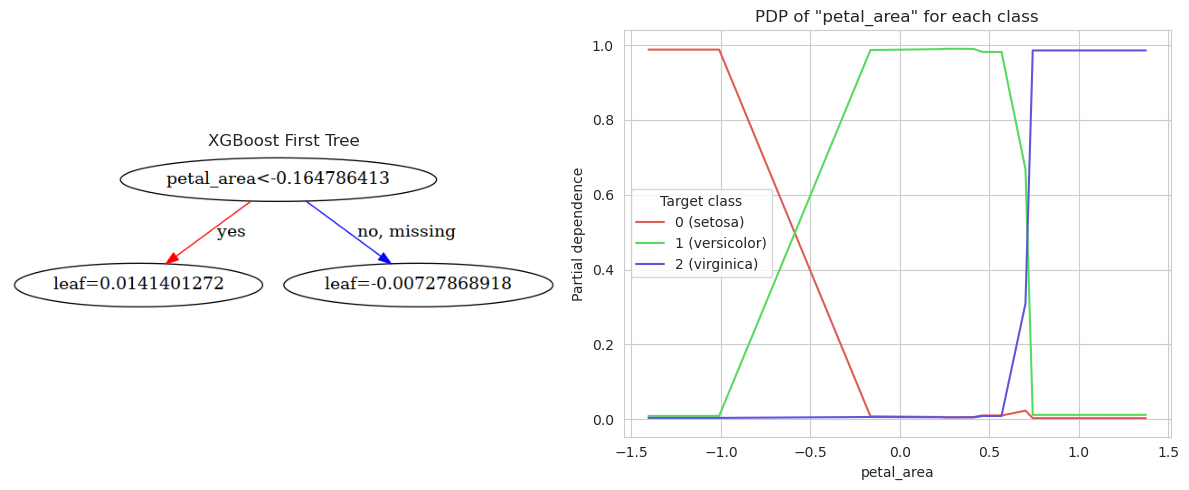

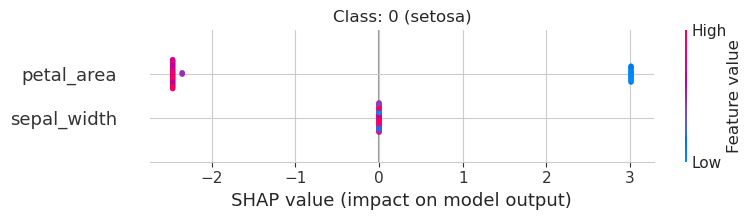

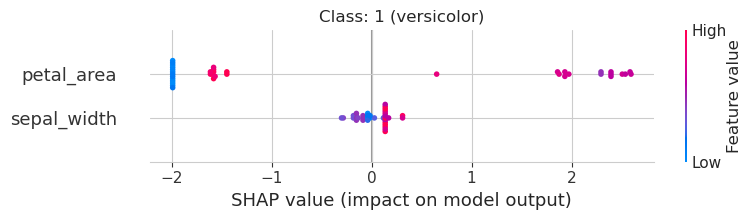

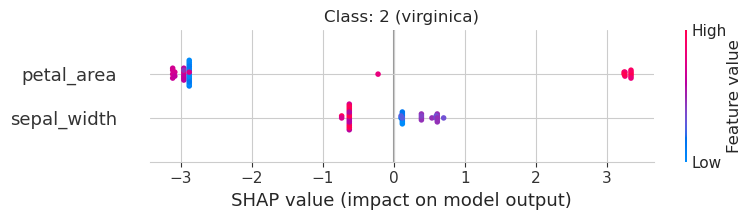

In [72]:
model = 'xgbc'

for pp in ['raw', 'eng']:
    for cvQ in [False, True]:

        model_name = model+'_'+pp # full model name

        print("*"*75)
        print(model_name, ", \tCV:", cvQ, "\n")
        print("*"*75)
        
        model_evaluation(model_name, (X_train, X_val, y_train, y_val),
                         n_splits=5, n_repeats=3,
                         perform_cv_randomized=(cvQ, False),
                         verbose=True, plots=True)

        print("\n")

        if cvQ:
            explain_model(model_name, best_cv[model_name]['pipe'], (X_train, X_val, y_train, y_val), tree_idx=0, random_state=0)

        print("\n\n")

In [73]:
scorecard

,rfc_base_no_cv,dtc_raw_no_cv,dtc_raw_cv,dtc_eng_no_cv,dtc_eng_cv,rfc_raw_no_cv,rfc_raw_cv,rfc_eng_no_cv,rfc_eng_cv,xgbc_raw_no_cv,xgbc_raw_cv,xgbc_eng_no_cv,xgbc_eng_cv
Precision Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.973382,1.000000,0.975610,1.000000,0.983333,1.000000,1.000000
Precision Validation,0.945887,0.945887,0.945887,0.977778,0.945887,0.945887,0.945887,0.945887,0.972222,0.920246,0.948413,0.945887,0.977778
Recall Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972710,1.000000,0.972222,1.000000,0.981481,1.000000,1.000000
Recall Validation,0.945887,0.945887,0.945887,0.969697,0.945887,0.945887,0.945887,0.945887,0.976190,0.922078,0.952381,0.945887,0.969697
Accuracy Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972973,1.000000,0.972973,1.000000,0.981982,1.000000,1.000000
Accuracy Validation,0.947368,0.947368,0.947368,0.973684,0.947368,0.947368,0.947368,0.947368,0.973684,0.921053,0.947368,0.947368,0.973684
F1 Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972928,1.000000,0.972849,1.000000,0.981929,1.000000,1.000000
F1 Validation,0.945887,0.945887,0.945887,0.972633,0.945887,0.945887,0.945887,0.945887,0.973162,0.920314,0.947521,0.945887,0.972633


### Model 4: `LogisticRegression`

In [74]:
model = 'logreg'

for pp in ['raw', 'eng']:

    model_name = model+'_'+pp # full model name

    preproc_pipe = final_preproc[pp] # preprocessing  pipeline

    pipe[model_name] = Pipeline(steps=[('preprocessor', preproc_pipe),
                                       ('model', LogisticRegression(fit_intercept=True, max_iter=10000, random_state=0))])

    pipe[model_name+'_no_cv'] = Pipeline(steps=[('preprocessor', preproc_pipe),
                                       ('model', LogisticRegression(fit_intercept=True, max_iter=10000, random_state=0))])

    # defining the hyperparameter grid
    if pp == 'raw':
        param_grid[model_name] = {'model__C': [0.5*i for i in range(1,21)],
                                  'model__solver': ['lbfgs', 'saga'],
                                  'model__penalty': ['l2', 'l1']}
    else:
        param_grid[model_name] = {'model__C': [0.5*i for i in range(1,21)],
                                  'model__solver': ['lbfgs', 'saga'],
                                  'model__penalty': ['l2', 'l1'],
                                  'preprocessor__selector__n_features': [None, len(X.columns)],
                                  'preprocessor__selector__corr_threshold': [0.5, 0.7, 0.9]}

***************************************************************************
logreg_raw , 	CV: False 

***************************************************************************
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
We will evaluate model=logreg_raw with standard validation.
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 -> Fitting the model
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    0.971429 | 0.944444 |   0.957746 |  36        |
| 2            |    0.948718 | 0.973684 |   0.961039 |  38        |
| accuracy     |    0.972973 | 0.972973 |   0.972973 |   0.972973 |
| macro a

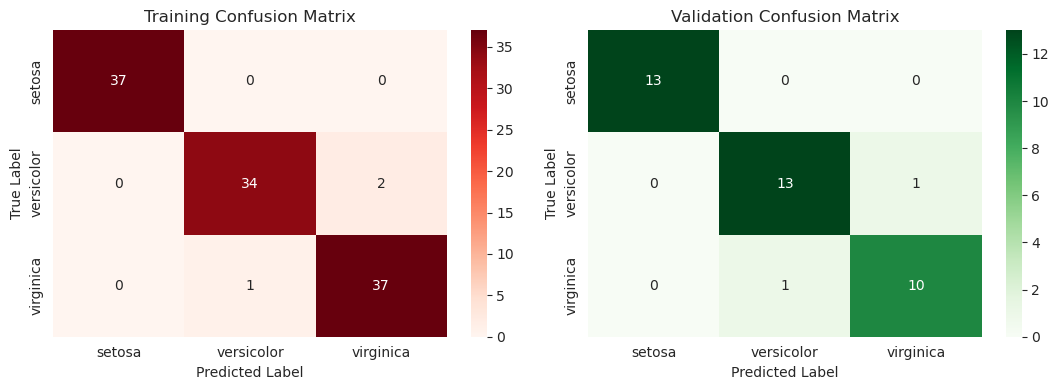






***************************************************************************
logreg_raw , 	CV: True 

***************************************************************************
We will evaluate logreg_raw with cross-validation.

 -> Creating instance of `RepeatedStratifiedKFold`
......Done!
 -> Creating the CV search
......Done!

 -> Fitting the model


/home/mbuenabad/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
300 fits failed out of a total of 1200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
300 fits failed with the following error:
Traceback (most recent call last):
  File "/home/mbuenabad/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/mbuenabad/anaconda3/lib/python3.11/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mbuenabad/anaconda3/lib/python3.11/site-packages/sklearn/pipeline

......Done!
 -> CV Results:
		best f1_macro: 0.9630259682220467
		best params: {'model__C': 2.0, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    0.971429 | 0.944444 |   0.957746 |  36        |
| 2            |    0.948718 | 0.973684 |   0.961039 |  38        |
| accuracy     |    0.972973 | 0.972973 |   0.972973 |   0.972973 |
| macro avg    |    0.973382 | 0.97271  |   0.972928 | 111        |
| weighted avg |    0.973178 | 0.972973 |   0.972958 | 111        |


Classification Report: Validation
..................................................
|              |   precision |   recall | 

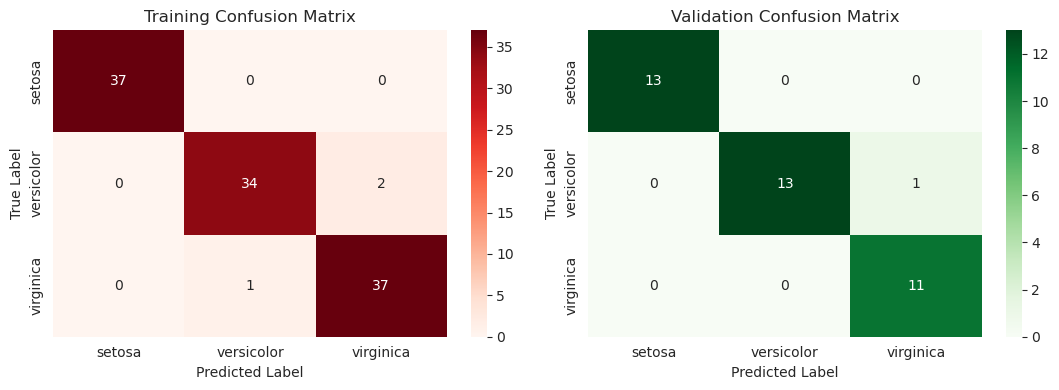



****************************************************************************************************
Performing Permutation Importance:
..................................................
The model's features are:

['petal_length', 'petal_width', 'sepal_width', 'sepal_length']
The most important features are:

	petal_length: 0.18947368421052638 +- 0.042105263157894736
	petal_width: 0.18947368421052635 +- 0.06531407182100452
	sepal_width: 0.15789473684210528 +- 0.0332871332649303
	sepal_length: 0.05263157894736845 +- 0.037216146378239334

****************************************************************************************************



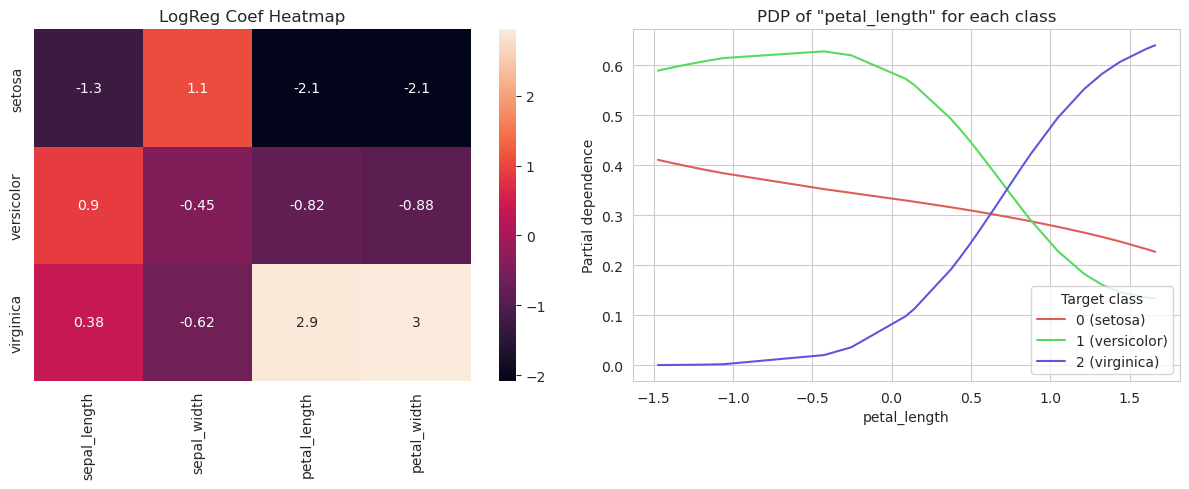

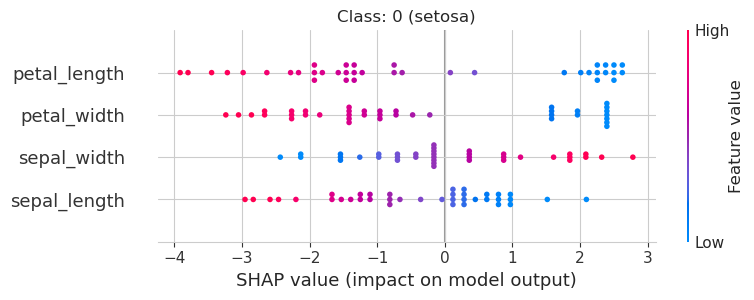

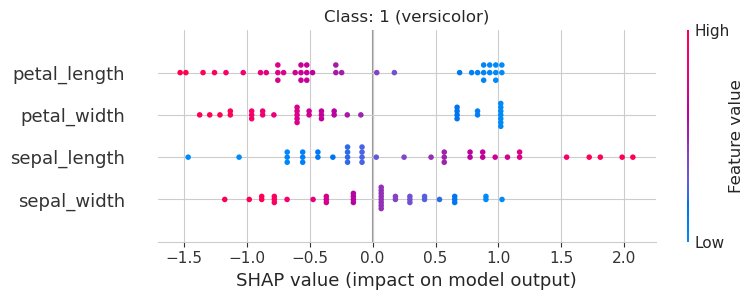

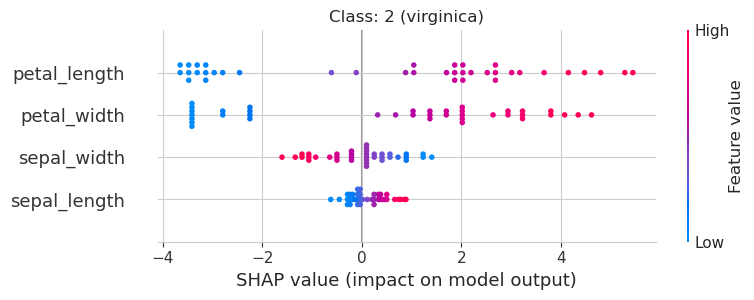




***************************************************************************
logreg_eng , 	CV: False 

***************************************************************************
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
We will evaluate model=logreg_eng with standard validation.
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 -> Fitting the model
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    0.918919 | 0.944444 |   0.931507 |  36        |
| 2            |    0.945946 | 0.921053 |   0.933333 |  38        |
| accuracy     |    0.954955 | 0.954955 |   0.954955 |   0.954955 |
| macr

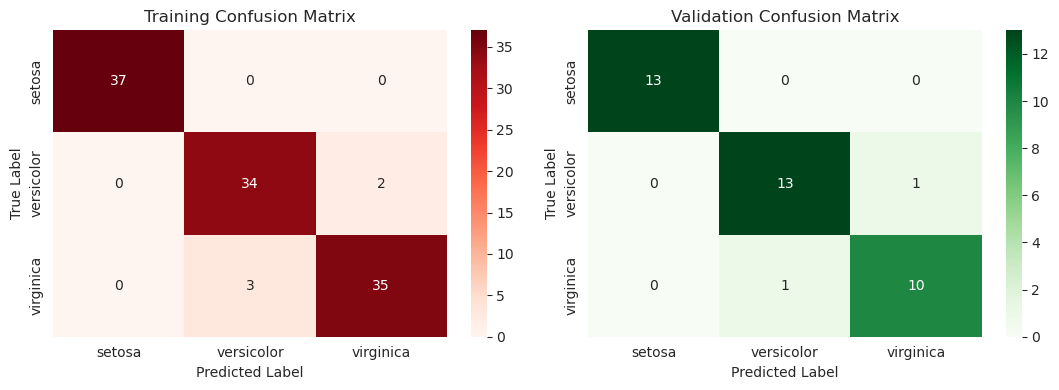






***************************************************************************
logreg_eng , 	CV: True 

***************************************************************************
We will evaluate logreg_eng with cross-validation.

 -> Creating instance of `RepeatedStratifiedKFold`
......Done!
 -> Creating the CV search
......Done!

 -> Fitting the model


/home/mbuenabad/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
1800 fits failed out of a total of 7200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1800 fits failed with the following error:
Traceback (most recent call last):
  File "/home/mbuenabad/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/mbuenabad/anaconda3/lib/python3.11/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mbuenabad/anaconda3/lib/python3.11/site-packages/sklearn/pipeli

......Done!
 -> CV Results:
		best f1_macro: 0.9510404047658951
		best params: {'model__C': 0.5, 'model__penalty': 'l1', 'model__solver': 'saga', 'preprocessor__selector__corr_threshold': 0.9, 'preprocessor__selector__n_features': None}
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    0.918919 | 0.944444 |   0.931507 |  36        |
| 2            |    0.945946 | 0.921053 |   0.933333 |  38        |
| accuracy     |    0.954955 | 0.954955 |   0.954955 |   0.954955 |
| macro avg    |    0.954955 | 0.955166 |   0.954947 | 111        |
| weighted avg |    0.955198 | 0.954955 |   0.954963 | 111        |


Classification Report: Validation
...

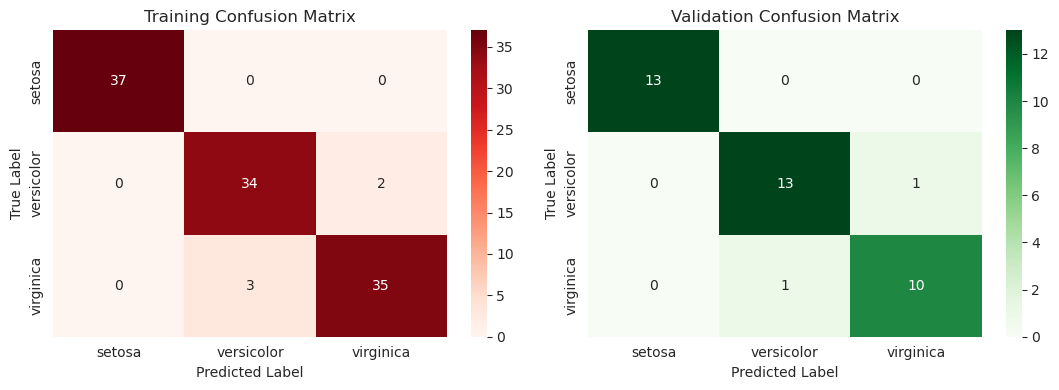



****************************************************************************************************
Performing Permutation Importance:
..................................................
The model's features are:

['petal_area', 'sepal_elongation', 'sepal_length', 'sepal_width', 'sepal_area']
The most important features are:

	petal_area: 0.6157894736842106 +- 0.05668594533825791
	sepal_elongation: 0.0578947368421052 +- 0.010526315789473672
	sepal_length: 0.0 +- 0.0
	sepal_width: 0.0 +- 0.0
	sepal_area: 0.0 +- 0.0

****************************************************************************************************



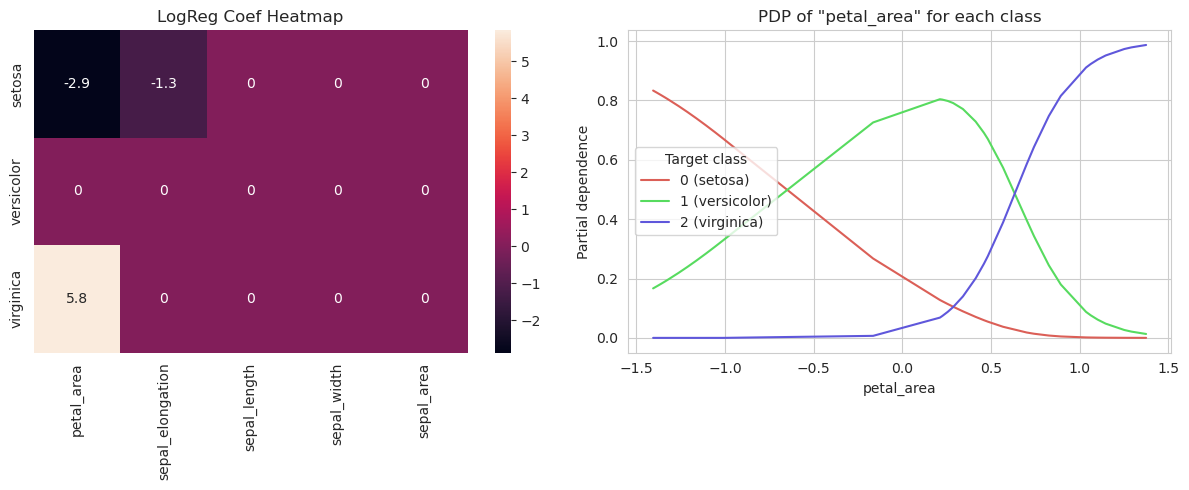

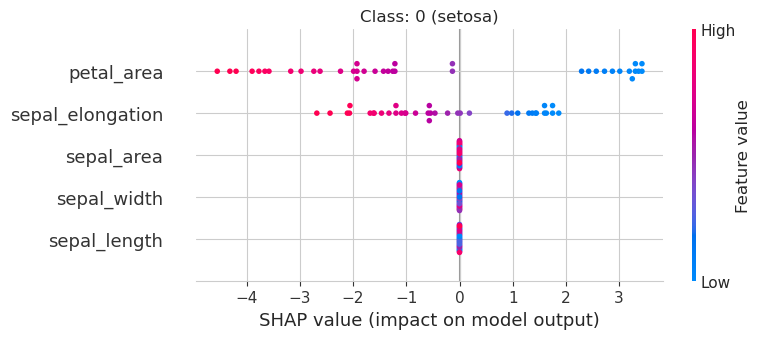

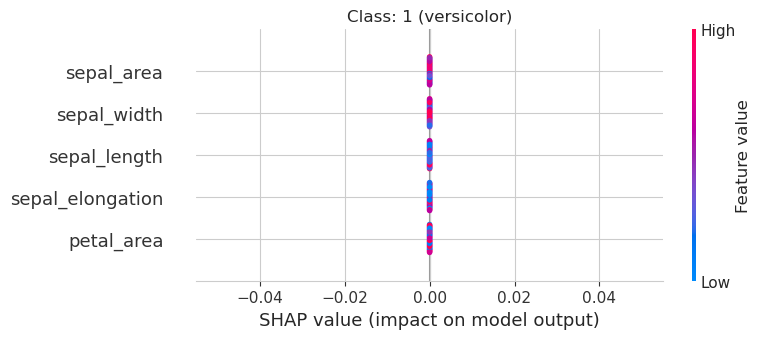

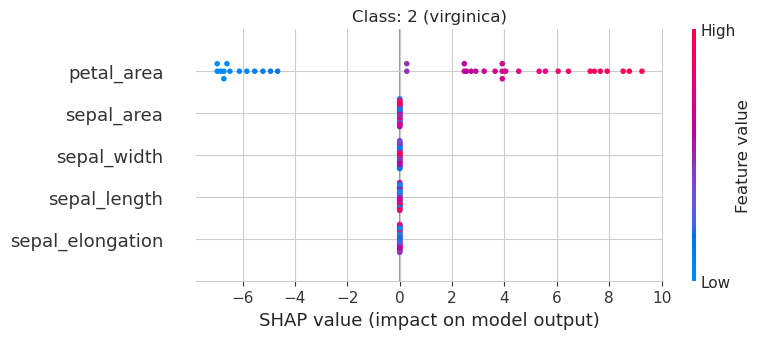

In [75]:
model = 'logreg'

for pp in ['raw', 'eng']:
    for cvQ in [False, True]:

        model_name = model+'_'+pp # full model name

        print("*"*75)
        print(model_name, ", \tCV:", cvQ, "\n")
        print("*"*75)
        
        model_evaluation(model_name, (X_train, X_val, y_train, y_val),
                         n_splits=5, n_repeats=3,
                         perform_cv_randomized=(cvQ, False),
                         verbose=True, plots=True)

        print("\n")

        if cvQ:
            explain_model(model_name, best_cv[model_name]['pipe'], (X_train, X_val, y_train, y_val), tree_idx=0, random_state=0)

        print("\n\n")

In [76]:
scorecard

,rfc_base_no_cv,dtc_raw_no_cv,dtc_raw_cv,dtc_eng_no_cv,dtc_eng_cv,rfc_raw_no_cv,rfc_raw_cv,rfc_eng_no_cv,rfc_eng_cv,xgbc_raw_no_cv,xgbc_raw_cv,xgbc_eng_no_cv,xgbc_eng_cv,logreg_raw_no_cv,logreg_raw_cv,logreg_eng_no_cv,logreg_eng_cv
Precision Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.973382,1.000000,0.975610,1.000000,0.983333,1.000000,1.000000,0.973382,0.973382,0.954955,0.954955
Precision Validation,0.945887,0.945887,0.945887,0.977778,0.945887,0.945887,0.945887,0.945887,0.972222,0.920246,0.948413,0.945887,0.977778,0.945887,0.972222,0.945887,0.945887
Recall Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972710,1.000000,0.972222,1.000000,0.981481,1.000000,1.000000,0.972710,0.972710,0.955166,0.955166
Recall Validation,0.945887,0.945887,0.945887,0.969697,0.945887,0.945887,0.945887,0.945887,0.976190,0.922078,0.952381,0.945887,0.969697,0.945887,0.976190,0.945887,0.945887
Accuracy Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972973,1.000000,0.972973,1.000000,0.981982,1.000000,1.000000,0.972973,0.972973,0.954955,0.954955
Accuracy Validation,0.947368,0.947368,0.947368,0.973684,0.947368,0.947368,0.947368,0.947368,0.973684,0.921053,0.947368,0.947368,0.973684,0.947368,0.973684,0.947368,0.947368
F1 Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972928,1.000000,0.972849,1.000000,0.981929,1.000000,1.000000,0.972928,0.972928,0.954947,0.954947
F1 Validation,0.945887,0.945887,0.945887,0.972633,0.945887,0.945887,0.945887,0.945887,0.973162,0.920314,0.947521,0.945887,0.972633,0.945887,0.973162,0.945887,0.945887


### Model 5: `SVC`

In [77]:
model = 'svc'

for pp in ['raw', 'eng']:

    model_name = model+'_'+pp # full model name

    preproc_pipe = final_preproc[pp] # preprocessing  pipeline

    pipe[model_name] = Pipeline(steps=[('preprocessor', preproc_pipe),
                                       ('model', SVC(random_state=0, probability=True))])

    pipe[model_name+'_no_cv'] = Pipeline(steps=[('preprocessor', preproc_pipe),
                                       ('model', SVC(random_state=0, probability=True))])

    # defining the hyperparameter grid
    if pp == 'raw':
        param_grid[model_name] = {'model__C': [0.5*i for i in range(1,21)],
                                  'model__kernel': ['rbf', 'linear'],
                                  'model__gamma': ['scale', 'auto']}
    else:
        param_grid[model_name] = {'model__C': [0.5*i for i in range(1,21)],
                                  'model__kernel': ['rbf', 'linear'],
                                  'model__gamma': ['scale', 'auto'],
                                  'preprocessor__selector__n_features': [None, len(X.columns)],
                                  'preprocessor__selector__corr_threshold': [0.5, 0.7, 0.9]}

***************************************************************************
svc_raw , 	CV: False 

***************************************************************************
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
We will evaluate model=svc_raw with standard validation.
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 -> Fitting the model
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    1        | 0.972222 |   0.985915 |  36        |
| 2            |    0.974359 | 1        |   0.987013 |  38        |
| accuracy     |    0.990991 | 0.990991 |   0.990991 |   0.990991 |
| macro avg    

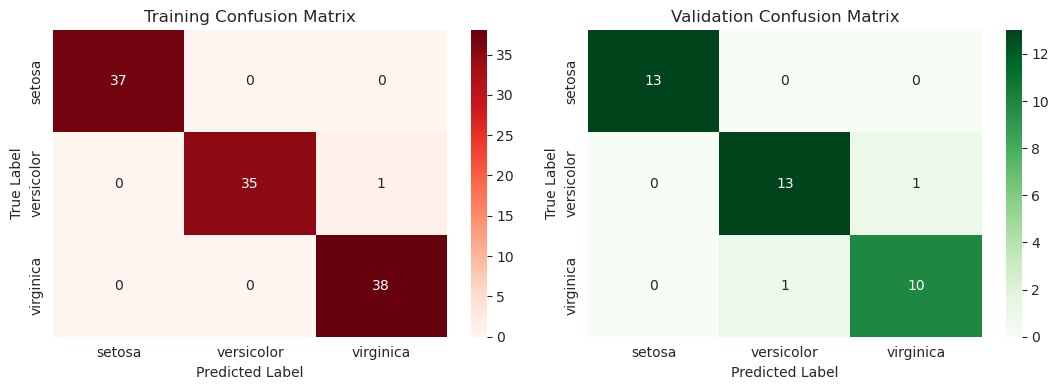






***************************************************************************
svc_raw , 	CV: True 

***************************************************************************
We will evaluate svc_raw with cross-validation.

 -> Creating instance of `RepeatedStratifiedKFold`
......Done!
 -> Creating the CV search
......Done!

 -> Fitting the model
......Done!
 -> CV Results:
		best f1_macro: 0.9756422227010463
		best params: {'model__C': 1.5, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    1        | 0.972222 |   0.985915 |  36        |
| 2            |    0.974359 | 1        |   0.987

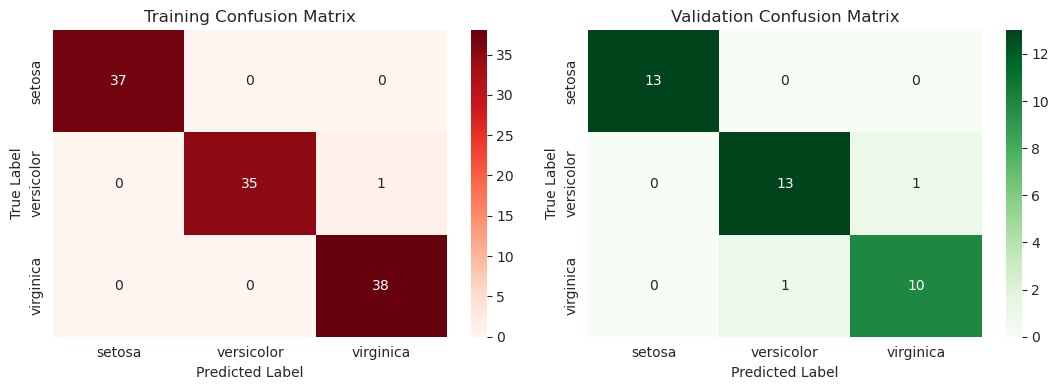



****************************************************************************************************
Performing Permutation Importance:
..................................................
The model's features are:

['petal_length', 'petal_width', 'sepal_width', 'sepal_length']
The most important features are:

	petal_length: 0.21578947368421045 +- 0.07330730672202168
	petal_width: 0.20526315789473676 +- 0.051028209025435034
	sepal_width: 0.03684210526315786 +- 0.021052631578947344
	sepal_length: 0.005263157894736836 +- 0.010526315789473672

****************************************************************************************************



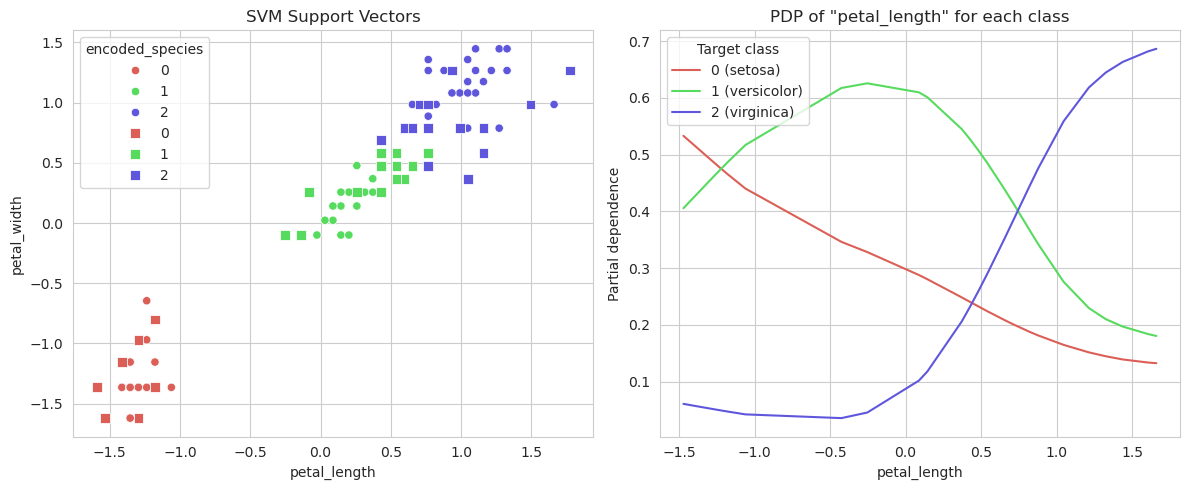

  0%|          | 0/38 [00:00<?, ?it/s]

num_full_subsets = 2
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([-0.33861492, -0.55502803, -1.42205788, -1.39073213])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([ 0.30501251, -0.1981756 , -0.51803468, -0.97813388])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([-0.07995222,  0.40152209,  1.10569756,  1.55645863])
num_full_subsets = 2
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([-0.45809734, -1.19948521, -1.46969266, -1.4013964 ])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([0.3488666 , 0.46210721, 1.50406232, 1.39951799])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([-0.22171353,  0.2480427 , -1.11494057, -1.02973911])
num_full_subsets = 2
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelW

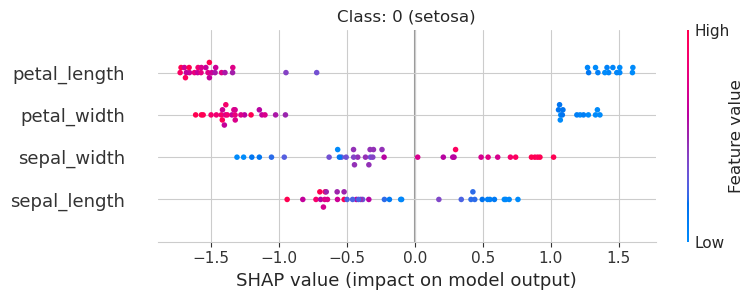

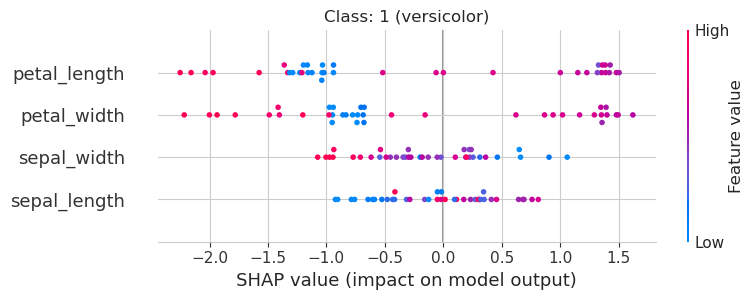

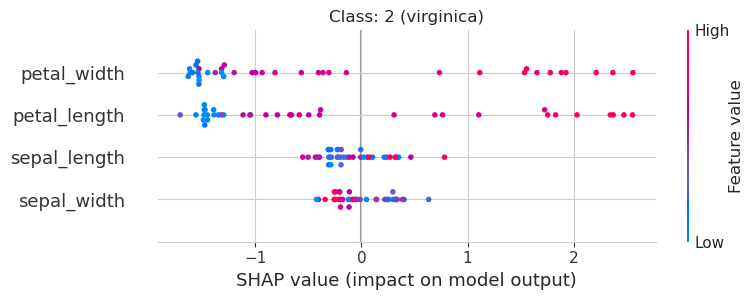




***************************************************************************
svc_eng , 	CV: False 

***************************************************************************
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
We will evaluate model=svc_eng with standard validation.
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 -> Fitting the model
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    0.918919 | 0.944444 |   0.931507 |  36        |
| 2            |    0.945946 | 0.921053 |   0.933333 |  38        |
| accuracy     |    0.954955 | 0.954955 |   0.954955 |   0.954955 |
| macro avg 

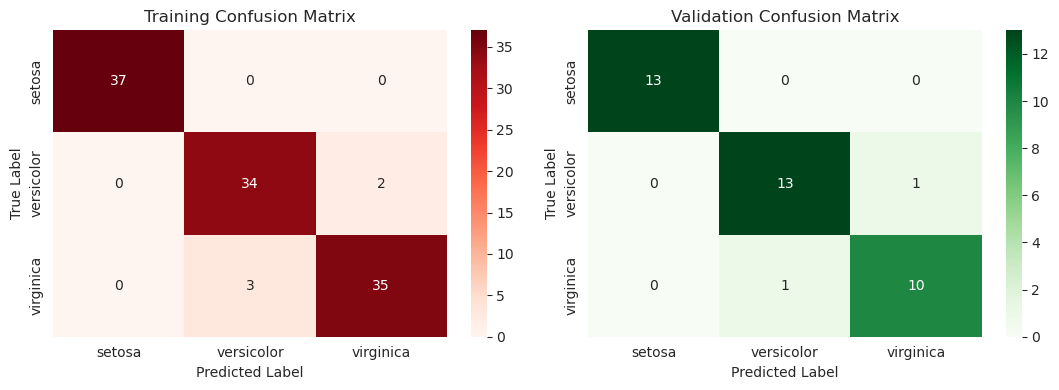






***************************************************************************
svc_eng , 	CV: True 

***************************************************************************
We will evaluate svc_eng with cross-validation.

 -> Creating instance of `RepeatedStratifiedKFold`
......Done!
 -> Creating the CV search
......Done!

 -> Fitting the model
......Done!
 -> CV Results:
		best f1_macro: 0.9726629797218034
		best params: {'model__C': 1.5, 'model__gamma': 'scale', 'model__kernel': 'rbf', 'preprocessor__selector__corr_threshold': 0.9, 'preprocessor__selector__n_features': 4}
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    1        

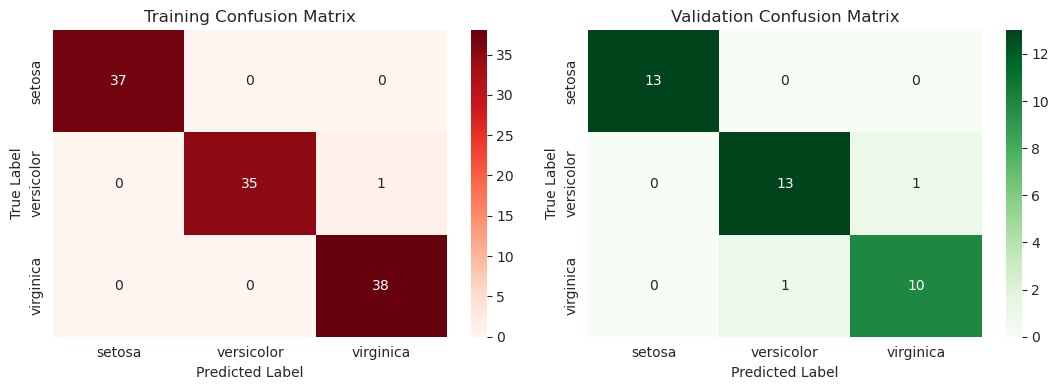



****************************************************************************************************
Performing Permutation Importance:
..................................................
The model's features are:

['petal_area', 'sepal_elongation', 'sepal_length', 'sepal_width']
The most important features are:

	petal_area: 0.4368421052631578 +- 0.04880851839734584
	sepal_elongation: 0.04210526315789469 +- 0.02683694480838305
	sepal_length: 0.01578947368421051 +- 0.021052631578947344
	sepal_width: 0.005263157894736814 +- 0.019692933614599707

****************************************************************************************************



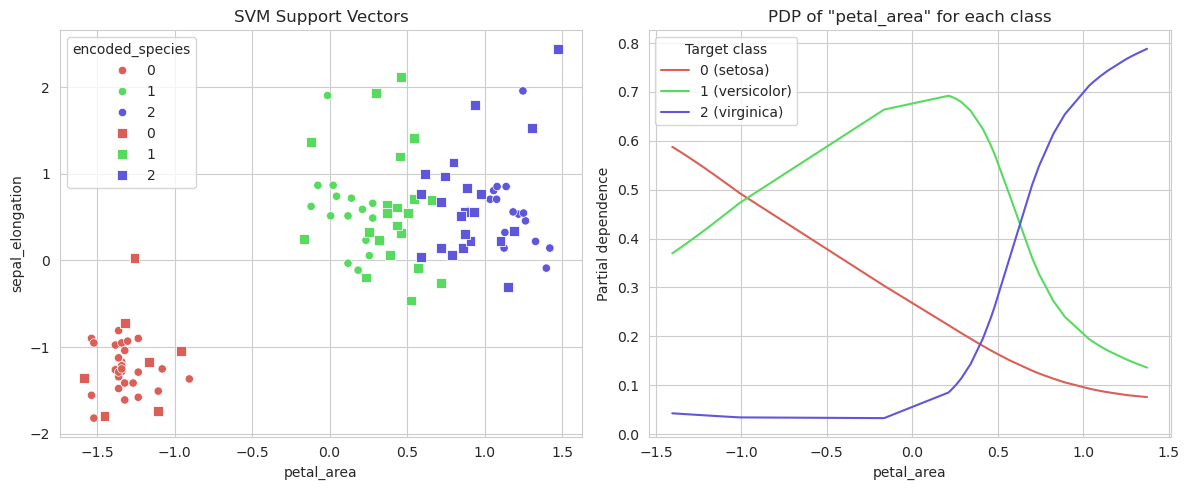

  0%|          | 0/38 [00:00<?, ?it/s]

num_full_subsets = 2
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([-1.74442564, -0.90809026, -0.49168644, -0.46912552])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([-1.28193678,  0.08578636,  0.04032754, -0.22666496])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([1.99252892, 0.37402197, 0.20658034, 0.38103175])
num_full_subsets = 2
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([-1.92896639, -1.12327807, -0.46087888, -0.82917272])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([ 1.93374472,  0.58023926,  0.29117741, -0.02601411])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([-1.41647632, -0.0585117 , -0.14582237,  0.50665532])
num_full_subsets = 2
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelW

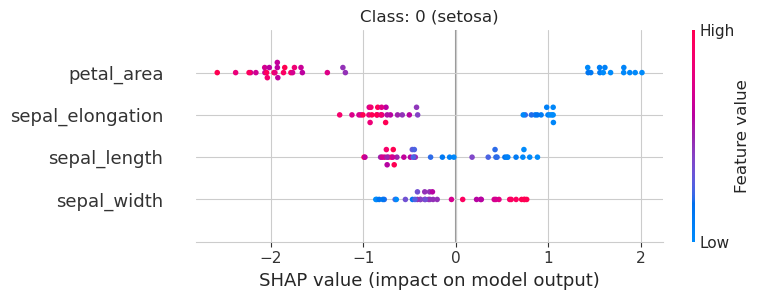

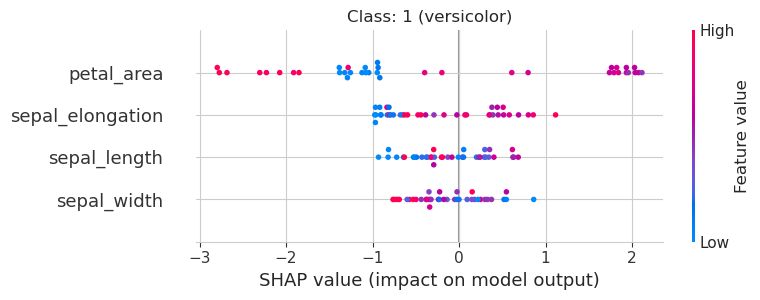

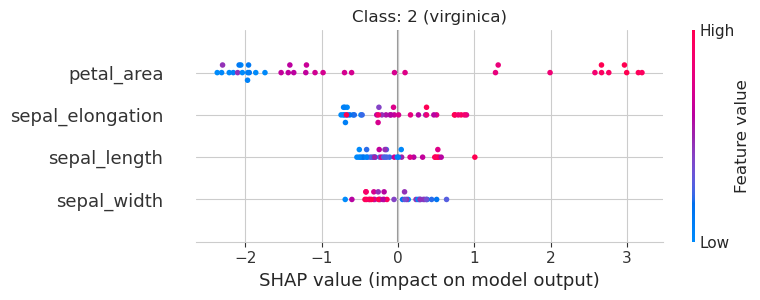

In [78]:
model = 'svc'

for pp in ['raw', 'eng']:
    for cvQ in [False, True]:

        model_name = model+'_'+pp # full model name

        print("*"*75)
        print(model_name, ", \tCV:", cvQ, "\n")
        print("*"*75)
        
        model_evaluation(model_name, (X_train, X_val, y_train, y_val),
                         n_splits=5, n_repeats=3,
                         perform_cv_randomized=(cvQ, False),
                         verbose=True, plots=True)

        print("\n")

        if cvQ:
            explain_model(model_name, best_cv[model_name]['pipe'], (X_train, X_val, y_train, y_val), tree_idx=0, random_state=0)

        print("\n\n")

In [79]:
scorecard

,rfc_base_no_cv,dtc_raw_no_cv,dtc_raw_cv,dtc_eng_no_cv,dtc_eng_cv,rfc_raw_no_cv,rfc_raw_cv,rfc_eng_no_cv,rfc_eng_cv,xgbc_raw_no_cv,...,xgbc_eng_no_cv,xgbc_eng_cv,logreg_raw_no_cv,logreg_raw_cv,logreg_eng_no_cv,logreg_eng_cv,svc_raw_no_cv,svc_raw_cv,svc_eng_no_cv,svc_eng_cv
Precision Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.973382,1.000000,0.975610,1.000000,...,1.000000,1.000000,0.973382,0.973382,0.954955,0.954955,0.991453,0.991453,0.954955,0.991453
Precision Validation,0.945887,0.945887,0.945887,0.977778,0.945887,0.945887,0.945887,0.945887,0.972222,0.920246,...,0.945887,0.977778,0.945887,0.972222,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887
Recall Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972710,1.000000,0.972222,1.000000,...,1.000000,1.000000,0.972710,0.972710,0.955166,0.955166,0.990741,0.990741,0.955166,0.990741
Recall Validation,0.945887,0.945887,0.945887,0.969697,0.945887,0.945887,0.945887,0.945887,0.976190,0.922078,...,0.945887,0.969697,0.945887,0.976190,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887
Accuracy Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972973,1.000000,0.972973,1.000000,...,1.000000,1.000000,0.972973,0.972973,0.954955,0.954955,0.990991,0.990991,0.954955,0.990991
Accuracy Validation,0.947368,0.947368,0.947368,0.973684,0.947368,0.947368,0.947368,0.947368,0.973684,0.921053,...,0.947368,0.973684,0.947368,0.973684,0.947368,0.947368,0.947368,0.947368,0.947368,0.947368
F1 Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972928,1.000000,0.972849,1.000000,...,1.000000,1.000000,0.972928,0.972928,0.954947,0.954947,0.990976,0.990976,0.954947,0.990976
F1 Validation,0.945887,0.945887,0.945887,0.972633,0.945887,0.945887,0.945887,0.945887,0.973162,0.920314,...,0.945887,0.972633,0.945887,0.973162,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887


### Model 6: `KNeighborsClassifier`

In [80]:
model = 'knn'

for pp in ['raw', 'eng']:

    model_name = model+'_'+pp # full model name

    preproc_pipe = final_preproc[pp] # preprocessing  pipeline

    pipe[model_name] = Pipeline(steps=[('preprocessor', preproc_pipe),
                                       ('model', KNeighborsClassifier())])

    pipe[model_name+'_no_cv'] = Pipeline(steps=[('preprocessor', preproc_pipe),
                                       ('model', KNeighborsClassifier())])

    # defining the hyperparameter grid
    if pp == 'raw':
        param_grid[model_name] = {'model__n_neighbors': list(range(3, 11)),
                                  'model__weights': ['uniform', 'distance'],
                                  'model__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                                  'model__leaf_size': [5*i for i in range(1, 4)],
                                  'model__p': [1, 2]}
    else:
        param_grid[model_name] = {'model__n_neighbors': list(range(3, 11)),
                                  'model__weights': ['uniform', 'distance'],
                                  'model__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                                  'model__leaf_size': [5*i for i in range(1, 4)],
                                  'model__p': [1, 2],
                                  'preprocessor__selector__n_features': [None, len(X.columns)],
                                  'preprocessor__selector__corr_threshold': [0.5, 0.7, 0.9]}

***************************************************************************
knn_raw , 	CV: False 

***************************************************************************
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
We will evaluate model=knn_raw with standard validation.
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 -> Fitting the model
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    0.921053 | 0.972222 |   0.945946 |  36        |
| 2            |    0.972222 | 0.921053 |   0.945946 |  38        |
| accuracy     |    0.963964 | 0.963964 |   0.963964 |   0.963964 |
| macro avg    

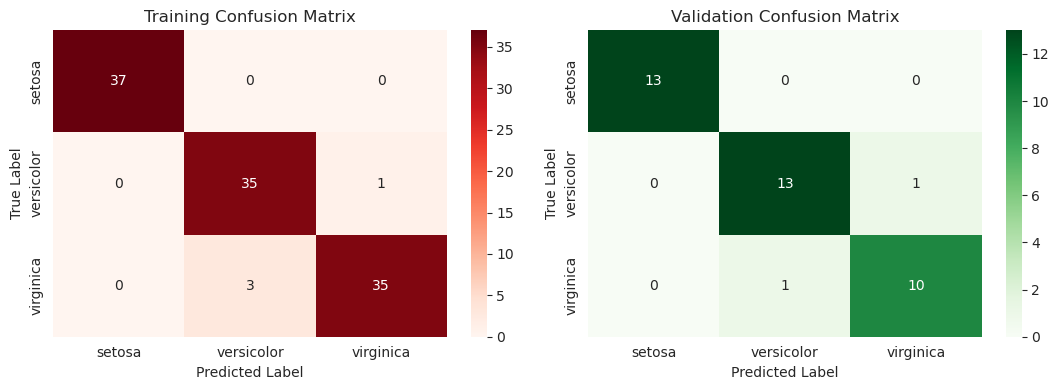






***************************************************************************
knn_raw , 	CV: True 

***************************************************************************
We will evaluate knn_raw with cross-validation.

 -> Creating instance of `RepeatedStratifiedKFold`
......Done!
 -> Creating the CV search
......Done!

 -> Fitting the model
......Done!
 -> CV Results:
		best f1_macro: 0.9664901402156306
		best params: {'model__algorithm': 'auto', 'model__leaf_size': 5, 'model__n_neighbors': 3, 'model__p': 2, 'model__weights': 'distance'}
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| 0            |           1 |        1 |          1 |        37 |
| 1            |           1 |        1 |          1 |        36 

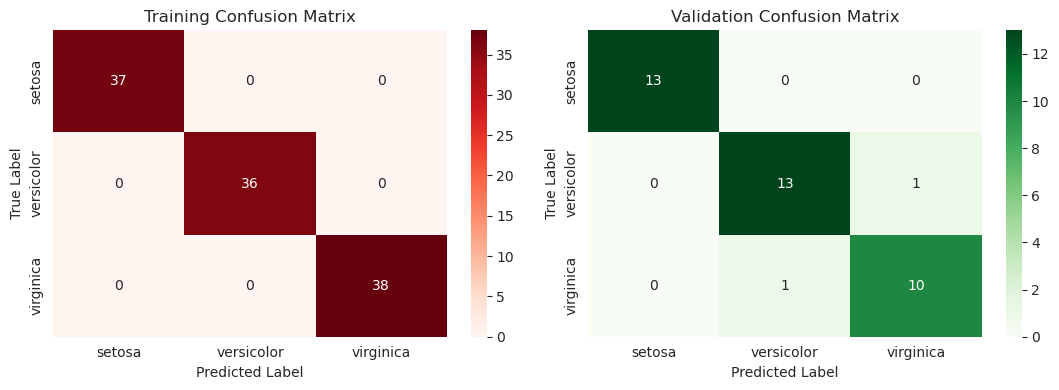



****************************************************************************************************
Performing Permutation Importance:
..................................................
The model's features are:

['petal_length', 'petal_width', 'sepal_width', 'sepal_length']
The most important features are:

	petal_length: 0.22631578947368416 +- 0.0613784409983716
	petal_width: 0.17368421052631575 +- 0.048808518397345804
	sepal_width: 0.08947368421052629 +- 0.021052631578947396
	sepal_length: 0.01578947368421051 +- 0.021052631578947344

****************************************************************************************************



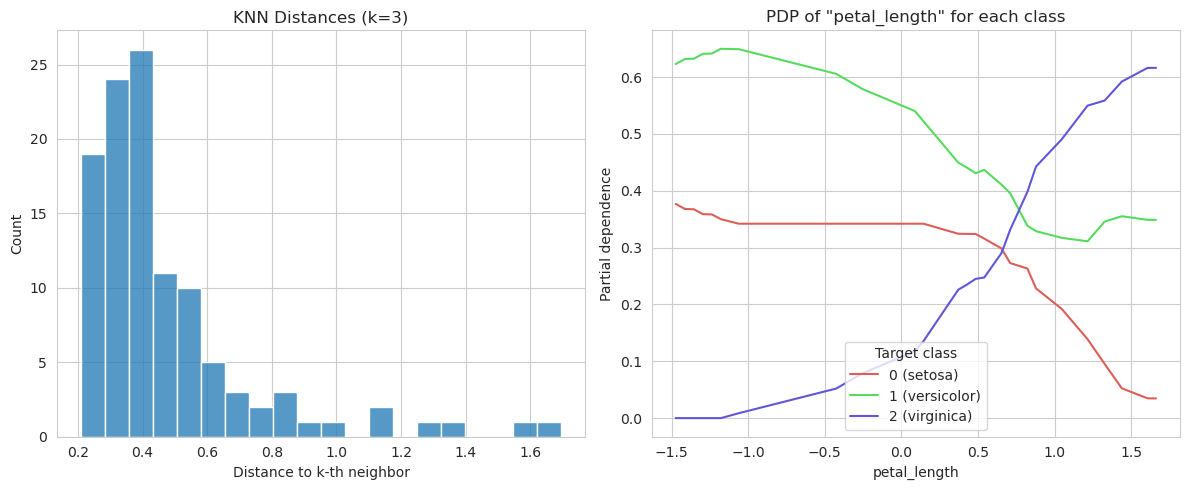

  0%|          | 0/38 [00:00<?, ?it/s]

num_full_subsets = 2
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([ -3.04559392,  -8.51521681, -13.86742667,  -8.78776561])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([ 0.65331172,  0.54196899, -0.12436897, -0.57232506])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([-0.34938628, -0.16612745,  0.68116193,  1.12752459])
num_full_subsets = 2
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([ -5.50986385, -16.3642984 ,  -6.19478863,  -6.14705212])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([8.5578267 , 8.11222331, 9.29715924, 9.41966459])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([-10.94282627,   0.29991147, -11.36724725, -11.58415274])
num_full_subsets = 2
np.sum(w_aug) = 3.999999999999999
np.sum(

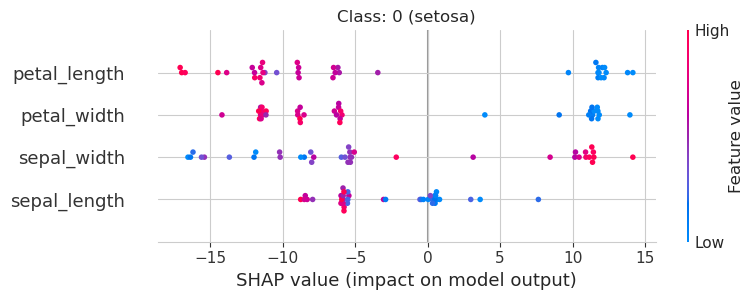

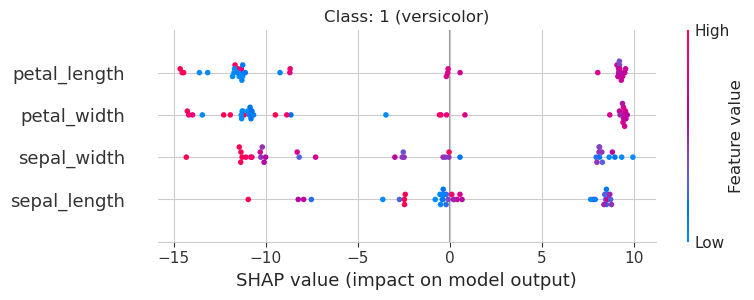

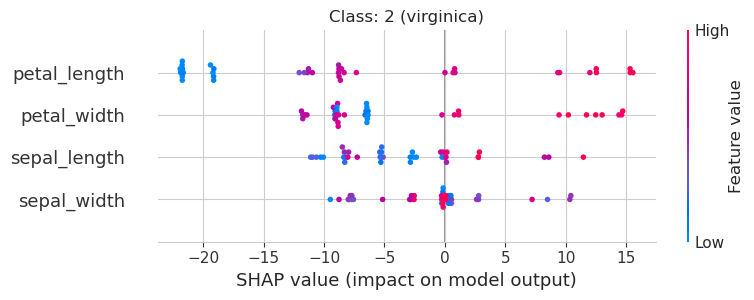




***************************************************************************
knn_eng , 	CV: False 

***************************************************************************
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
We will evaluate model=knn_eng with standard validation.
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 -> Fitting the model
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    0.916667 | 0.916667 |   0.916667 |  36        |
| 2            |    0.921053 | 0.921053 |   0.921053 |  38        |
| accuracy     |    0.945946 | 0.945946 |   0.945946 |   0.945946 |
| macro avg 

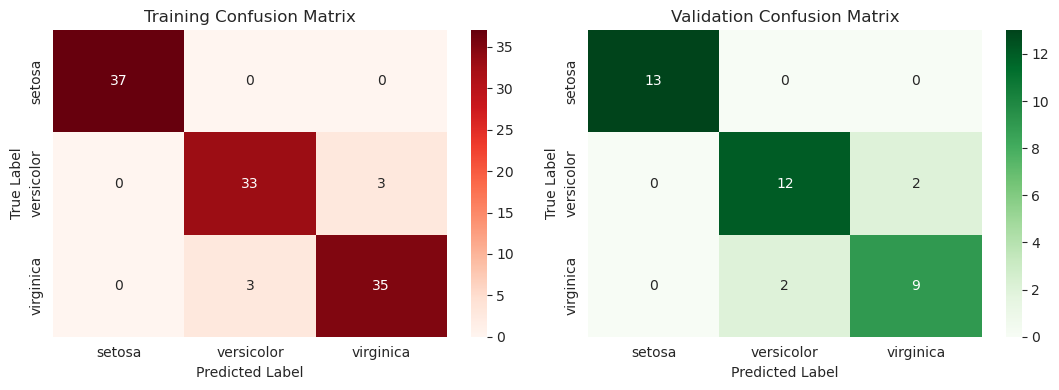






***************************************************************************
knn_eng , 	CV: True 

***************************************************************************
We will evaluate knn_eng with cross-validation.

 -> Creating instance of `RepeatedStratifiedKFold`
......Done!
 -> Creating the CV search
......Done!

 -> Fitting the model
......Done!
 -> CV Results:
		best f1_macro: 0.954387264877461
		best params: {'model__algorithm': 'auto', 'model__leaf_size': 5, 'model__n_neighbors': 3, 'model__p': 1, 'model__weights': 'uniform', 'preprocessor__selector__corr_threshold': 0.5, 'preprocessor__selector__n_features': None}
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 0.972973 |

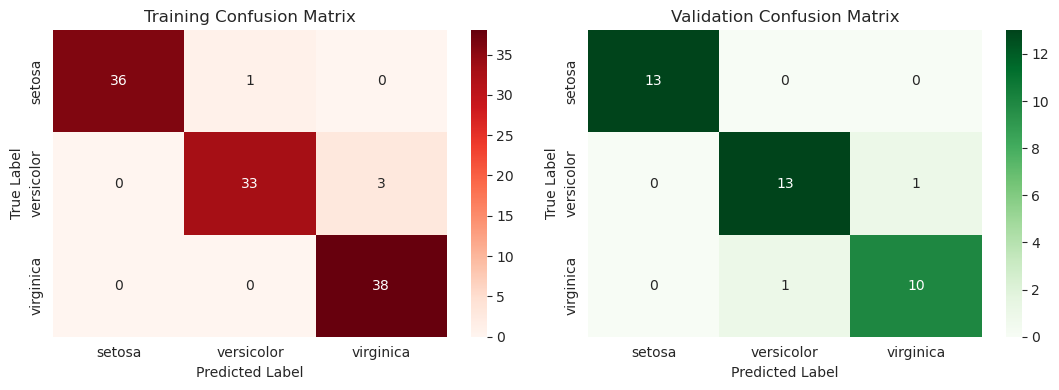



****************************************************************************************************
Performing Permutation Importance:
..................................................
The model's features are:

['petal_area', 'sepal_width']
The most important features are:

	petal_area: 0.5684210526315788 +- 0.05907880084379905
	sepal_width: 0.09473684210526312 +- 0.026836944808383095

****************************************************************************************************



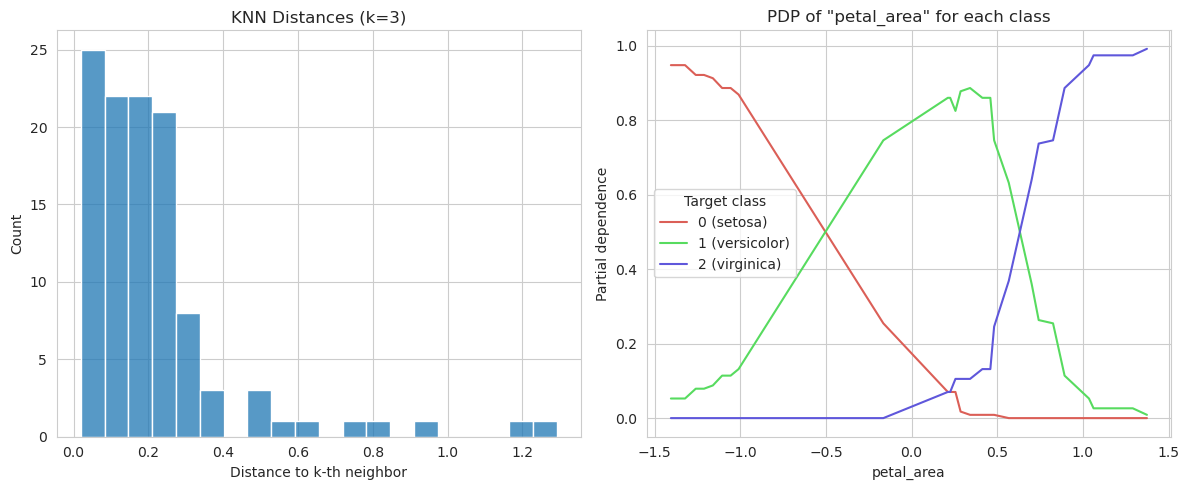

  0%|          | 0/38 [00:00<?, ?it/s]

num_full_subsets = 1
np.sum(w_aug) = 2.0
np.sum(self.kernelWeights) = 1.0
phi = array([-19.29479803, -14.86621586])
np.sum(w_aug) = 2.0
np.sum(self.kernelWeights) = 1.0
phi = array([-17.24136362, -16.60426559])
np.sum(w_aug) = 2.0
np.sum(self.kernelWeights) = 1.0
phi = array([18.84554242, 16.74000213])
num_full_subsets = 1
np.sum(w_aug) = 2.0
np.sum(self.kernelWeights) = 1.0
phi = array([-18.73873502, -15.42227887])
np.sum(w_aug) = 2.0
np.sum(self.kernelWeights) = 1.0
phi = array([19.56445356, 15.66826962])
np.sum(w_aug) = 2.0
np.sum(self.kernelWeights) = 1.0
phi = array([-18.22819817, -15.26460967])
num_full_subsets = 1
np.sum(w_aug) = 2.0
np.sum(self.kernelWeights) = 1.0
phi = array([-19.4210934 , -14.73992049])
np.sum(w_aug) = 2.0
np.sum(self.kernelWeights) = 1.0
phi = array([ 1.83794613, -0.45165177])
np.sum(w_aug) = 2.0
np.sum(self.kernelWeights) = 1.0
phi = array([-0.09308756,  0.44590894])
num_full_subsets = 1
np.sum(w_aug) = 2.0
np.sum(self.kernelWeights) = 1.0
phi = array([-19

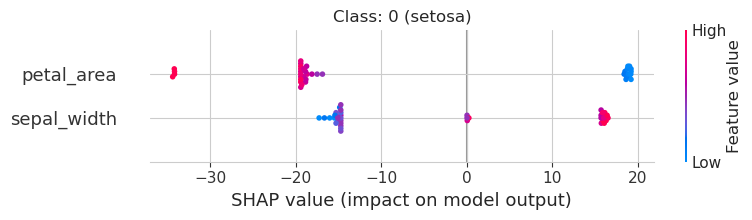

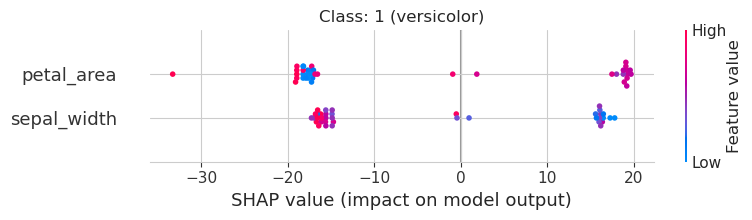

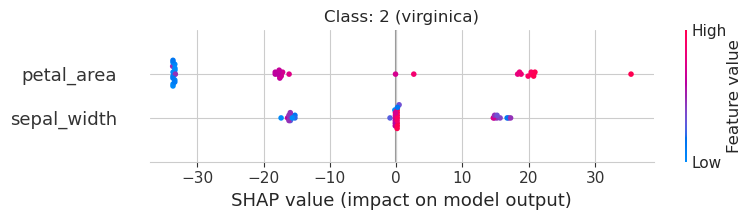

In [81]:
model = 'knn'

for pp in ['raw', 'eng']:
    for cvQ in [False, True]:

        model_name = model+'_'+pp # full model name

        print("*"*75)
        print(model_name, ", \tCV:", cvQ, "\n")
        print("*"*75)
        
        model_evaluation(model_name, (X_train, X_val, y_train, y_val),
                         n_splits=5, n_repeats=3,
                         perform_cv_randomized=(cvQ, False),
                         verbose=True, plots=True)

        print("\n")

        if cvQ:
            explain_model(model_name, best_cv[model_name]['pipe'], (X_train, X_val, y_train, y_val), tree_idx=0, random_state=0)

        print("\n\n")

In [82]:
scorecard

,rfc_base_no_cv,dtc_raw_no_cv,dtc_raw_cv,dtc_eng_no_cv,dtc_eng_cv,rfc_raw_no_cv,rfc_raw_cv,rfc_eng_no_cv,rfc_eng_cv,xgbc_raw_no_cv,...,logreg_eng_no_cv,logreg_eng_cv,svc_raw_no_cv,svc_raw_cv,svc_eng_no_cv,svc_eng_cv,knn_raw_no_cv,knn_raw_cv,knn_eng_no_cv,knn_eng_cv
Precision Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.973382,1.000000,0.975610,1.000000,...,0.954955,0.954955,0.991453,0.991453,0.954955,0.991453,0.964425,1.000000,0.945906,0.965806
Precision Validation,0.945887,0.945887,0.945887,0.977778,0.945887,0.945887,0.945887,0.945887,0.972222,0.920246,...,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.891775,0.945887
Recall Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972710,1.000000,0.972222,1.000000,...,0.955166,0.955166,0.990741,0.990741,0.955166,0.990741,0.964425,1.000000,0.945906,0.963213
Recall Validation,0.945887,0.945887,0.945887,0.969697,0.945887,0.945887,0.945887,0.945887,0.976190,0.922078,...,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.891775,0.945887
Accuracy Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972973,1.000000,0.972973,1.000000,...,0.954955,0.954955,0.990991,0.990991,0.954955,0.990991,0.963964,1.000000,0.945946,0.963964
Accuracy Validation,0.947368,0.947368,0.947368,0.973684,0.947368,0.947368,0.947368,0.947368,0.973684,0.921053,...,0.947368,0.947368,0.947368,0.947368,0.947368,0.947368,0.947368,0.947368,0.894737,0.947368
F1 Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972928,1.000000,0.972849,1.000000,...,0.954947,0.954947,0.990976,0.990976,0.954947,0.990976,0.963964,1.000000,0.945906,0.963728
F1 Validation,0.945887,0.945887,0.945887,0.972633,0.945887,0.945887,0.945887,0.945887,0.973162,0.920314,...,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.891775,0.945887


### Model 7: `GaussianNB`

In [83]:
model = 'gnb'

for pp in ['raw', 'eng']:

    model_name = model+'_'+pp # full model name

    preproc_pipe = final_preproc[pp] # preprocessing  pipeline

    pipe[model_name] = Pipeline(steps=[('preprocessor', preproc_pipe),
                                       ('model', GaussianNB())])
    
    pipe[model_name+'_no_cv'] = Pipeline(steps=[('preprocessor', preproc_pipe),
                                       ('model', GaussianNB())])

    # defining the hyperparameter grid
    if pp == 'raw':
        param_grid[model_name] = {'model__var_smoothing': np.logspace(0,-9, num=100)}
    else:
        param_grid[model_name] = {'model__var_smoothing': np.logspace(0,-9, num=100),
                                  'preprocessor__selector__n_features': [None, len(X.columns)],
                                  'preprocessor__selector__corr_threshold': [0.5, 0.7, 0.9]}

***************************************************************************
gnb_raw , 	CV: False 

***************************************************************************
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
We will evaluate model=gnb_raw with standard validation.
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 -> Fitting the model
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    0.942857 | 0.916667 |   0.929577 |  36        |
| 2            |    0.923077 | 0.947368 |   0.935065 |  38        |
| accuracy     |    0.954955 | 0.954955 |   0.954955 |   0.954955 |
| macro avg    

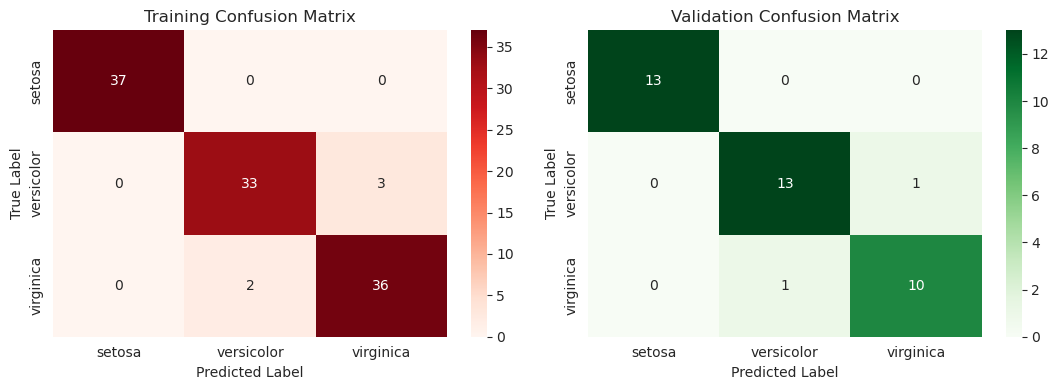






***************************************************************************
gnb_raw , 	CV: True 

***************************************************************************
We will evaluate gnb_raw with cross-validation.

 -> Creating instance of `RepeatedStratifiedKFold`
......Done!
 -> Creating the CV search
......Done!

 -> Fitting the model
......Done!
 -> CV Results:
		best f1_macro: 0.9538344625599529
		best params: {'model__var_smoothing': 0.01519911082952933}
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    0.944444 | 0.944444 |   0.944444 |  36        |
| 2            |    0.947368 | 0.947368 |   0.947368 |  38        |
| 

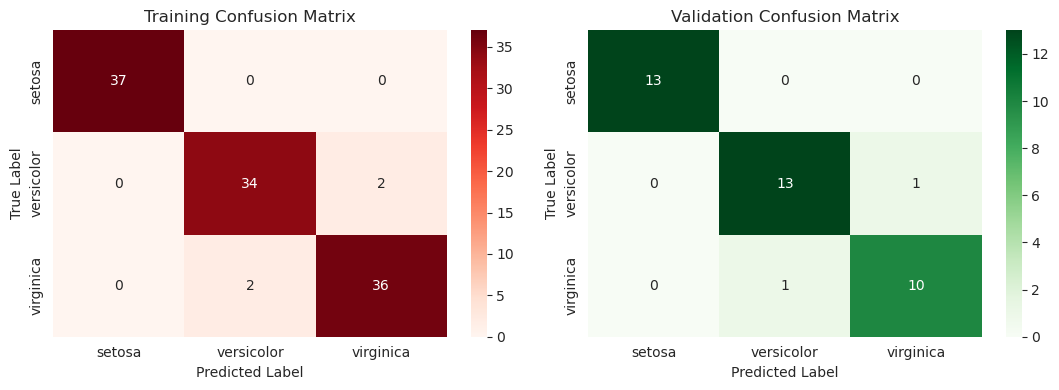



****************************************************************************************************
Performing Permutation Importance:
..................................................
The model's features are:

['petal_length', 'petal_width', 'sepal_length', 'sepal_width']
The most important features are:

	petal_length: 0.3842105263157894 +- 0.06781104593013226
	petal_width: 0.32631578947368417 +- 0.05668594533825792
	sepal_length: 0.0 +- 0.0
	sepal_width: 0.0 +- 0.0

****************************************************************************************************



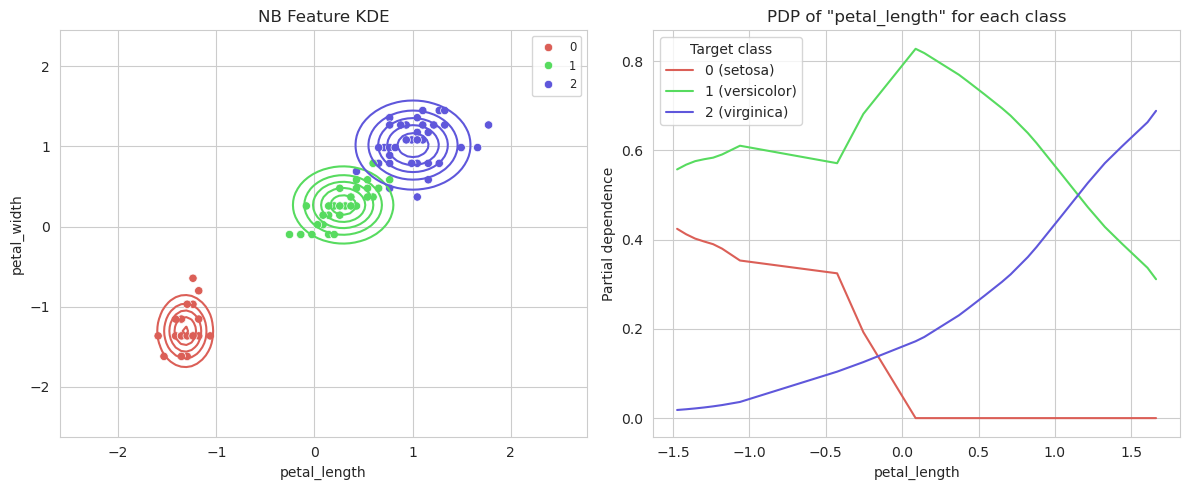




***************************************************************************
gnb_eng , 	CV: False 

***************************************************************************
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
We will evaluate model=gnb_eng with standard validation.
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 -> Fitting the model
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    0.911765 | 0.861111 |   0.885714 |  36        |
| 2            |    0.875    | 0.921053 |   0.897436 |  38        |
| accuracy     |    0.927928 | 0.927928 |   0.927928 |   0.927928 |
| macro avg 

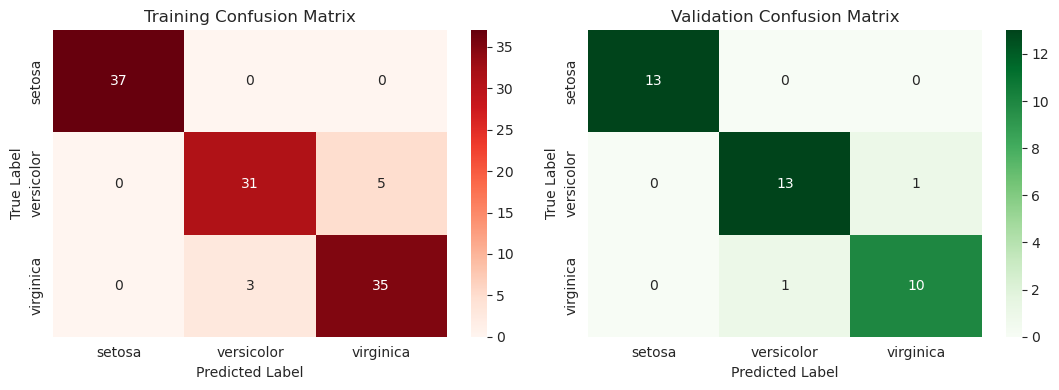






***************************************************************************
gnb_eng , 	CV: True 

***************************************************************************
We will evaluate gnb_eng with cross-validation.

 -> Creating instance of `RepeatedStratifiedKFold`
......Done!
 -> Creating the CV search
......Done!

 -> Fitting the model
......Done!
 -> CV Results:
		best f1_macro: 0.9450072222621243
		best params: {'model__var_smoothing': 0.0023101297000831605, 'preprocessor__selector__corr_threshold': 0.9, 'preprocessor__selector__n_features': 4}
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    0.918919 | 0.944444 |   0.93

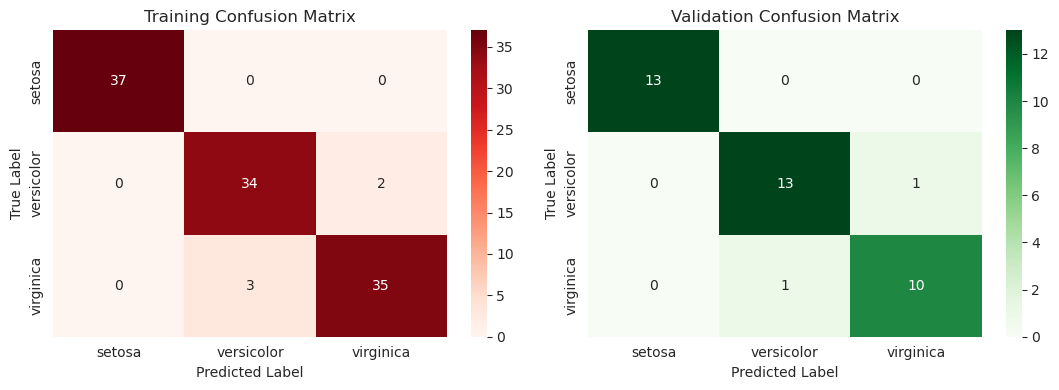



****************************************************************************************************
Performing Permutation Importance:
..................................................
The model's features are:

['petal_area', 'sepal_elongation', 'sepal_length', 'sepal_width']
The most important features are:

	petal_area: 0.5736842105263158 +- 0.08712076503814131
	sepal_elongation: 0.0578947368421052 +- 0.01969293361459967
	sepal_length: 0.0 +- 0.0
	sepal_width: 0.0 +- 0.0

****************************************************************************************************



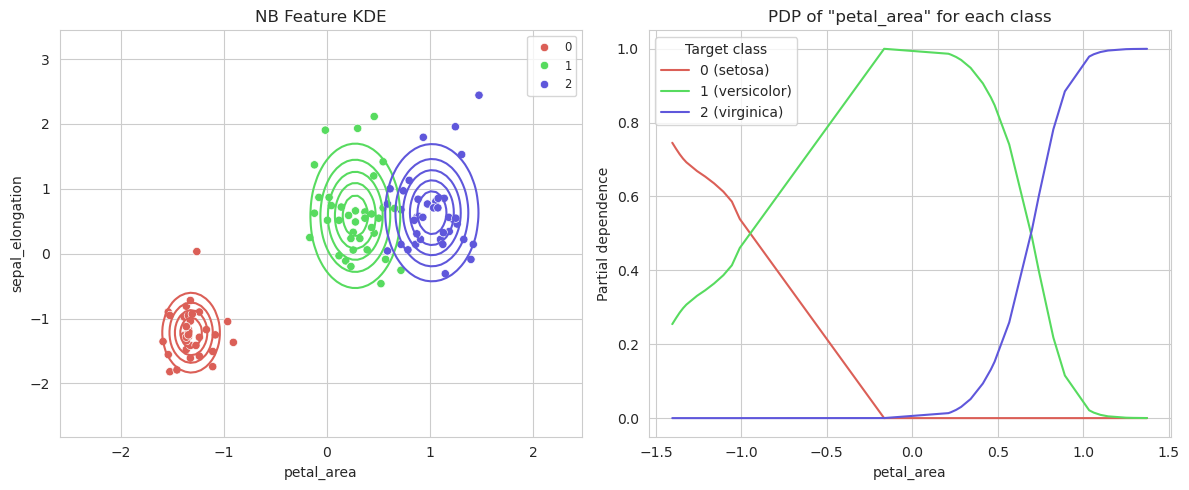

In [84]:
model = 'gnb'

for pp in ['raw', 'eng']:
    for cvQ in [False, True]:

        model_name = model+'_'+pp # full model name

        print("*"*75)
        print(model_name, ", \tCV:", cvQ, "\n")
        print("*"*75)
        
        model_evaluation(model_name, (X_train, X_val, y_train, y_val),
                         n_splits=5, n_repeats=3,
                         perform_cv_randomized=(cvQ, False),
                         verbose=True, plots=True)

        print("\n")

        if cvQ:
            explain_model(model_name, best_cv[model_name]['pipe'], (X_train, X_val, y_train, y_val), tree_idx=0, random_state=0)

        print("\n\n")

In [85]:
scorecard

,rfc_base_no_cv,dtc_raw_no_cv,dtc_raw_cv,dtc_eng_no_cv,dtc_eng_cv,rfc_raw_no_cv,rfc_raw_cv,rfc_eng_no_cv,rfc_eng_cv,xgbc_raw_no_cv,...,svc_eng_no_cv,svc_eng_cv,knn_raw_no_cv,knn_raw_cv,knn_eng_no_cv,knn_eng_cv,gnb_raw_no_cv,gnb_raw_cv,gnb_eng_no_cv,gnb_eng_cv
Precision Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.973382,1.000000,0.975610,1.000000,...,0.954955,0.991453,0.964425,1.000000,0.945906,0.965806,0.955311,0.963938,0.928922,0.954955
Precision Validation,0.945887,0.945887,0.945887,0.977778,0.945887,0.945887,0.945887,0.945887,0.972222,0.920246,...,0.945887,0.945887,0.945887,0.945887,0.891775,0.945887,0.945887,0.945887,0.945887,0.945887
Recall Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972710,1.000000,0.972222,1.000000,...,0.955166,0.990741,0.964425,1.000000,0.945906,0.963213,0.954678,0.963938,0.927388,0.955166
Recall Validation,0.945887,0.945887,0.945887,0.969697,0.945887,0.945887,0.945887,0.945887,0.976190,0.922078,...,0.945887,0.945887,0.945887,0.945887,0.891775,0.945887,0.945887,0.945887,0.945887,0.945887
Accuracy Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972973,1.000000,0.972973,1.000000,...,0.954955,0.990991,0.963964,1.000000,0.945946,0.963964,0.954955,0.963964,0.927928,0.954955
Accuracy Validation,0.947368,0.947368,0.947368,0.973684,0.947368,0.947368,0.947368,0.947368,0.973684,0.921053,...,0.947368,0.947368,0.947368,0.947368,0.894737,0.947368,0.947368,0.947368,0.947368,0.947368
F1 Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972928,1.000000,0.972849,1.000000,...,0.954947,0.990976,0.963964,1.000000,0.945906,0.963728,0.954881,0.963938,0.927717,0.954947
F1 Validation,0.945887,0.945887,0.945887,0.972633,0.945887,0.945887,0.945887,0.945887,0.973162,0.920314,...,0.945887,0.945887,0.945887,0.945887,0.891775,0.945887,0.945887,0.945887,0.945887,0.945887


### Model 8: `MLPClassifier`

In [86]:
model = 'mlp'

for pp in ['raw', 'eng']:

    model_name = model+'_'+pp # full model name

    preproc_pipe = final_preproc[pp] # preprocessing  pipeline

    pipe[model_name] = Pipeline(steps=[('preprocessor', preproc_pipe),
                                       ('model', MLPClassifier(max_iter=10000, random_state=0))])

    pipe[model_name+'_no_cv'] = Pipeline(steps=[('preprocessor', preproc_pipe),
                                       ('model', MLPClassifier(max_iter=10000, random_state=0))])

    # defining the hyperparameter grid
    if pp == 'raw':
        param_grid[model_name] = {'model__hidden_layer_sizes': np.arange(10, 100, 10),
                                  'model__alpha': np.arange(0.001, 0.01, 0.001)}
    else:
        param_grid[model_name] = {'model__hidden_layer_sizes': np.arange(10, 100, 10),
                                  'model__alpha': np.arange(0.001, 0.01, 0.001),
                                  'preprocessor__selector__n_features': [None, len(X.columns)],
                                  'preprocessor__selector__corr_threshold': [0.5, 0.7, 0.9]}

***************************************************************************
mlp_raw , 	CV: False 

***************************************************************************
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
We will evaluate model=mlp_raw with standard validation.
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 -> Fitting the model
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    1        | 0.972222 |   0.985915 |  36        |
| 2            |    0.974359 | 1        |   0.987013 |  38        |
| accuracy     |    0.990991 | 0.990991 |   0.990991 |   0.990991 |
| macro avg    

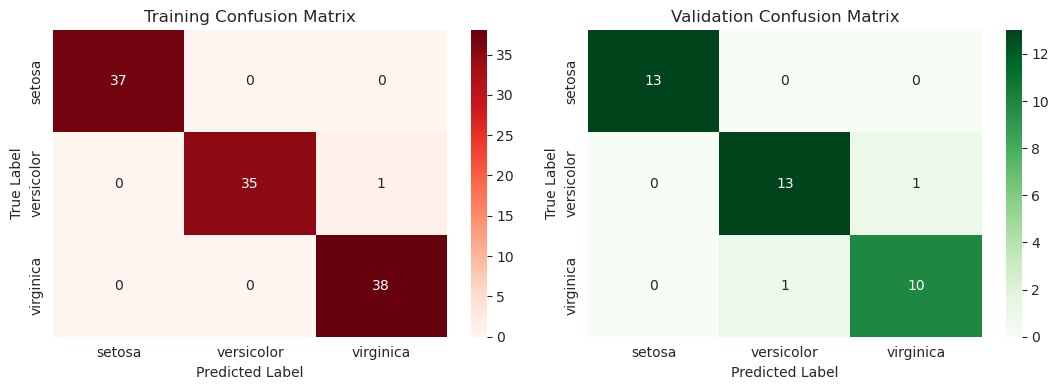






***************************************************************************
mlp_raw , 	CV: True 

***************************************************************************
We will evaluate mlp_raw with cross-validation.

 -> Creating instance of `RepeatedStratifiedKFold`
......Done!
 -> Creating the CV search
......Done!

 -> Fitting the model
......Done!
 -> CV Results:
		best f1_macro: 0.9601660721268565
		best params: {'model__alpha': 0.001, 'model__hidden_layer_sizes': 50}
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    0.971429 | 0.944444 |   0.957746 |  36        |
| 2            |    0.948718 | 0.973684 |   0.961039 |  38 

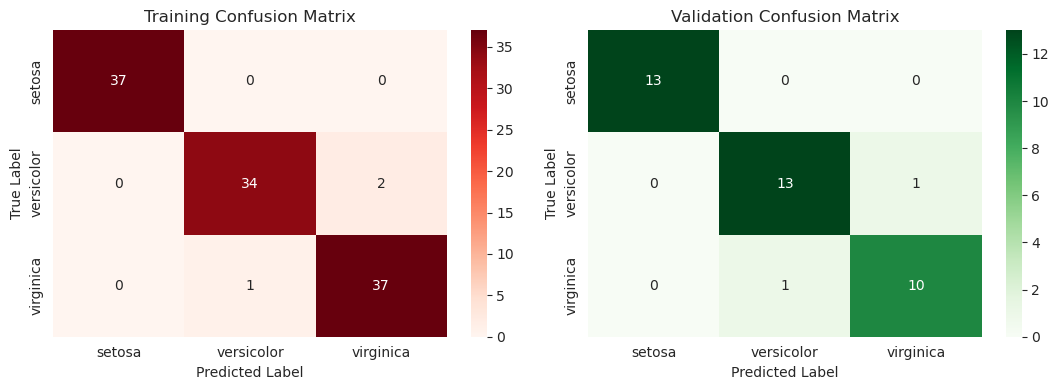



****************************************************************************************************
Performing Permutation Importance:
..................................................
The model's features are:

['petal_length', 'petal_width', 'sepal_width', 'sepal_length']
The most important features are:

	petal_length: 0.19999999999999996 +- 0.048808518397345804
	petal_width: 0.17368421052631572 +- 0.05418752705782633
	sepal_width: 0.14210526315789468 +- 0.04275809686650507
	sepal_length: 0.05789473684210522 +- 0.025784102555612413

****************************************************************************************************



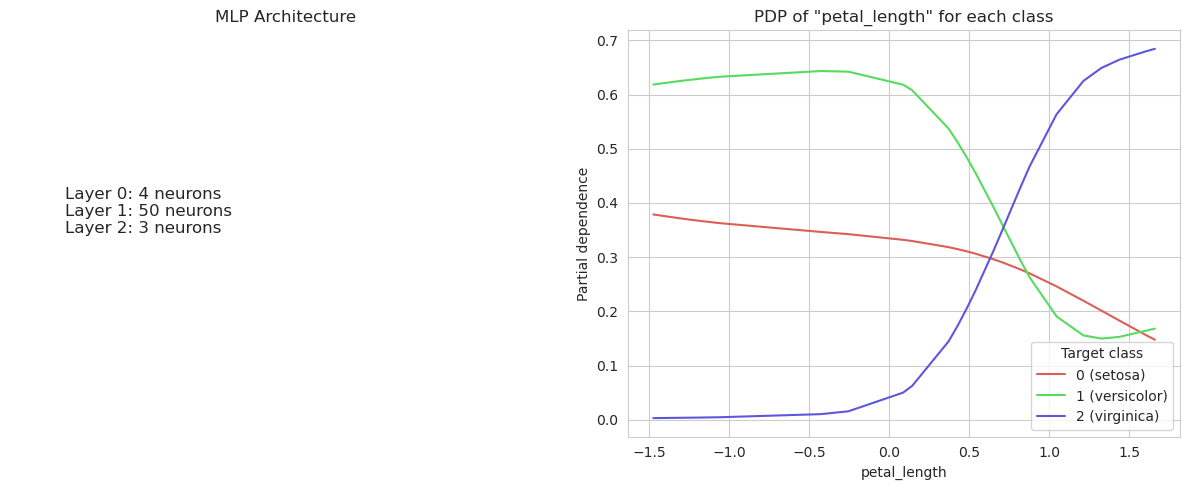

  0%|          | 0/38 [00:00<?, ?it/s]

num_full_subsets = 2
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([-2.12836288, -2.56158037, -1.21971149, -1.13572668])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([ 0.76195248,  0.00818371, -0.90834092, -1.2319785 ])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([-0.17669817,  0.43296368,  1.26152104,  1.64070682])
num_full_subsets = 2
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([-1.34354282, -2.18769307, -0.84906479, -0.84443135])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([0.64993496, 1.29998871, 1.49345065, 1.31616408])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([-0.15128936, -0.27508167, -1.55476772, -1.21971776])
num_full_subsets = 2
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelW

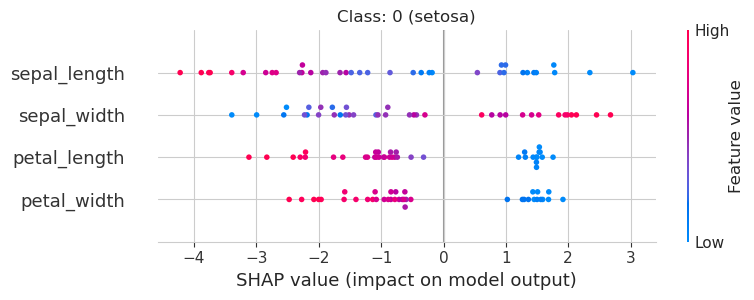

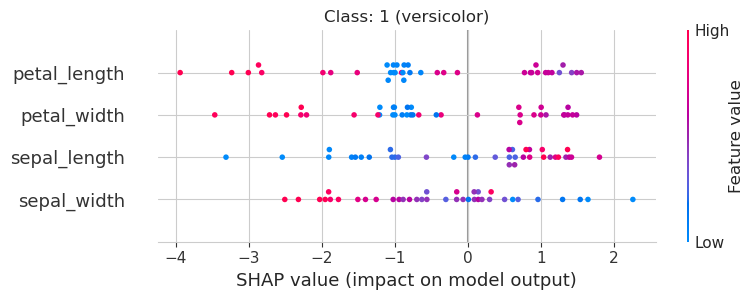

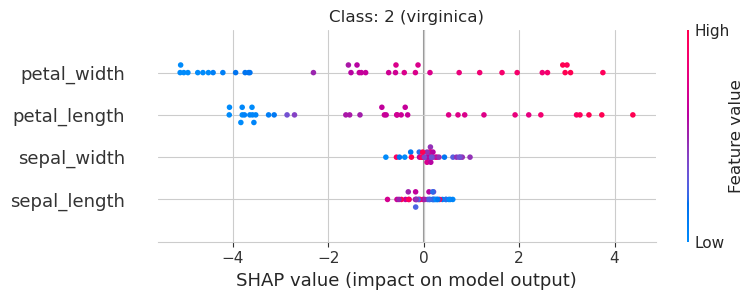




***************************************************************************
mlp_eng , 	CV: False 

***************************************************************************
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
We will evaluate model=mlp_eng with standard validation.
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::

 -> Fitting the model
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    0.972222 | 0.972222 |   0.972222 |  36        |
| 2            |    0.973684 | 0.973684 |   0.973684 |  38        |
| accuracy     |    0.981982 | 0.981982 |   0.981982 |   0.981982 |
| macro avg 

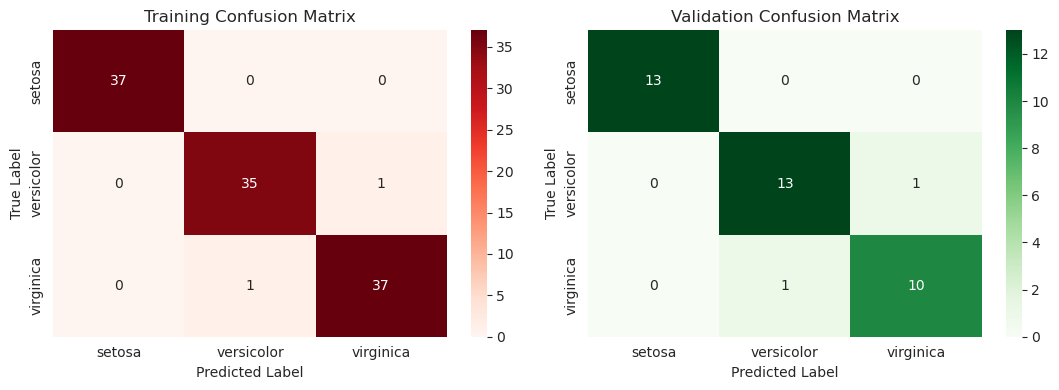






***************************************************************************
mlp_eng , 	CV: True 

***************************************************************************
We will evaluate mlp_eng with cross-validation.

 -> Creating instance of `RepeatedStratifiedKFold`
......Done!
 -> Creating the CV search
......Done!

 -> Fitting the model
......Done!
 -> CV Results:
		best f1_macro: 0.9605377592632496
		best params: {'model__alpha': 0.001, 'model__hidden_layer_sizes': 50, 'preprocessor__selector__corr_threshold': 0.9, 'preprocessor__selector__n_features': 4}
......Done!
 -> Making predictions
......Done!
 -> Creating Classification Reports
......Done!


Classification Report: Training
..................................................
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    1        | 1        |   1        |  37        |
| 1            |    0.972222 | 0.972222

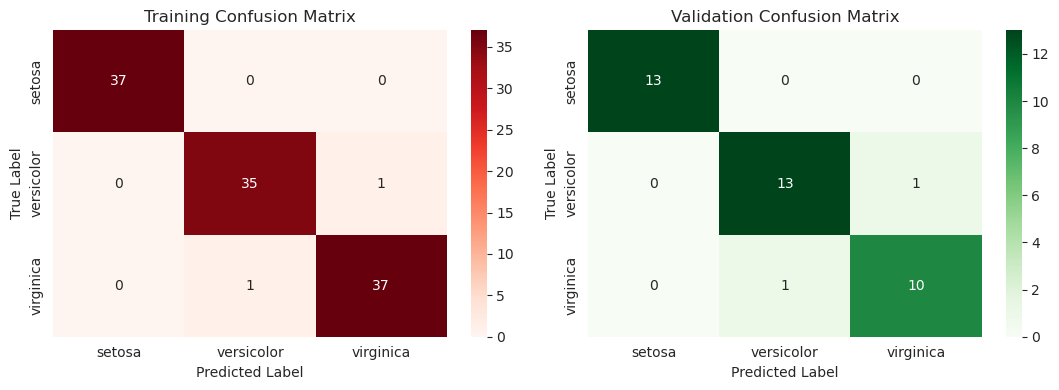



****************************************************************************************************
Performing Permutation Importance:
..................................................
The model's features are:

['petal_area', 'sepal_elongation', 'sepal_length', 'sepal_width']
The most important features are:

	petal_area: 0.24736842105263154 +- 0.03938586722919938
	sepal_elongation: 0.21052631578947362 +- 0.040768245749551756
	sepal_length: 0.131578947368421 +- 0.04403473823863555
	sepal_width: 0.021052631578947344 +- 0.03068922049918576

****************************************************************************************************



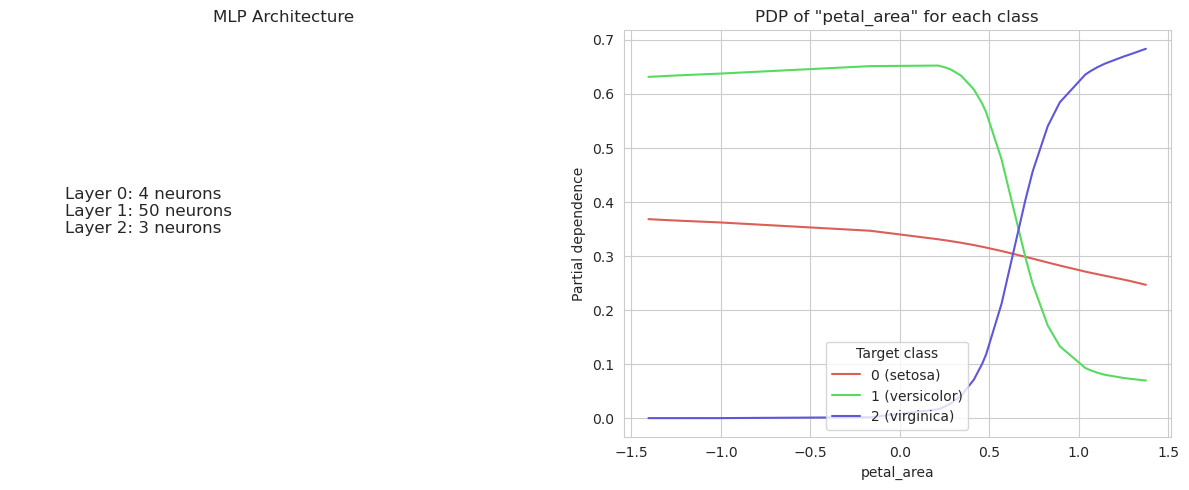

  0%|          | 0/38 [00:00<?, ?it/s]

num_full_subsets = 2
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([-0.48066682, -3.2885506 , -3.32941941, -2.07316276])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([-2.17540005, -0.03302167,  0.59125776,  0.20373843])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([2.30739604, 0.79368176, 0.08668276, 0.02877147])
num_full_subsets = 2
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([-0.27393998, -2.49281298, -1.7682047 , -1.5408798 ])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([1.7643627 , 1.35725123, 0.92257388, 0.69171601])
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeights) = 0.9999999999999998
phi = array([-2.60315018, -0.0542085 , -0.34173158, -0.02810677])
num_full_subsets = 2
np.sum(w_aug) = 3.999999999999999
np.sum(self.kernelWeigh

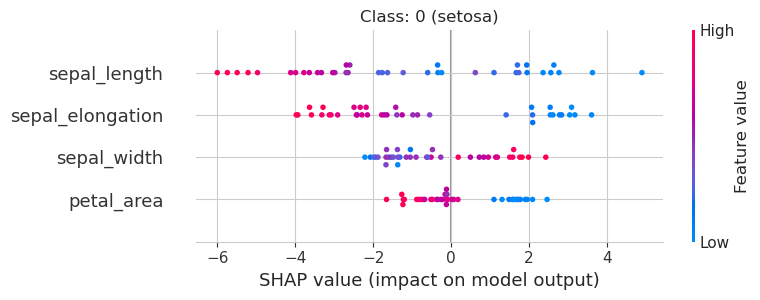

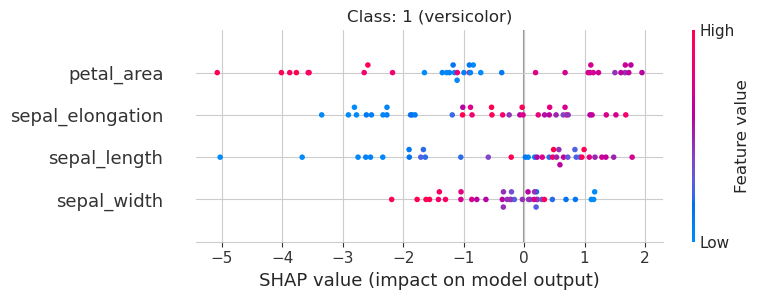

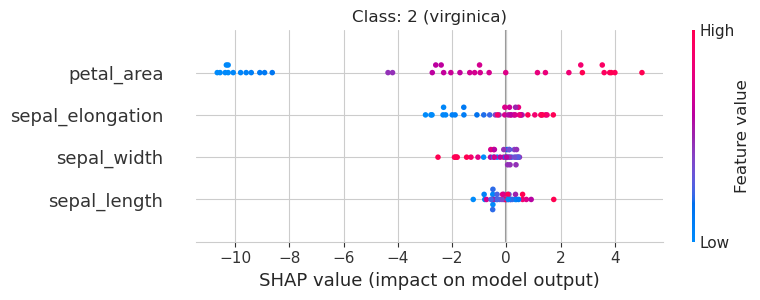

In [87]:
for pp in ['raw', 'eng']:
    for cvQ in [False, True]:

        model_name = model+'_'+pp # full model name

        print("*"*75)
        print(model_name, ", \tCV:", cvQ, "\n")
        print("*"*75)
        
        model_evaluation(model_name, (X_train, X_val, y_train, y_val),
                         n_splits=5, n_repeats=3,
                         perform_cv_randomized=(cvQ, False),
                         verbose=True, plots=True)

        print("\n")

        if cvQ:
            explain_model(model_name, best_cv[model_name]['pipe'], (X_train, X_val, y_train, y_val), tree_idx=0, random_state=0)

        print("\n\n")

In [88]:
scorecard

,rfc_base_no_cv,dtc_raw_no_cv,dtc_raw_cv,dtc_eng_no_cv,dtc_eng_cv,rfc_raw_no_cv,rfc_raw_cv,rfc_eng_no_cv,rfc_eng_cv,xgbc_raw_no_cv,...,knn_eng_no_cv,knn_eng_cv,gnb_raw_no_cv,gnb_raw_cv,gnb_eng_no_cv,gnb_eng_cv,mlp_raw_no_cv,mlp_raw_cv,mlp_eng_no_cv,mlp_eng_cv
Precision Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.973382,1.000000,0.975610,1.000000,...,0.945906,0.965806,0.955311,0.963938,0.928922,0.954955,0.991453,0.973382,0.981969,0.981969
Precision Validation,0.945887,0.945887,0.945887,0.977778,0.945887,0.945887,0.945887,0.945887,0.972222,0.920246,...,0.891775,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887
Recall Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972710,1.000000,0.972222,1.000000,...,0.945906,0.963213,0.954678,0.963938,0.927388,0.955166,0.990741,0.972710,0.981969,0.981969
Recall Validation,0.945887,0.945887,0.945887,0.969697,0.945887,0.945887,0.945887,0.945887,0.976190,0.922078,...,0.891775,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887
Accuracy Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972973,1.000000,0.972973,1.000000,...,0.945946,0.963964,0.954955,0.963964,0.927928,0.954955,0.990991,0.972973,0.981982,0.981982
Accuracy Validation,0.947368,0.947368,0.947368,0.973684,0.947368,0.947368,0.947368,0.947368,0.973684,0.921053,...,0.894737,0.947368,0.947368,0.947368,0.947368,0.947368,0.947368,0.947368,0.947368,0.947368
F1 Train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.972928,1.000000,0.972849,1.000000,...,0.945906,0.963728,0.954881,0.963938,0.927717,0.954947,0.990976,0.972928,0.981969,0.981969
F1 Validation,0.945887,0.945887,0.945887,0.972633,0.945887,0.945887,0.945887,0.945887,0.973162,0.920314,...,0.891775,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887


## 8. Exporting Best Model

In [93]:
import pickle

We begin by selecting only those models with CV, and focusing only on the validation scores:

In [90]:
best_scores = scorecard.loc[[idx for idx in scorecard.index if 'Val' in idx], [col for col in scorecard.columns if '_no_cv' not in col]]
best_scores.head()

,dtc_raw_cv,dtc_eng_cv,rfc_raw_cv,rfc_eng_cv,xgbc_raw_cv,xgbc_eng_cv,logreg_raw_cv,logreg_eng_cv,svc_raw_cv,svc_eng_cv,knn_raw_cv,knn_eng_cv,gnb_raw_cv,gnb_eng_cv,mlp_raw_cv,mlp_eng_cv
Precision Validation,0.945887,0.945887,0.945887,0.972222,0.948413,0.977778,0.972222,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887
Recall Validation,0.945887,0.945887,0.945887,0.976190,0.952381,0.969697,0.976190,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887
Accuracy Validation,0.947368,0.947368,0.947368,0.973684,0.947368,0.973684,0.973684,0.947368,0.947368,0.947368,0.947368,0.947368,0.947368,0.947368,0.947368,0.947368
F1 Validation,0.945887,0.945887,0.945887,0.973162,0.947521,0.972633,0.973162,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887,0.945887


In [94]:
best_scores_T = best_scores.transpose()
best_scores_T

,Precision Validation,Recall Validation,Accuracy Validation,F1 Validation
dtc_raw_cv,0.945887,0.945887,0.947368,0.945887
dtc_eng_cv,0.945887,0.945887,0.947368,0.945887
rfc_raw_cv,0.945887,0.945887,0.947368,0.945887
rfc_eng_cv,0.972222,0.976190,0.973684,0.973162
xgbc_raw_cv,0.948413,0.952381,0.947368,0.947521
xgbc_eng_cv,0.977778,0.969697,0.973684,0.972633
logreg_raw_cv,0.972222,0.976190,0.973684,0.973162
logreg_eng_cv,0.945887,0.945887,0.947368,0.945887
svc_raw_cv,0.945887,0.945887,0.947368,0.945887
svc_eng_cv,0.945887,0.945887,0.947368,0.945887


Let us select the models that performed the best in F1 validation:

In [95]:
best_models = list(best_scores_T[best_scores_T['F1 Validation'] == best_scores_T['F1 Validation'].max()].index)

print(best_models)

['rfc_eng_cv', 'logreg_raw_cv']


Which one to pick? Well, let's look at their mean CV test scores, and their standard deviations:

In [96]:
stds = {}
for model_name in best_models:
    model_name = model_name.removesuffix('_cv')
    print(model_name)
    idx_largest_score = search[model_name].cv_results_['mean_test_score'].argmax()
    print("found best score?", search[model_name].cv_results_['mean_test_score'][idx_largest_score] == best_cv[model_name]['score'])
    print("best score:", best_cv[model_name]['score'], "+-", search[model_name].cv_results_['std_test_score'][idx_largest_score], "\n")

    stds[model_name] = search[model_name].cv_results_['std_test_score'][idx_largest_score]

rfc_eng
found best score? True
best score: 0.9603234057155627 +- 0.03718483301991112 

logreg_raw
found best score? False
best score: 0.9630259682220467 +- nan 



Since their best mean CV scores are all within each others standard deviations, they are all functionally equivalent in the CV. Thus, what matters is precisely the standard deviation, which is evidence of their stability. Selecting the models with the smallest standard deviations:

In [99]:
list_overall_best_models = [k+'_cv' for k,v in stds.items() if v == stds[min(stds, key=stds.get)]]

print("models:", list_overall_best_models)
print("scores:", [best_cv[k.removesuffix('_cv')]['score'] for k in list_overall_best_models])
print("stds:", [stds[k.removesuffix('_cv')] for k in list_overall_best_models])

best_scores_T.loc[list_overall_best_models]

models: ['rfc_eng_cv']
scores: [0.9603234057155627]
stds: [0.03718483301991112]


,Precision Validation,Recall Validation,Accuracy Validation,F1 Validation
rfc_eng_cv,0.972222,0.97619,0.973684,0.973162


To save them, we pickle them:

In [103]:
for overall_best_model in list_overall_best_models:
    
    overall_best_model = overall_best_model.removesuffix('_cv')

    model_path = "../models/"+overall_best_model+".pkl"

    with open(model_path, "wb") as f:
        pickle.dump(best_cv[overall_best_model]['pipe'], f)

To load the models, run the cell below:

In [104]:
models_directory = "../models/"

my_best_models = {}

for filename in os.listdir(models_directory):
    model_path = os.path.join(models_directory, filename)

    model = model_path.removesuffix('.pkl').removeprefix('./models/')

    with open(model_path, "rb") as f:
        my_best_models[model] = pickle.load(f)

In [105]:
my_best_models

{'rfc_eng': Pipeline(steps=[('preprocessor',
                  Pipeline(steps=[('feature_engineer',
                                   FeatureEngineer(func=<function new_iris_features at 0x7b6fdc30aac0>)),
                                  ('scaler',
                                   Pipeline(steps=[('box-cox',
                                                    ColumnTransformer(remainder='passthrough',
                                                                      transformers=[('box-cox',
                                                                                     PowerTransformer(method='box-cox'),
                                                                                     slice(0, None, None))],
                                                                      verbose_feature_names_out=False)),
                                                   ('z_scaler',
                                                    ColumnTransformer(remainder='passthrough',
 